In [5]:
import datajoint as dj
dj.config.load('C:\\Secrets\\dj_local_conf.json')
dj.conn() 
direction_dict = {'LR':'Left - Right',
                  'RL':'Right - Left',
                  'AP':'Anterior - Posterior',
                  'PA':'Posterior - Anterior'}
#%% import necessary packages
import matplotlib.pyplot as plt
import pandas as pd
from ndnf_pipeline import lab, experiment, behavior_analysis
import numpy as np


[2026-06-22 15:32:06,400][INFO]: DataJoint is configured from C:\Secrets\dj_local_conf.json


In [2]:
behavior_analysis.TrialSubmovements().populate()

{'success_count': 2771, 'error_list': []}

Text(0, 0.5, 'Number of Trials')

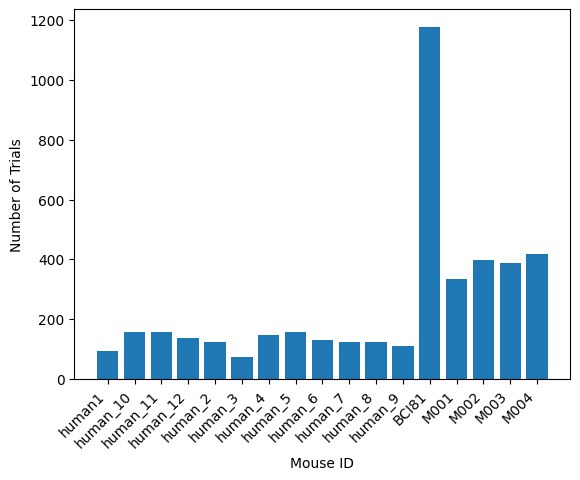

In [6]:
# find the mouse IDs that have been used in the experiment and count the number of trials for each mouse, then plot a bar graph
mouse_IDs = lab.Subject.fetch('subject_id')
trial_nums = []
for m in mouse_IDs:
    trial_nums.append(len((experiment.SessionTrial()&{'subject_id':m})))
trial_nums = np.array(trial_nums)
needed_mice = trial_nums>0

fig = plt. figure()
plt.bar(mouse_IDs[needed_mice], trial_nums[needed_mice])
plt.xticks(rotation=45, ha="right")
plt.xlabel('Mouse ID')
plt.ylabel('Number of Trials')


In [7]:
# order the subject IDs based on the number at the end of the ID, and ignore those that do not have a number at the end of the ID
subject_ids_ordered = []
subject_id_indices = []
include_benjamin = False

for subject_id in mouse_IDs[needed_mice]:
    if 'human' not in subject_id:
        if 'bbenjamin' in subject_id and include_benjamin:
            subject_id_indices.append(-1)
            subject_ids_ordered.append(subject_id)
            continue
        else:
            continue
    if '_' not in subject_id:
        subject_id_indices.append(int(subject_id[-1]))
    else:
        try:
            subject_id_indices.append(int(subject_id.split('_')[-1]))
        except:
            subject_id_indices.append(None)
    subject_ids_ordered.append(subject_id)
subject_id_indices = np.array(subject_id_indices)
subject_ids_ordered = np.array(subject_ids_ordered)
needed = subject_id_indices !=None
subject_id_indices = subject_id_indices[needed]
subject_ids_ordered = subject_ids_ordered[needed]
subject_ids_ordered = subject_ids_ordered[np.argsort(subject_id_indices)]
subject_id_indices = subject_id_indices[np.argsort(subject_id_indices)]

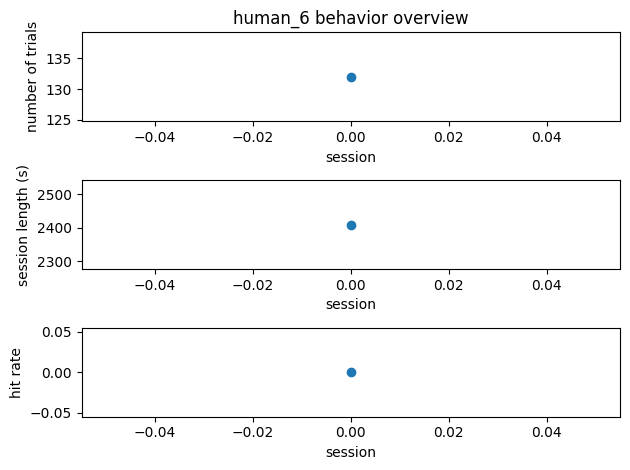

In [48]:

#subject_id = 'M004'#'mouse_bbenjamin'#'BCI81'
subject_id = 'mouse_judith'
#subject_id = 'mouse_bbenjamin'
subject_id = 'human_6'

available_sessions = (experiment.Session()&{'subject_id':subject_id}).fetch('session')
trial_nums = []
hit_rates = []
session_lengths = []
for session in available_sessions:
    trials = (experiment.SessionTrial()&{'subject_id':subject_id,
                                         'session':session}).fetch('trial')
    trial_nums.append(len(trials))
    hits = len(experiment.BehaviorTrial()&{'subject_id':subject_id,'session':session,'outcome':'hit'})
    hit_rate = hits/len(trials) if len(trials)>0 else np.nan
    hit_rates.append(hit_rate)
    session_length = (experiment.SessionTrial()&{'subject_id':subject_id,'session':session,'trial':np.max(trials)}).fetch1('trial_end_time')
    session_lengths.append(session_length)
fig = plt.figure()
ax1 = fig.add_subplot(3,1,1)
ax1.plot(available_sessions,trial_nums,'o-')
ax1.set_xlabel('session')
ax1.set_ylabel('number of trials')
plt.title(f'{subject_id} behavior overview')
ax2 = fig.add_subplot(3,1,2)
ax2.plot(available_sessions,session_lengths,'o-')
ax2.set_xlabel('session')
ax2.set_ylabel('session length (s)')
ax3 = fig.add_subplot(3,1,3)
ax3.plot(available_sessions,hit_rates,'o-')
ax3.set_xlabel('session')
ax3.set_ylabel('hit rate')
plt.tight_layout()
plt.show()

C:\Users\labadmin\AppData\Local\Temp\ipykernel_33840\341015609.py:93: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))


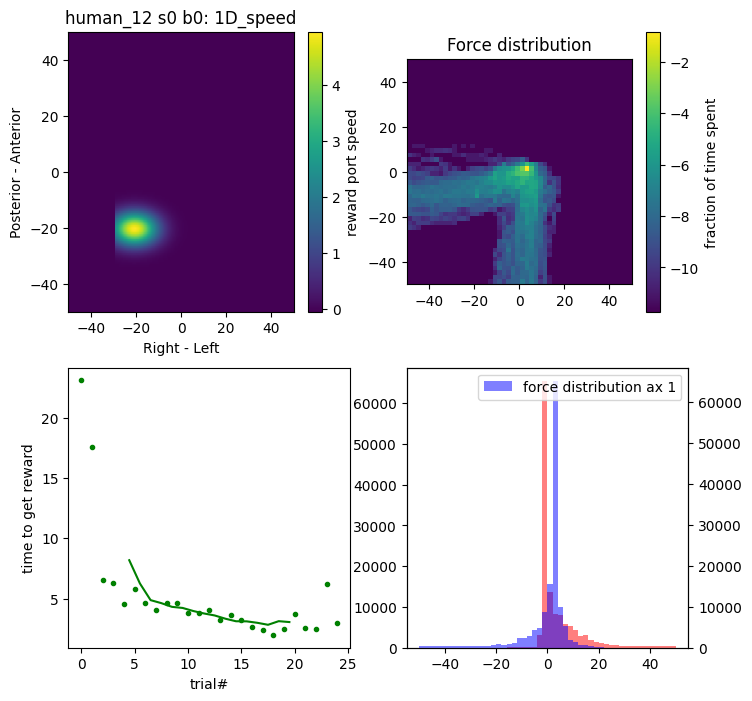

In [19]:
# visualize targets, and how forces change over sessions and trials
import matplotlib.pyplot as plt

# ── parameters ───────────────────────────────────────────────────────────────
subject_id     = 'human_12'  # subject to visualize
session        = 0           # int for a single session; None = all sessions
blocks_to_show = [0]        # None = all blocks; or e.g. [0, 1, 4]

subtract_force_median = False
force_uniform_range = True
uniform_force_range= np.asarray([-1,1,-1,1])*50

if session is None:
    _sess = sorted(set(
        (experiment.Block() & {'subject_id': subject_id})
        .fetch('session').tolist()))
else:
    _sess = [session]

for session_i, session in enumerate(_sess):
    available_blocks,feedback_types = (experiment.Block()&{'subject_id':subject_id,'session':session}).fetch('block','feedback_type')
    force_axes = (experiment.TaskSettings.ForceAxis()&{'subject_id':subject_id,'session':session}).fetch(as_dict=True)
    
    for block,feedback_type in zip(available_blocks,feedback_types):
        if blocks_to_show is not None and int(block) not in blocks_to_show:
            continue
        task_setting_id,target_force_lut = (experiment.TaskSettings()*experiment.Block() &{'subject_id':subject_id,'session':session,'block':block}).fetch1('task_setting_id','target_force_lut')
        
        fig = plt.figure(figsize=(8,8))
        ax_target_LUT = fig.add_subplot(2,2,1)
        force_axes_dict = {}
        for fa in force_axes:
            if fa['task_setting_id'] == task_setting_id:
                force_axes_dict[fa['force_axis_idx']] = {'force_direction':fa['force_direction'],
                                                    'target_force_axes':fa['target_force_axes']}
        if force_uniform_range:
            im0 = plt.imshow(np.ones(target_force_lut.shape)*np.min(target_force_lut.flatten()),extent = uniform_force_range,alpha = 1)                                            
        im_lut = plt.imshow(target_force_lut,extent = [force_axes_dict[0]['target_force_axes'][0],force_axes_dict[0]['target_force_axes'][-1],
                                                    force_axes_dict[1]['target_force_axes'][0],force_axes_dict[1]['target_force_axes'][-1]],
                                                    origin='upper',
                                                    cmap='viridis',
                                                    aspect='auto')
        plt.xlabel(direction_dict[force_axes_dict[0]['force_direction']])
        plt.ylabel(direction_dict[force_axes_dict[1]['force_direction']])
        plt.colorbar(im_lut,label='reward port speed')
        plt.title(f'{subject_id} s{session} b{block}: {feedback_type}')
        if force_uniform_range:
            ax_target_LUT.set_xlim([uniform_force_range[0],uniform_force_range[1]])
            ax_target_LUT.set_ylim([uniform_force_range[2],uniform_force_range[3]])


        ax_performance = fig.add_subplot(2,2,3)
        rewarded_trial, time_to_reward = (experiment.TrialEvent()*experiment.BehaviorTrial()*experiment.Block()&{'subject_id':subject_id,'session':session,'trial_event_type':'threshold crossing','block':block}).fetch('trial','trial_event_time')    #break
        ax_performance.set_xlabel('trial#')
        ax_performance.plot(rewarded_trial,time_to_reward,'g.')
        if len(rewarded_trial)>10:
            ax_performance.plot(np.convolve(rewarded_trial,np.ones(10)/10,mode='valid'),
                                np.convolve(np.asarray(time_to_reward,float),np.ones(10)/10,mode='valid'),'g-')
        
        ax_performance.set_ylabel('time to get reward')
        
        ax_force_hist = fig.add_subplot(2,2,2)
        force_traces_0_ = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.Block()&{'subject_id':subject_id,'session':session,'force_axis_idx':0,'block':block}).fetch('force_trace_value')
        force_traces_1_ = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.Block() &{'subject_id':subject_id,'session':session,'force_axis_idx':1,'block':block}).fetch('force_trace_value')
        if subtract_force_median:
            f0_baseline = np.median(np.concatenate(force_traces_0_))
            f1_baseline = np.median(np.concatenate(force_traces_1_))
            force_traces_0 = []
            for f in  force_traces_0_:
                force_traces_0.append(f-f0_baseline)
            force_traces_1 = []
            for f in  force_traces_1_:
                force_traces_1.append(f-f1_baseline)
        else:
            force_traces_0 = force_traces_0_
            force_traces_1 = force_traces_1_
        

        if force_uniform_range:
            histrange = [uniform_force_range[:2],uniform_force_range[:2]]
        else:
            histrange = [[force_axes_dict[0]['target_force_axes'][0],
                        force_axes_dict[0]['target_force_axes'][-1]],
                        [force_axes_dict[1]['target_force_axes'][0],
                        force_axes_dict[1]['target_force_axes'][-1]]]
        
        try:
            forcehist,binx,biny = np.histogram2d(np.concatenate(force_traces_0),
                                                np.concatenate(force_traces_1),
                                                range=histrange,
                                                bins=50)
            forcehist_all = forcehist.copy()
            forcehist = np.log(forcehist/sum(forcehist.flatten()))
            forcehist_ = forcehist.copy()
            forcehist_ [np.isinf(forcehist )] = 0
            forcehist[np.isinf(forcehist)] = np.nanmin(forcehist_.flatten())
            im_hist = ax_force_hist.imshow(forcehist,
                                        extent = [binx[0],binx[-1],biny[0],biny[-1]],
                                            alpha = 1)
            plt.colorbar(im_hist,label = 'fraction of time spent')
        except:
            pass

        plt.title('Force distribution')

        ax_force_hist_1d = fig.add_subplot(2,2,4)
        ax_force_hist_1d_2 = ax_force_hist_1d.twinx()
        try:
            ax_force_hist_1d.hist(np.concatenate(force_traces_0),binx,color = 'red',alpha = .5,label = 'force distribution ax 0')
            ax_force_hist_1d_2.hist(np.concatenate(force_traces_1),biny,color = 'blue',alpha = .5,label = 'force distribution ax 1')
            plt.legend()
            plt.xlabel('Force values')
        except:
            pass
        #ax_performance.set_yscale('log')
    

In [116]:

# ── DIAGNOSTIC: inspect data structure to understand why hit/miss look the same ──
print(f"subject_id = {subject_id}")
print()

for session in available_sessions:
    print(f"=== Session {session} ===")

    # task settings in this session
    task_setting_ids = (
        experiment.TaskSettings() & {'subject_id': subject_id, 'session': session}
    ).fetch('task_setting_id')
    print(f"  task_setting_ids: {task_setting_ids}")

    # outcome counts
    outcomes, trials = (
        experiment.BehaviorTrial() & {'subject_id': subject_id, 'session': session}
    ).fetch('outcome', 'trial')
    unique_outcomes, counts = np.unique(outcomes, return_counts=True)
    print(f"  outcome values:   {dict(zip(unique_outcomes, counts))}")
    print(f"  total trials:     {len(trials)}")

    # per task_setting breakdown
    for tsid in task_setting_ids:
        outcomes_ts, trials_ts = (
            experiment.BehaviorTrial() * experiment.TaskSettings()
            & {'subject_id': subject_id, 'session': session, 'task_setting_id': tsid}
        ).fetch('outcome', 'trial')
        unique_ts, counts_ts = np.unique(outcomes_ts, return_counts=True)
        print(f"  task_setting {tsid}: {len(trials_ts)} trials  outcomes={dict(zip(unique_ts, counts_ts))}")

    # check if BehaviorTrial actually joins with TaskSettings on trial key
    # (if the join gives a different count than the raw query, the join is incorrect)
    n_raw  = len((experiment.BehaviorTrial() & {'subject_id': subject_id, 'session': session}))
    n_join = len((experiment.BehaviorTrial() * experiment.TaskSettings()
                  & {'subject_id': subject_id, 'session': session}))
    print(f"  BehaviorTrial rows raw={n_raw}  after join with TaskSettings={n_join}")
    if n_join != n_raw and n_join != n_raw * len(task_setting_ids):
        print("  *** JOIN WARNING: row count mismatch — the task_setting filter may not be per-trial ***")

    # check force trace rows per outcome
    for tsid in task_setting_ids:
        n_hit  = len(experiment.TrialForceTrace.TrialForceAxis() * experiment.BehaviorTrial() * experiment.TaskSettings()
                     & {'subject_id': subject_id, 'session': session,
                        'force_axis_idx': 0, 'task_setting_id': tsid, 'outcome': 'hit'})
        n_miss = len(experiment.TrialForceTrace.TrialForceAxis() * experiment.BehaviorTrial() * experiment.TaskSettings()
                     & {'subject_id': subject_id, 'session': session,
                        'force_axis_idx': 0, 'task_setting_id': tsid, 'outcome': 'miss'})
        print(f"  task_setting {tsid}: force trace rows — hit={n_hit}  miss={n_miss}")
    print()


subject_id = M004

=== Session 0 ===
  task_setting_ids: [0]
  outcome values:   {'hit': np.int64(31), 'miss': np.int64(19)}
  total trials:     50
  task_setting 0: 50 trials  outcomes={'hit': np.int64(31), 'miss': np.int64(19)}
  BehaviorTrial rows raw=50  after join with TaskSettings=50
  task_setting 0: force trace rows — hit=31  miss=19



c:\Scripts\NDNF-pipeline\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Scripts\NDNF-pipeline\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: cannot convert float NaN to integer

In [117]:
from ndnf_pipeline import behavior_analysis, experiment

In [3]:
behavior_analysis.TrialTouchTimes().delete()

[2026-06-18 18:22:41,815][INFO]: Deleting 207904 rows from `pipeline_behavior_analysis`.`__trial_touch_times__touch_epoch`
[2026-06-18 18:22:41,894][INFO]: Deleting 3732 rows from `pipeline_behavior_analysis`.`__trial_timing`
[2026-06-18 18:22:42,101][INFO]: Deleting 4126 rows from `pipeline_behavior_analysis`.`__trial_touch_times`
[2026-06-18 18:22:44,749][INFO]: Delete committed.


4126

In [2]:
# ---- populate all behavior_analysis computed tables (dependency order) ----

behavior_analysis.BlockStatistics.populate(display_progress=True, suppress_errors=True)
behavior_analysis.TrialTouchTimes.populate(display_progress=True, suppress_errors=True)
behavior_analysis.TrialTiming.populate(display_progress=True, suppress_errors=True)
behavior_analysis.BlockTiming.populate(display_progress=True, suppress_errors=True)
behavior_analysis.TrialSaturationTimes.populate(display_progress=True, suppress_errors=True)


TrialTouchTimes:   0%|          | 0/124 [00:00<?, ?it/s]

empty trial
empty trial
empty trial
empty trial
empty trial


TrialTouchTimes:   4%|▍         | 5/124 [00:00<00:02, 43.41it/s]

empty trial
empty trial
empty trial
empty trial
empty trial
empty trial


TrialTouchTimes:   9%|▉         | 11/124 [00:00<00:02, 48.58it/s]

...

empty trial
empty trial
empty trial
empty trial
empty trial
empty trial


TrialTouchTimes:  98%|█████████▊| 122/124 [00:02<00:00, 47.09it/s]

empty trial
empty trial


TrialTiming: 100%|██████████| 1/1 [00:00<00:00, 12.57it/s]


DataJointError: Cannot join query expressions on dependent attribute `sd_threshold`

## Touch-detection computed tables

| Table | Key | t = 0 | Notable fields |
|---|---|---|---|
|  | BehaviorTrial | hardware trial start | ,  |
|  | touch_param_id | — | , ,  |
|  | BehaviorTrial + touch_param_id | hardware trial start | ; part:  |
|  | BehaviorTrial + touch_param_id | **first touch onset** | , ,  |
|  | Block + touch_param_id | **first touch of first trial** |  |

In [6]:
# Show available detection parameter sets
behavior_analysis.TouchDetectionParams()

touch_param_id,smooth_window_time (s) boxcar smoothing window applied to each force axis,sd_window_time (s) rolling SD window applied to force magnitude,sd_threshold (g) SD threshold above which contact is detected,force_threshold (g) smoothed force magnitude above which contact is always detected
0,0.3,0.05,0.05,10.0
1,0.1,0.05,0.05,10.0


In [37]:
# Populate — run once (or after new data is ingested)
# Order matters: TrialTouchTimes must exist before TrialTiming and BlockTiming
behavior_analysis.TrialTouchTimes.populate(display_progress=True)
behavior_analysis.TrialTiming.populate(display_progress=True)
behavior_analysis.BlockTiming.populate(display_progress=True)
experiment.TrialMetrics.populate(display_progress=True)

TrialTouchTimes:   0%|          | 0/124 [00:00<?, ?it/s]

empty trial
empty trial
empty trial
empty trial
empty trial


TrialTouchTimes:   4%|▍         | 5/124 [00:00<00:02, 46.55it/s]

empty trial
empty trial
empty trial
empty trial
empty trial


TrialTouchTimes:   8%|▊         | 10/124 [00:00<00:02, 43.67it/s]

...

empty trial
empty trial
empty trial
empty trial
empty trial


TrialTouchTimes:  98%|█████████▊| 122/124 [00:02<00:00, 46.38it/s]

empty trial
empty trial


TrialTouchTimes: 100%|██████████| 124/124 [00:02<00:00, 43.93it/s]


{'success_count': 0, 'error_list': []}

In [119]:
import sys, traceback

# Force a clean reload of the ndnf_pipeline modules
for k in [k for k in sys.modules if 'ndnf_pipeline' in k]:
    del sys.modules[k]

# Reload and surface any errors
try:
    from ndnf_pipeline import experiment, behavior_analysis
    print('behavior_analysis loaded OK')
    for name in ['TouchDetectionParams', 'TrialTouchTimes', 'TrialTiming', 'BlockTiming']:
        present = hasattr(behavior_analysis, name)
        print(f'  {name}: {"OK" if present else "MISSING"}')
except Exception:
    traceback.print_exc()

behavior_analysis loaded OK
  TouchDetectionParams: OK
  TrialTouchTimes: OK
  TrialTiming: OK
  BlockTiming: OK


25 rewarded trials found for human_12 block 0


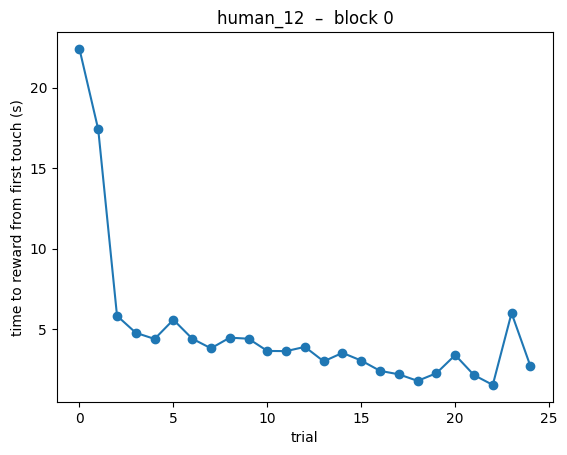

In [21]:
# ── Fetch touch-adjusted time-to-reward for one subject ──────────────────
import matplotlib.pyplot as plt

# ── parameters ────────────────────────────────────────────────────────────────
subject_id     = 'human_12'
block          = 0
touch_param_id = 0

# ── fetch ─────────────────────────────────────────────────────────────────────
trials, ttrs = (
    behavior_analysis.TrialTiming
    * experiment.BehaviorTrial
    & {'subject_id': subject_id, 'block': block, 'touch_param_id': touch_param_id}
    & 'time_to_reward IS NOT NULL'
).fetch('trial', 'time_to_reward', order_by='trial')

print(f"{len(trials)} rewarded trials found for {subject_id} block {block}")

plt.figure()
plt.plot(trials, ttrs, 'o-')
plt.xlabel('trial')
plt.ylabel('time to reward from first touch (s)')
plt.title(f'{subject_id}  –  block {block}')
plt.show()


In [121]:
# ── Inspect touch epochs for a single trial ─────────────────────────────
trial_needed = 0

epochs = (
    behavior_analysis.TrialTouchTimes.TouchEpoch
    & {'subject_id': subject_id, 'session': session,
       'trial': trial_needed, 'touch_param_id': touch_param_id}
).fetch(as_dict=True)

for e in epochs:
    label = "TOUCH" if e['is_touch'] else "no-touch"
    print(f"{label:10s}  epoch {e['epoch_idx']}:  "
          f"{e['start_time']:.3f}s – {e['end_time']:.3f}s  ({e['duration']*1000:.0f} ms)")

no-touch    epoch 0:  0.151s – 11.427s  (11186 ms)
no-touch    epoch 1:  11.530s – 11.730s  (200 ms)
no-touch    epoch 2:  11.819s – 11.819s  (2 ms)
no-touch    epoch 3:  12.127s – 12.139s  (13 ms)
no-touch    epoch 4:  12.200s – 12.226s  (27 ms)
no-touch    epoch 5:  12.861s – 12.886s  (27 ms)
no-touch    epoch 6:  13.261s – 13.318s  (58 ms)
no-touch    epoch 7:  13.732s – 13.768s  (37 ms)
no-touch    epoch 8:  14.033s – 14.049s  (17 ms)
no-touch    epoch 9:  14.226s – 14.246s  (22 ms)
no-touch    epoch 10:  14.395s – 14.463s  (69 ms)
no-touch    epoch 11:  14.518s – 14.549s  (31 ms)
no-touch    epoch 12:  14.928s – 14.950s  (24 ms)
no-touch    epoch 13:  14.970s – 14.985s  (16 ms)
no-touch    epoch 14:  15.165s – 15.166s  (2 ms)
no-touch    epoch 15:  15.220s – 15.229s  (11 ms)
no-touch    epoch 16:  15.259s – 15.262s  (4 ms)
no-touch    epoch 17:  17.776s – 17.800s  (25 ms)
no-touch    epoch 18:  17.826s – 17.835s  (10 ms)
no-touch    epoch 19:  20.291s – 20.300s  (11 ms)
no-touch  

In [ ]:
# ── Block start times (first-touch redefined) ───────────────────────────
blocks, block_starts = (
    behavior_analysis.BlockTiming
    & {'subject_id': subject_id, 'session': session,
       'touch_param_id': touch_param_id}
).fetch('block', 'block_start_time')

for b, t in zip(blocks, block_starts):
    print(f"block {b}:  first touch at {float(t):.3f} s (session-relative)")

block 0:  first touch at 11.428 s (session-relative)
block 1:  first touch at 307.248 s (session-relative)
block 2:  first touch at 565.223 s (session-relative)
block 3:  first touch at 1258.860 s (session-relative)
block 4:  first touch at 1544.450 s (session-relative)
block 5:  first touch at 2168.990 s (session-relative)


human_10  session 0  block 4
  trials: [np.int64(104), np.int64(105), np.int64(106), np.int64(107), np.int64(108), np.int64(109), np.int64(110), np.int64(111), np.int64(112), np.int64(113), np.int64(114), np.int64(115), np.int64(116), np.int64(117), np.int64(118), np.int64(119), np.int64(120), np.int64(121), np.int64(122), np.int64(123), np.int64(124), np.int64(125), np.int64(126), np.int64(127), np.int64(128)]
  touch epochs: 155  |  no-touch epochs: 131
       n_touch  total_touch_s  mean_touch_s
trial                                      
104         31         26.733         0.862
105          7         31.678         4.525
106          1         18.589        18.589
107          2          2.905         1.452
108          2          8.105         4.052
109          1          8.987         8.987
110         16         81.006         5.063
111         18         52.809         2.934
112          4          5.906         1.477
113          3          2.830         0.943
114         

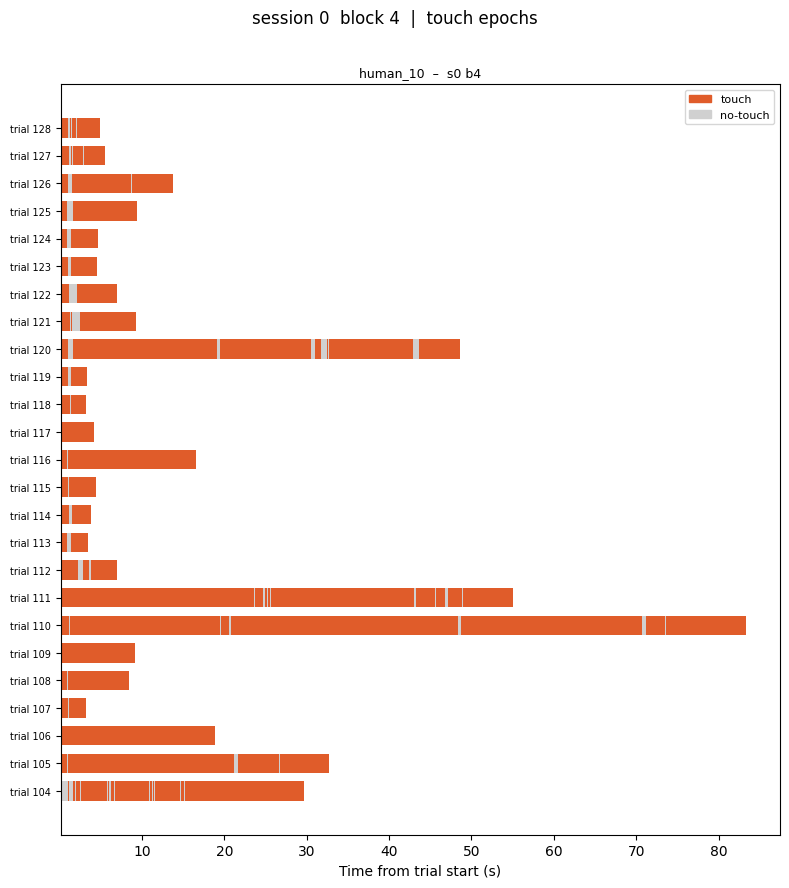

In [22]:
# ── Touch / no-touch epochs per trial in one block ───────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── parameters ───────────────────────────────────────────────────────────────
subject_ids    = ['human_10']
session        = 0
block          = 4
touch_param_id = 0
trial_range    = None   # None = all trials, or [first, last] inclusive

# ── fetch epochs for each subject ─────────────────────────────────────────────
def fetch_epochs(subject_id):
    trials_arr, is_touch_arr, epoch_idx_arr, t0_arr, t1_arr, dur_arr = (
        behavior_analysis.TrialTouchTimes.TouchEpoch
        * experiment.BehaviorTrial
        & {'subject_id': subject_id, 'session': session,
           'block': block, 'touch_param_id': touch_param_id}
    ).fetch('trial', 'is_touch', 'epoch_idx', 'start_time', 'end_time', 'duration',
            order_by='trial, is_touch DESC, epoch_idx')
    df = pd.DataFrame({
        'trial':     trials_arr,
        'is_touch':  is_touch_arr.astype(bool),
        'epoch_idx': epoch_idx_arr,
        'start':     t0_arr.astype(float),
        'end':       t1_arr.astype(float),
        'duration':  dur_arr.astype(float),
    })
    if trial_range is not None:
        df = df[df['trial'].between(trial_range[0], trial_range[1])]
    return df

data = {sid: fetch_epochs(sid) for sid in subject_ids}

# ── print summary ─────────────────────────────────────────────────────────────
for sid, epochs in data.items():
    touch = epochs[epochs['is_touch']]
    print(f'{sid}  session {session}  block {block}')
    print(f'  trials: {sorted(epochs["trial"].unique())}')
    print(f'  touch epochs: {len(touch)}  |  no-touch epochs: {len(epochs) - len(touch)}')
    if len(touch):
        print(touch.groupby('trial')['duration'].agg(['count', 'sum', 'mean']).rename(
            columns={'count': 'n_touch', 'sum': 'total_touch_s', 'mean': 'mean_touch_s'}).round(3).to_string())
    print()

# ── raster plot — one column per subject ──────────────────────────────────────
n = len(subject_ids)
fig, axes = plt.subplots(1, n, figsize=(8 * n, max(3, max(
    len(df['trial'].unique()) for df in data.values()) * 0.35)),
    sharey=False)
if n == 1:
    axes = [axes]

for ax, sid in zip(axes, subject_ids):
    epochs = data[sid]
    sorted_trials = sorted(epochs['trial'].unique())
    trial_y = {t: i for i, t in enumerate(sorted_trials)}

    for _, row in epochs.iterrows():
        color = '#e05c2a' if row['is_touch'] else '#d0d0d0'
        ax.barh(trial_y[row['trial']], row['end'] - row['start'], left=row['start'],
                height=0.7, color=color, linewidth=0)

    ax.set_yticks(range(len(sorted_trials)))
    ax.set_yticklabels([f'trial {t}' for t in sorted_trials], fontsize=7)
    ax.set_xlabel('Time from trial start (s)')
    ax.set_title(f'{sid}  –  s{session} b{block}', fontsize=9)

axes[0].legend(handles=[
    mpatches.Patch(color='#e05c2a', label='touch'),
    mpatches.Patch(color='#d0d0d0', label='no-touch'),
], loc='upper right', fontsize=8)

plt.suptitle(f'session {session}  block {block}  |  touch epochs', y=1.01)
plt.tight_layout()
plt.show()


human_6  session 0
       n_hold  total_hold_s  mean_hold_s  n_release  total_release_s  mean_release_s
block                                                                               
0         224       157.581        0.703        237           29.924           0.126
1         409       129.690        0.317        418           28.102           0.067
2        1308       519.173        0.397       1313           55.716           0.042
3         391       126.762        0.324        394           17.121           0.043
4          41        10.330        0.252         41            1.236           0.030
5         882       196.121        0.222        885           46.676           0.053


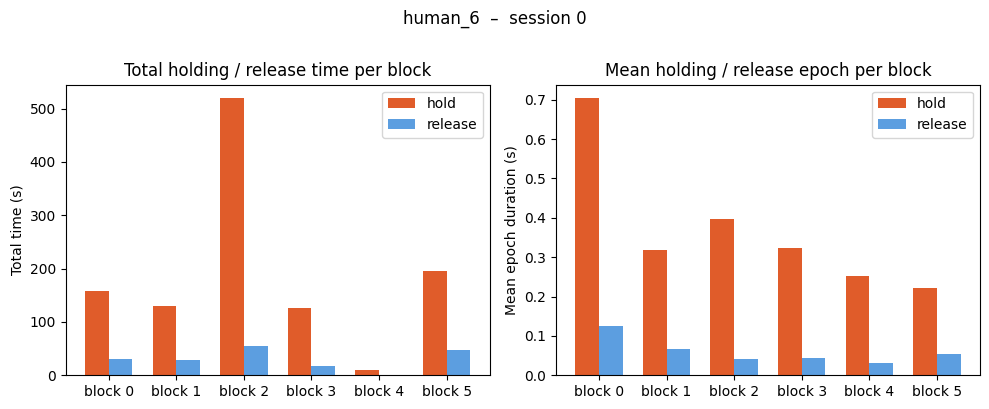

In [125]:
# ── Holding / release time per block ─────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

# ── parameters ───────────────────────────────────────────────────────────────
subject_id     = 'human_6'
session        = 0
touch_param_id = 0

# ── fetch all epochs across all blocks in the session ─────────────────────────
trials_arr, blocks_arr, is_touch_arr, dur_arr = (
    behavior_analysis.TrialTouchTimes.TouchEpoch
    * experiment.BehaviorTrial
    & {'subject_id': subject_id, 'session': session, 'touch_param_id': touch_param_id}
).fetch('trial', 'block', 'is_touch', 'duration', order_by='block, trial')

epochs = pd.DataFrame({
    'block':    blocks_arr,
    'trial':    trials_arr,
    'is_touch': is_touch_arr.astype(bool),
    'duration': dur_arr.astype(float),
})

# ── aggregate per block ────────────────────────────────────────────────────────
stats = (
    epochs
    .groupby(['block', 'is_touch'])['duration']
    .agg(total='sum', mean='mean', count='count')
    .reset_index()
)

touch_stats    = stats[stats['is_touch']].set_index('block').rename(
    columns={'total': 'total_hold_s', 'mean': 'mean_hold_s', 'count': 'n_hold'})
nottouch_stats = stats[~stats['is_touch']].set_index('block').rename(
    columns={'total': 'total_release_s', 'mean': 'mean_release_s', 'count': 'n_release'})

summary = touch_stats[['n_hold', 'total_hold_s', 'mean_hold_s']].join(
          nottouch_stats[['n_release', 'total_release_s', 'mean_release_s']], how='outer').round(3)

print(f'{subject_id}  session {session}')
print(summary.to_string())

# ── bar plot ──────────────────────────────────────────────────────────────────
blocks = summary.index.tolist()
x = range(len(blocks))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar([i - width/2 for i in x], summary['total_hold_s'],    width, label='hold',    color='#e05c2a')
axes[0].bar([i + width/2 for i in x], summary['total_release_s'], width, label='release', color='#5c9ee0')
axes[0].set_xticks(list(x)); axes[0].set_xticklabels([f'block {b}' for b in blocks])
axes[0].set_ylabel('Total time (s)'); axes[0].set_title('Total holding / release time per block')
axes[0].legend()

axes[1].bar([i - width/2 for i in x], summary['mean_hold_s'],    width, label='hold',    color='#e05c2a')
axes[1].bar([i + width/2 for i in x], summary['mean_release_s'], width, label='release', color='#5c9ee0')
axes[1].set_xticks(list(x)); axes[1].set_xticklabels([f'block {b}' for b in blocks])
axes[1].set_ylabel('Mean epoch duration (s)'); axes[1].set_title('Mean holding / release epoch per block')
axes[1].legend()

plt.suptitle(f'{subject_id}  –  session {session}', y=1.01)
plt.tight_layout()
plt.show()


In [132]:


smooth_window_time = .3 #seconds
sd_window_time = .05 #seconds
sd_treshold = .05 #std of grams 
trial_needed = 0

force_trace_time = (experiment.TrialForceTrace()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch('force_trace_time')
sample_interval = np.median(np.diff(force_trace_time[0]))
smooth_window = int(smooth_window_time/sample_interval)
sd_window = int(sd_window_time/sample_interval)


force_traces_0 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings()&{'subject_id':subject_id,'session':session,'force_axis_idx':0,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch1('force_trace_value')
force_traces_1 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'force_axis_idx':1,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch1('force_trace_value')
force_traces_2 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'force_axis_idx':2,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch1('force_trace_value')

force_trace_0_smooth = np.convolve(force_traces_0,np.ones(smooth_window)/smooth_window,mode='valid')
force_trace_1_smooth = np.convolve(force_traces_1,np.ones(smooth_window)/smooth_window,mode='valid')
force_trace_2_smooth = np.convolve(force_traces_2,np.ones(smooth_window)/smooth_window,mode='valid')

force_magnitude_smooth = np.sqrt(force_trace_0_smooth**2 + force_trace_1_smooth**2+ force_trace_2_smooth**2)
force_magnitude_smooth_sd = pd.Series(force_magnitude_smooth).rolling(window=sd_window).std()
contact_times = force_magnitude_smooth_sd>sd_treshold



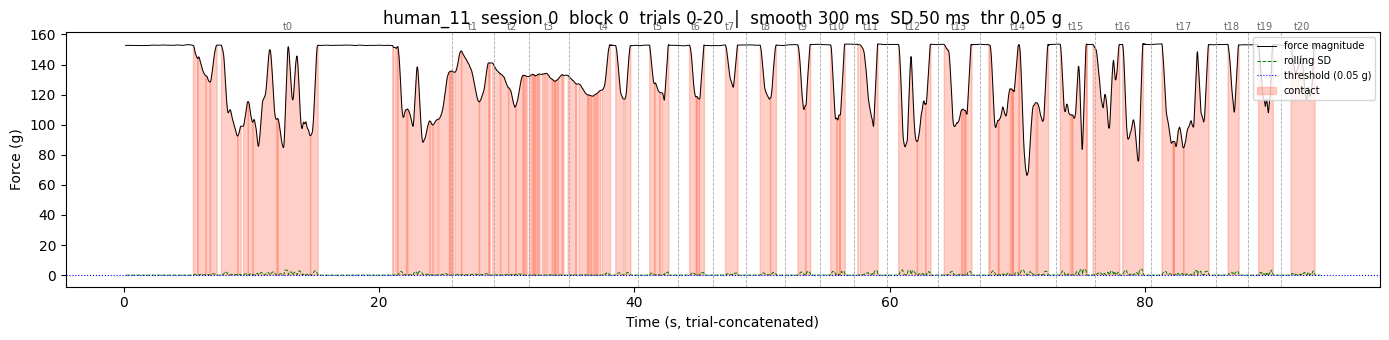

In [11]:
# ---- parameters -------------------------------------------------------
subject_id         = 'human_11'
session            = 0
block              = 0
trial_range        = [0,20]    # [first, last] inclusive
smooth_window_time = 0.3       # (s) boxcar smoothing window
sd_window_time     = 0.05      # (s) rolling SD window
sd_threshold       = 0.05      # (g) SD threshold for contact detection
contact_range      = None      # [t_start, t_end] to zoom; None = full range

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

all_trials = np.sort((
    experiment.BehaviorTrial
    & {'subject_id': subject_id, 'session': session, 'block': block}
).fetch('trial'))
trials = all_trials[(all_trials >= trial_range[0]) & (all_trials <= trial_range[1])]

if len(trials) == 0:
    print('No trials found.')
else:
    f_parts, t_parts, boundaries = [], [], [0.0]
    cursor = 0.0

    for trial in trials:
        key = {'subject_id': subject_id, 'session': session, 'trial': int(trial)}
        ftt = (experiment.TrialForceTrace & key).fetch1('force_trace_time')
        dt  = float(np.median(np.diff(ftt)))
        axis_values = (experiment.TrialForceTrace.TrialForceAxis & key).fetch(
            'force_trace_value', order_by='force_axis_idx')
        n       = min(len(v) for v in axis_values)
        raw_mag = np.sqrt(sum(v[:n] ** 2 for v in axis_values))
        t_trial = cursor + np.arange(n) * dt
        f_parts.append(raw_mag)
        t_parts.append(t_trial)
        cursor = t_trial[-1] + dt
        boundaries.append(cursor)

    raw_t   = np.concatenate(t_parts)
    raw_mag = np.concatenate(f_parts)
    dt      = float(np.median(np.diff(raw_t)))

    smooth_window = max(1, int(smooth_window_time / dt))
    sd_window     = max(2, int(sd_window_time / dt))

    smoothed = np.convolve(raw_mag, np.ones(smooth_window) / smooth_window, mode='valid')
    sd       = pd.Series(smoothed).rolling(sd_window).std().values
    half_w   = smooth_window // 2
    t        = raw_t[half_w: half_w + len(smoothed)]

    fig, ax = plt.subplots(figsize=(14, 3.5))
    ax.plot(t, smoothed, color='k',    lw=0.7, label='force magnitude')
    ax.plot(t, sd,       color='green', lw=0.7, ls='--', label='rolling SD')
    ax.axhline(sd_threshold, color='blue', lw=0.8, ls=':', label=f'threshold ({sd_threshold} g)')
    ax.fill_between(t, 0, smoothed, where=sd > sd_threshold,
                    alpha=0.3, color='tomato', label='contact')

    for tb in boundaries[1:-1]:
        ax.axvline(tb, color='#aaa', lw=0.6, ls='--')
    ylim = ax.get_ylim()
    for i, trial in enumerate(trials):
        ax.text((boundaries[i] + boundaries[i + 1]) / 2, ylim[1],
                f't{trial}', ha='center', va='bottom', fontsize=7, color='#666')

    if contact_range is not None:
        ax.set_xlim(contact_range)

    ax.set_xlabel('Time (s, trial-concatenated)')
    ax.set_ylabel('Force (g)')
    ax.set_title(f"{subject_id}  session {session}  block {block}  "
                 f"trials {trials[0]}-{trials[-1]}  |  "
                 f"smooth {smooth_window_time*1000:.0f} ms  "
                 f"SD {sd_window_time*1000:.0f} ms  thr {sd_threshold} g")
    ax.legend(fontsize=7, loc='upper right')
    plt.tight_layout()
    plt.show()


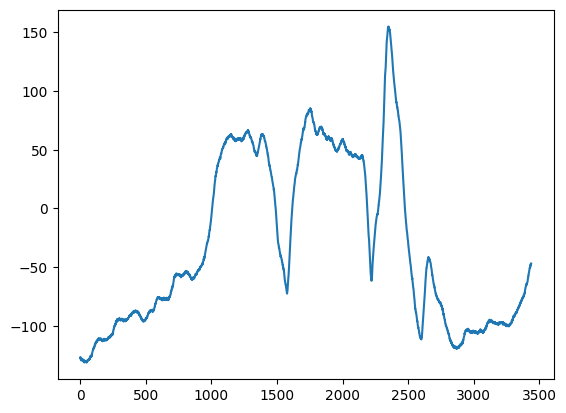

In [152]:
plt.plot(axis_values[2])

C:\Users\labadmin\AppData\Local\Temp\ipykernel_33840\2779998047.py:78: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))


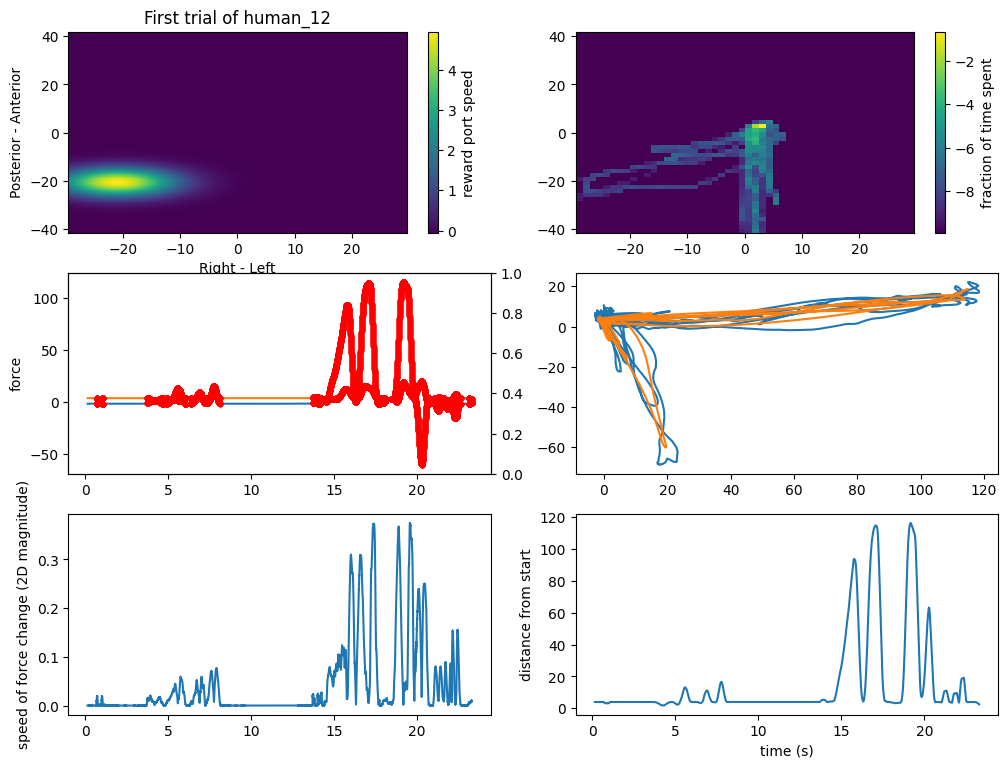

In [23]:
import matplotlib.pyplot as plt
import numpy as np
subtract_force_median = False
force_uniform_range = False
uniform_force_range= np.asarray([-1,1,-1,1])*100
subtract_median = False
smooth_window = 300
sd_window = 60
threshold_distance_for_hold = 40
trial_needed = 0


for subject_id in subject_ids_ordered[11:]:
    available_sessions = (experiment.Session()&{'subject_id':subject_id}).fetch('session')
    if 0 not in available_sessions:
        print(f'{subject_id} does not have session 0')
        continue
    # visualize targets, and how forces change over sessions and trials
    session = 0

    task_setting_ids,target_force_luts = (experiment.TaskSettings()&{'subject_id':subject_id,'session':session}).fetch('task_setting_id','target_force_lut')
    force_axes = (experiment.TaskSettings.ForceAxis()&{'subject_id':subject_id,'session':session}).fetch(as_dict=True)
    task_setting_id = task_setting_ids[0]
    target_force_lut = target_force_luts[0]

    fig = plt.figure(figsize=(12,12))
    ax_target_LUT = fig.add_subplot(4,2,1)
    force_axes_dict = {}
    for fa in force_axes:
        if fa['task_setting_id'] == task_setting_id:
            force_axes_dict[fa['force_axis_idx']] = {'force_direction':fa['force_direction'],
                                                'target_force_axes':fa['target_force_axes']}
    if force_uniform_range:
        im0 = plt.imshow(np.ones(target_force_lut.shape)*np.min(target_force_lut.flatten()),extent = uniform_force_range,alpha = 1)                                            
    im_lut = plt.imshow(target_force_lut,extent = [force_axes_dict[0]['target_force_axes'][0],force_axes_dict[0]['target_force_axes'][-1],
                                                force_axes_dict[1]['target_force_axes'][0],force_axes_dict[1]['target_force_axes'][-1]],
                                                origin='upper',
                                                cmap='viridis',
                                                aspect='auto')
    plt.xlabel(direction_dict[force_axes_dict[0]['force_direction']])
    plt.ylabel(direction_dict[force_axes_dict[1]['force_direction']])
    plt.colorbar(im_lut,label='reward port speed')
    plt.title('First trial of {}'.format(subject_id))

    
    if force_uniform_range:
        ax_target_LUT.set_xlim([uniform_force_range[0],uniform_force_range[1]])
        ax_target_LUT.set_ylim([uniform_force_range[2],uniform_force_range[3]])



    ax_force_hist = fig.add_subplot(4,2,2)
    force_traces_0 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings()&{'subject_id':subject_id,'session':session,'force_axis_idx':0,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch1('force_trace_value')
    force_traces_1 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'force_axis_idx':1,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch1('force_trace_value')
    force_traces_2 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'force_axis_idx':2,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch1('force_trace_value')
    if subtract_median:
        force_traces_0 = force_traces_0 - np.median(force_traces_0)
        force_traces_1 = force_traces_1 - np.median(force_traces_1)
        force_traces_2 = force_traces_2 - np.median(force_traces_2)
    force_trace_time = (experiment.TrialForceTrace()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch('force_trace_time')
    reward_port_time, reward_port_position = (experiment.TrialRewardPortPosition*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch('reward_port_position_time','reward_port_position_values')


    if force_uniform_range:
        histrange = [uniform_force_range[:2],uniform_force_range[:2]]
    else:
        histrange = [[force_axes_dict[0]['target_force_axes'][0],
                    force_axes_dict[0]['target_force_axes'][-1]],
                    [force_axes_dict[1]['target_force_axes'][0],
                    force_axes_dict[1]['target_force_axes'][-1]]]
    
    try:
        forcehist,binx,biny = np.histogram2d(force_traces_0,
                                            force_traces_1,
                                            range=histrange,
                                            bins=50)
        forcehist_all = forcehist.copy()
        forcehist = np.log(forcehist/sum(forcehist.flatten()))
        forcehist_ = forcehist.copy()
        forcehist_ [np.isinf(forcehist )] = 0
        forcehist[np.isinf(forcehist)] = np.nanmin(forcehist_.flatten())
        im_hist = ax_force_hist.imshow(forcehist,
                                    extent = [binx[0],binx[-1],biny[0],biny[-1]],
                                        alpha = 1,
                                        aspect= 'auto')
        plt.colorbar(im_hist,label = 'fraction of time spent')
    except:
        pass



   

    ax1 = fig.add_subplot(4,2,3)
    ax1_position = ax1.twinx()
    ax2 = fig.add_subplot(4,2,4)
    ax3 = fig.add_subplot(4,2,5,sharex=ax1)
    ax_sd = fig.add_subplot(4,2,6,sharex=ax1)



    force_trace_0_smooth = np.convolve(force_traces_0,np.ones(smooth_window)/smooth_window,mode='valid')
    force_trace_1_smooth = np.convolve(force_traces_1,np.ones(smooth_window)/smooth_window,mode='valid')
    force_trace_0_sd =  pd.Series(force_trace_0_smooth).rolling(window=sd_window).std()
    force_trace_1_sd =  pd.Series(force_trace_1_smooth).rolling(window=sd_window).std()

    online_vector_magnitude = np.sqrt(np.diff(force_trace_0_smooth)**2 + np.diff(force_trace_1_smooth)**2)
    #holding_times = distance_from_start_smooth>threshold_distance_for_hold



    force_time = np.arange(len(force_traces_0))*np.median(np.diff(np.concatenate(force_trace_time)))
    force_time_smooth = np.convolve(force_time,np.ones(smooth_window)/smooth_window,mode='valid')

    distance_from_start = np.sqrt(force_traces_0**2 + force_traces_1**2)
    distance_from_start_smooth = np.convolve(distance_from_start,np.ones(smooth_window)/smooth_window,mode='valid')

    holding_times = distance_from_start_smooth>threshold_distance_for_hold

    force_magnitude_smooth = np.sqrt(force_trace_0_smooth**2 + force_trace_1_smooth**2)
    force_magnitude_smooth_sd = pd.Series(force_magnitude_smooth).rolling(window=sd_window).std()
    contact_times = force_magnitude_smooth_sd>.05#np.percentile(force_magnitude_smooth_sd,5)

    force_angle_smooth = np.degrees(np.arctan2(force_trace_1_smooth, force_trace_0_smooth)) 

    online_vector_magnitude = np.sqrt(np.diff(force_trace_0_smooth)**2 + np.diff(force_trace_1_smooth)**2)
    online_vector_angle = np.degrees(np.arctan2(np.diff(force_trace_1_smooth), np.diff(force_trace_0_smooth)))
    movement_threshold = 0.001
    movement_times = online_vector_magnitude>movement_threshold

    ax1.plot(force_time_smooth,force_trace_0_smooth,label=direction_dict[force_axes_dict[0]['force_direction']])
    ax1.plot(force_time_smooth,force_trace_1_smooth,label=direction_dict[force_axes_dict[1]['force_direction']])
    ax1.plot(force_time_smooth[contact_times],force_trace_0_smooth[contact_times],'r.',label=direction_dict[force_axes_dict[0]['force_direction']])
    ax1.plot(force_time_smooth[contact_times],force_trace_1_smooth[contact_times],'r.',label=direction_dict[force_axes_dict[1]['force_direction']])
    
    ax1.set_ylabel('force')

    ax2.plot(force_traces_0,force_traces_1)
    ax2.plot(force_trace_0_smooth,force_trace_1_smooth)
    #ax2.plot(force_trace_0_smooth[holding_times],force_trace_1_smooth[holding_times],'r.')


    d0 = np.diff(force_trace_0_smooth)
    d1 = np.diff(force_trace_1_smooth)
    speed_2d = np.sqrt(d0**2 + d1**2)

    ax3.plot(force_time_smooth[:-1], speed_2d, label='2D force speed')
    ax3.set_ylabel('speed of force change (2D magnitude)')


    mean_sd = np.mean([force_trace_0_sd,force_trace_1_sd],axis=0)


   # distance_from_start_smooth[contact_times==False] = np.nan
    ax_sd.plot(force_time_smooth,distance_from_start_smooth,label='distance')
    #ax_sd.plot(force_time_smooth[holding_times],distance_from_start_smooth[holding_times],color = 'red',label='holding times')
    ax_sd.set_xlabel('time (s)')
    ax_sd.set_ylabel('distance from start')

    break


    
    

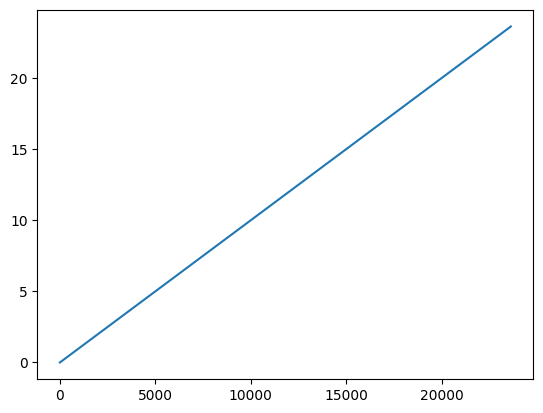

In [8]:
plt.plot(reward_port_time[0])

ValueError: zero-dimensional arrays cannot be concatenated

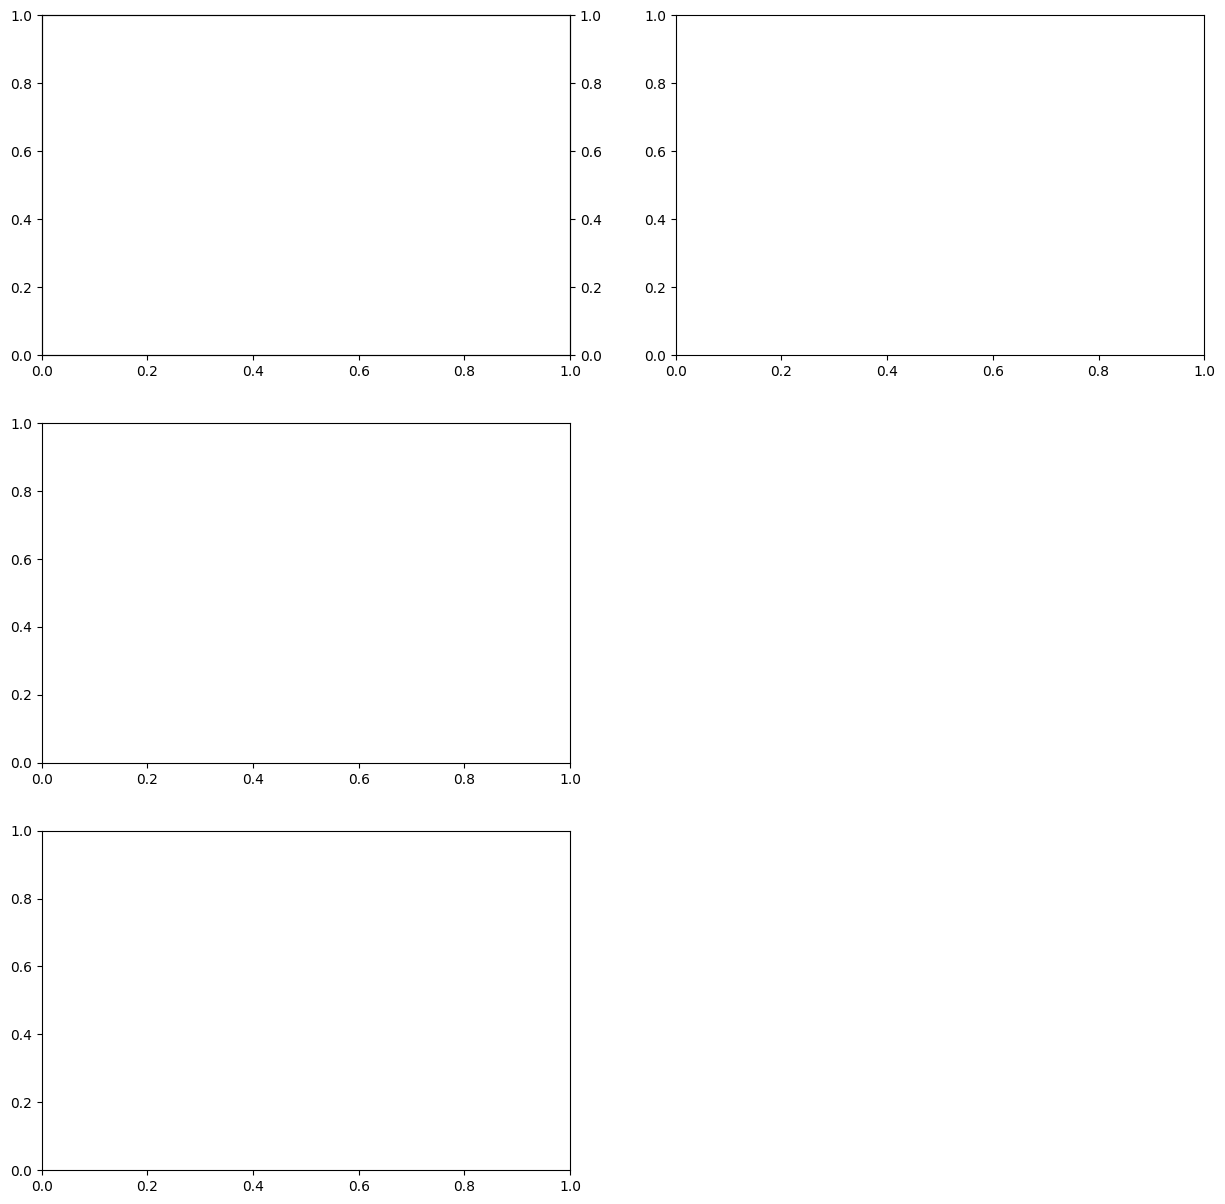

In [9]:
smooth_window = 30
sd_window = 60
threshold_distance_for_hold = 40
needed_trials = [18]

fig= plt.figure(figsize = [15,15])
ax1 = fig.add_subplot(3,2,1)
ax1_position = ax1.twinx()
ax2 = fig.add_subplot(3,2,2)
ax3 = fig.add_subplot(3,2,3,sharex=ax1)
ax_sd = fig.add_subplot(3,2,5,sharex=ax1)
force_trace_0 = np.concatenate(force_traces_0[needed_trials])
force_trace_1 = np.concatenate(force_traces_1[needed_trials])

reward_port_time_now = np.concatenate(reward_port_time[needed_trials])
reward_port_position_now = np.concatenate(reward_port_position[needed_trials])
reward_port_time_now =  np.arange(len(reward_port_position_now))*np.median(np.diff(np.concatenate(reward_port_time[needed_trials])[::2])/2)

force_trace_0_smooth = np.convolve(force_trace_0,np.ones(smooth_window)/smooth_window,mode='valid')
force_trace_1_smooth = np.convolve(force_trace_1,np.ones(smooth_window)/smooth_window,mode='valid')
force_trace_0_sd =  pd.Series(force_trace_0_smooth).rolling(window=sd_window).std()
force_trace_1_sd =  pd.Series(force_trace_1_smooth).rolling(window=sd_window).std()

distance_from_start = np.sqrt(np.concatenate(force_traces_0[needed_trials])**2+np.concatenate(force_traces_1[needed_trials])**2)
distance_from_start_smooth = np.convolve(distance_from_start,np.ones(smooth_window)/smooth_window,mode='valid')

holding_times = distance_from_start_smooth>threshold_distance_for_hold



force_time = np.arange(len(force_trace_0))*np.median(np.diff(np.concatenate(force_trace_time)))
force_time_smooth = np.convolve(force_time,np.ones(smooth_window)/smooth_window,mode='valid')

ax1.plot(force_time_smooth,force_trace_0_smooth,label=direction_dict[force_axes_dict[0]['force_direction']])
ax1.plot(force_time_smooth,force_trace_1_smooth,label=direction_dict[force_axes_dict[1]['force_direction']])
ax1.set_ylabel('force')
#ax1_position.plot(reward_port_time_now,reward_port_position_now,'k--',label='reward port position')

ax2.plot(force_trace_0,force_trace_1)
ax2.plot(force_trace_0_smooth,force_trace_1_smooth)
ax2.plot(force_trace_0_smooth[holding_times],force_trace_1_smooth[holding_times],'r.')


#ax3.plot(force_time_smooth[:-1],np.diff(force_trace_0_smooth),label=direction_dict[force_axes_dict[0]['force_direction']])
#ax3.plot(force_time_smooth[:-1],np.diff(force_trace_1_smooth),label=direction_dict[force_axes_dict[1]['force_direction']])
#ax3.set_ylabel('speed of force change')

d0 = np.diff(force_trace_0_smooth)
d1 = np.diff(force_trace_1_smooth)
speed_2d = np.sqrt(d0**2 + d1**2)

ax3.plot(force_time_smooth[:-1], speed_2d, label='2D force speed')
ax3.set_ylabel('speed of force change (2D magnitude)')


mean_sd = np.mean([force_trace_0_sd,force_trace_1_sd],axis=0)
ax_sd.plot(force_time_smooth,distance_from_start_smooth,label='distance')
ax_sd.plot(force_time_smooth[holding_times],distance_from_start_smooth[holding_times],color = 'red',label='holding times')
ax_sd.set_xlabel('time (s)')
ax_sd.set_ylabel('distance from start')
#ax_sd.plot(force_time_smooth,mean_sd,label='mean sd')
#
#ax_sd.plot(force_time_smooth,force_trace_0_sd,label=direction_dict[force_axes_dict[0]['force_direction']])
#ax_sd.plot(force_time_smooth,force_trace_1_sd,label=direction_dict[force_axes_dict[1]['force_direction']])
#plt.xlim([5,10])

Text(0, 0.5, 'speed of force change (2D magnitude)')

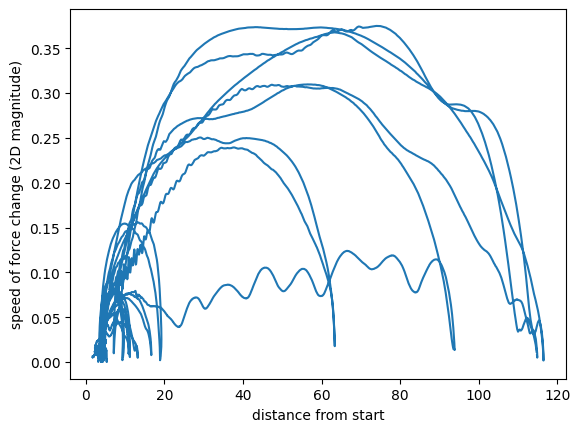

In [ ]:
plt.plot(distance_from_start_smooth[:-1],speed_2d)
plt.xlabel('distance from start')
plt.ylabel('speed of force change (2D magnitude)')

In [11]:
import matplotlib.pyplot as plt
import numpy as np
subtract_force_median = False
force_uniform_range = True
uniform_force_range= np.asarray([-1,1,-1,1])*100
subtract_median = False
smooth_window = 300
sd_window = 60
threshold_distance_for_hold = 40
trial_needed = 6


for subject_id in subject_ids_ordered[5]:
    available_sessions = (experiment.Session()&{'subject_id':subject_id}).fetch('session')
    if 0 not in available_sessions:
        print(f'{subject_id} does not have session 0')
        continue
    # visualize targets, and how forces change over sessions and trials
    session = 0

    task_setting_ids,target_force_luts = (experiment.TaskSettings()&{'subject_id':subject_id,'session':session}).fetch('task_setting_id','target_force_lut')
    force_axes = (experiment.TaskSettings.ForceAxis()&{'subject_id':subject_id,'session':session}).fetch(as_dict=True)
    task_setting_id = task_setting_ids[0]
    target_force_lut = target_force_luts[0]

    fig = plt.figure(figsize=(12,12))
    ax_target_LUT = fig.add_subplot(4,2,1)
    force_axes_dict = {}
    for fa in force_axes:
        if fa['task_setting_id'] == task_setting_id:
            force_axes_dict[fa['force_axis_idx']] = {'force_direction':fa['force_direction'],
                                                'target_force_axes':fa['target_force_axes']}
    if force_uniform_range:
        im0 = plt.imshow(np.ones(target_force_lut.shape)*np.min(target_force_lut.flatten()),extent = uniform_force_range,alpha = 1)                                            
    im_lut = plt.imshow(target_force_lut,extent = [force_axes_dict[0]['target_force_axes'][0],force_axes_dict[0]['target_force_axes'][-1],
                                                force_axes_dict[1]['target_force_axes'][0],force_axes_dict[1]['target_force_axes'][-1]],
                                                origin='upper',
                                                cmap='viridis',
                                                aspect='auto')
    plt.xlabel(direction_dict[force_axes_dict[0]['force_direction']])
    plt.ylabel(direction_dict[force_axes_dict[1]['force_direction']])
    plt.colorbar(im_lut,label='reward port speed')
    plt.title('Second trial of {}'.format(subject_id))

    
    if force_uniform_range:
        ax_target_LUT.set_xlim([uniform_force_range[0],uniform_force_range[1]])
        ax_target_LUT.set_ylim([uniform_force_range[2],uniform_force_range[3]])



    ax_force_hist = fig.add_subplot(4,2,2)
    force_traces_0 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings()&{'subject_id':subject_id,'session':session,'force_axis_idx':0,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch1('force_trace_value')
    force_traces_1 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'force_axis_idx':1,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch1('force_trace_value')
    force_traces_2 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'force_axis_idx':2,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch1('force_trace_value')
    if subtract_median:
        force_traces_0 = force_traces_0 - np.median(force_traces_0)
        force_traces_1 = force_traces_1 - np.median(force_traces_1)
        force_traces_2 = force_traces_2 - np.median(force_traces_2)
    force_trace_time = (experiment.TrialForceTrace()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch('force_trace_time')
    reward_port_time, reward_port_position = (experiment.TrialRewardPortPosition*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch('reward_port_position_time','reward_port_position_values')


    if force_uniform_range:
        histrange = [uniform_force_range[:2],uniform_force_range[:2]]
    else:
        histrange = [[force_axes_dict[0]['target_force_axes'][0],
                    force_axes_dict[0]['target_force_axes'][-1]],
                    [force_axes_dict[1]['target_force_axes'][0],
                    force_axes_dict[1]['target_force_axes'][-1]]]
    
    try:
        forcehist,binx,biny = np.histogram2d(force_traces_0,
                                            force_traces_1,
                                            range=histrange,
                                            bins=50)
        forcehist_all = forcehist.copy()
        forcehist = np.log(forcehist/sum(forcehist.flatten()))
        forcehist_ = forcehist.copy()
        forcehist_ [np.isinf(forcehist )] = 0
        forcehist[np.isinf(forcehist)] = np.nanmin(forcehist_.flatten())
        im_hist = ax_force_hist.imshow(forcehist,
                                    extent = [binx[0],binx[-1],biny[0],biny[-1]],
                                        alpha = 1,
                                        aspect= 'auto')
        plt.colorbar(im_hist,label = 'fraction of time spent')
    except:
        pass



   

    ax1 = fig.add_subplot(4,2,3)
    ax1_position = ax1.twinx()
    ax2 = fig.add_subplot(4,2,4)
    ax3 = fig.add_subplot(4,2,5,sharex=ax1)
    ax_sd = fig.add_subplot(4,2,6,sharex=ax1)



    force_trace_0_smooth = np.convolve(force_traces_0,np.ones(smooth_window)/smooth_window,mode='valid')
    force_trace_1_smooth = np.convolve(force_traces_1,np.ones(smooth_window)/smooth_window,mode='valid')
    force_trace_0_sd =  pd.Series(force_trace_0_smooth).rolling(window=sd_window).std()
    force_trace_1_sd =  pd.Series(force_trace_1_smooth).rolling(window=sd_window).std()

    online_vector_magnitude = np.sqrt(np.diff(force_trace_0_smooth)**2 + np.diff(force_trace_1_smooth)**2)
    #holding_times = distance_from_start_smooth>threshold_distance_for_hold



    force_time = np.arange(len(force_traces_0))*np.median(np.diff(np.concatenate(force_trace_time)))
    force_time_smooth = np.convolve(force_time,np.ones(smooth_window)/smooth_window,mode='valid')

    distance_from_start = np.sqrt(force_traces_0**2 + force_traces_1**2)
    distance_from_start_smooth = np.convolve(distance_from_start,np.ones(smooth_window)/smooth_window,mode='valid')

    holding_times = distance_from_start_smooth>threshold_distance_for_hold

    force_magnitude_smooth = np.sqrt(force_trace_0_smooth**2 + force_trace_1_smooth**2)
    force_magnitude_smooth_sd = pd.Series(force_magnitude_smooth).rolling(window=sd_window).std()
    contact_times = force_magnitude_smooth_sd>.05#np.percentile(force_magnitude_smooth_sd,5)

    force_angle_smooth = np.degrees(np.arctan2(force_trace_1_smooth, force_trace_0_smooth)) 

    online_vector_magnitude = np.sqrt(np.diff(force_trace_0_smooth)**2 + np.diff(force_trace_1_smooth)**2)
    online_vector_angle = np.degrees(np.arctan2(np.diff(force_trace_1_smooth), np.diff(force_trace_0_smooth)))
    movement_threshold = 0.001
    movement_times = online_vector_magnitude>movement_threshold

    ax1.plot(force_time_smooth,force_trace_0_smooth,label=direction_dict[force_axes_dict[0]['force_direction']])
    ax1.plot(force_time_smooth,force_trace_1_smooth,label=direction_dict[force_axes_dict[1]['force_direction']])
    ax1.plot(force_time_smooth[contact_times],force_trace_0_smooth[contact_times],'r.',label=direction_dict[force_axes_dict[0]['force_direction']])
    ax1.plot(force_time_smooth[contact_times],force_trace_1_smooth[contact_times],'r.',label=direction_dict[force_axes_dict[1]['force_direction']])
    
    ax1.set_ylabel('force')

    ax2.plot(force_traces_0,force_traces_1)
    ax2.plot(force_trace_0_smooth,force_trace_1_smooth)
    #ax2.plot(force_trace_0_smooth[holding_times],force_trace_1_smooth[holding_times],'r.')


    d0 = np.diff(force_trace_0_smooth)
    d1 = np.diff(force_trace_1_smooth)
    speed_2d = np.sqrt(d0**2 + d1**2)

    ax3.plot(force_time_smooth[:-1], speed_2d, label='2D force speed')
    ax3.set_ylabel('speed of force change (2D magnitude)')


    mean_sd = np.mean([force_trace_0_sd,force_trace_1_sd],axis=0)


    distance_from_start_smooth[contact_times==False] = np.nan
    ax_sd.plot(force_time_smooth,distance_from_start_smooth,label='distance')
    #ax_sd.plot(force_time_smooth[holding_times],distance_from_start_smooth[holding_times],color = 'red',label='holding times')
    ax_sd.set_xlabel('time (s)')
    ax_sd.set_ylabel('distance from start')

    break


    
    

h does not have session 0
u does not have session 0
m does not have session 0
a does not have session 0
n does not have session 0
_ does not have session 0
6 does not have session 0


Fetching data…
Done.
Time offsets computed for ['human_11', 'human_12']
human_11 (block 0): 8.05–11.00 s  (2974 samples, total 93.72 s)
human_12 (block 0): 14.55–17.50 s  (2974 samples, total 126.42 s)


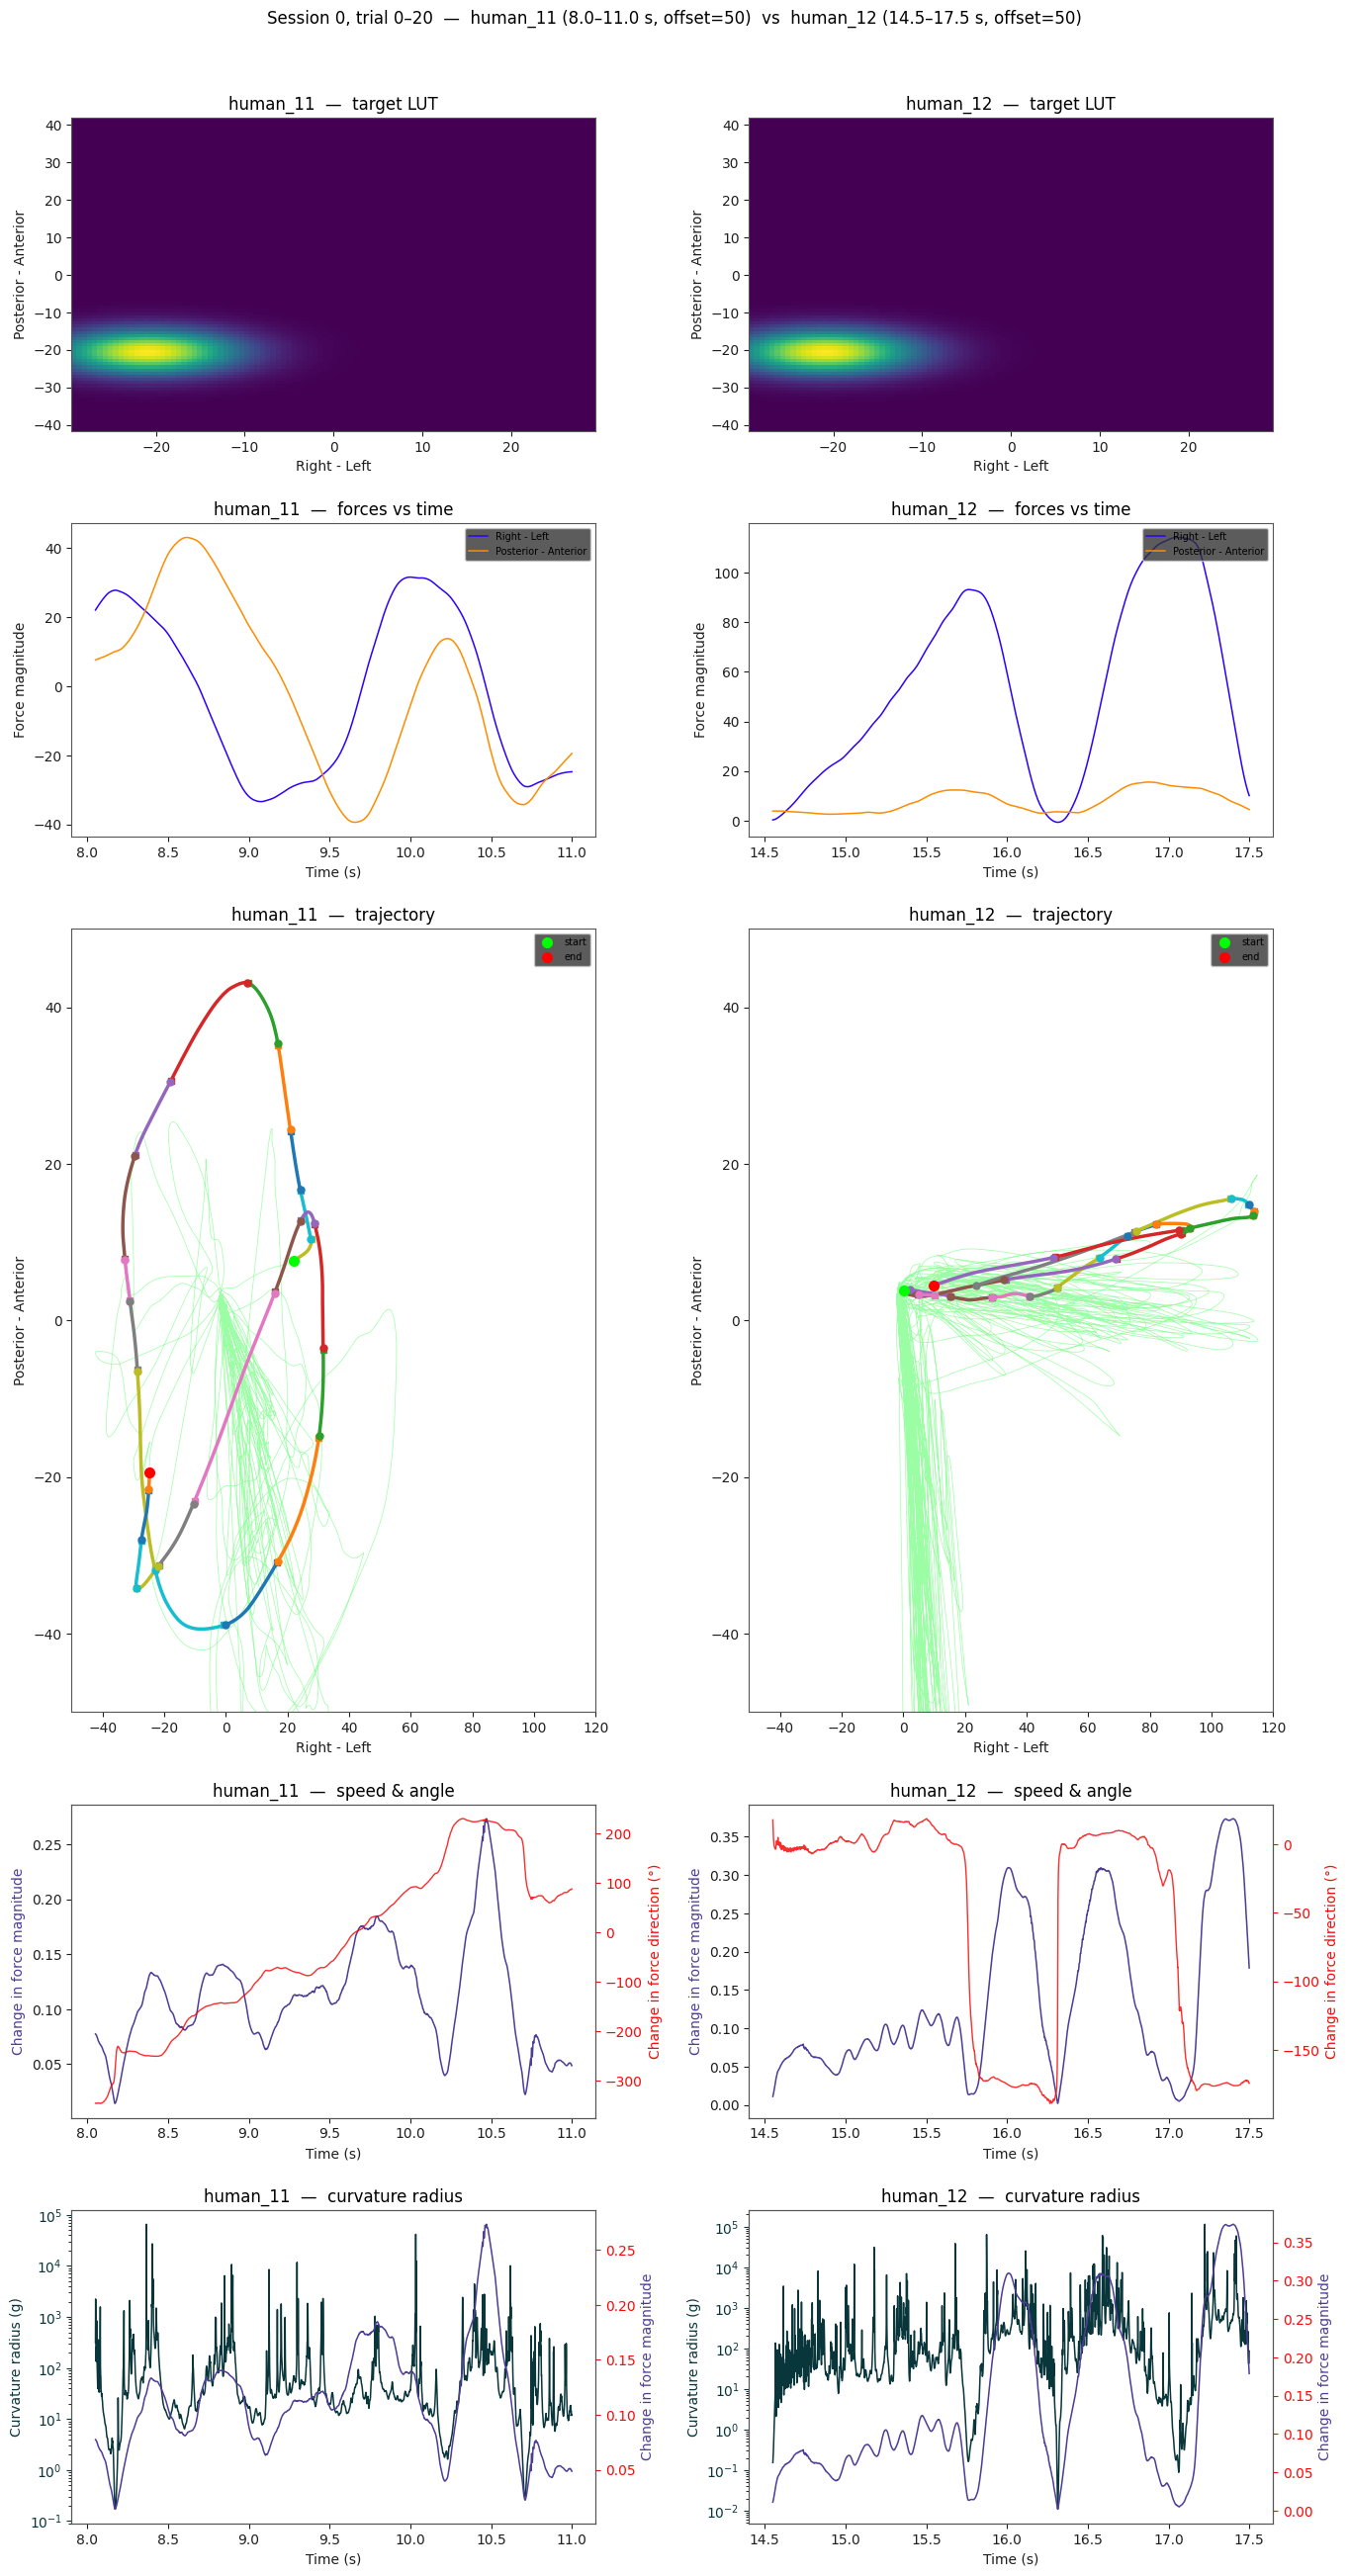

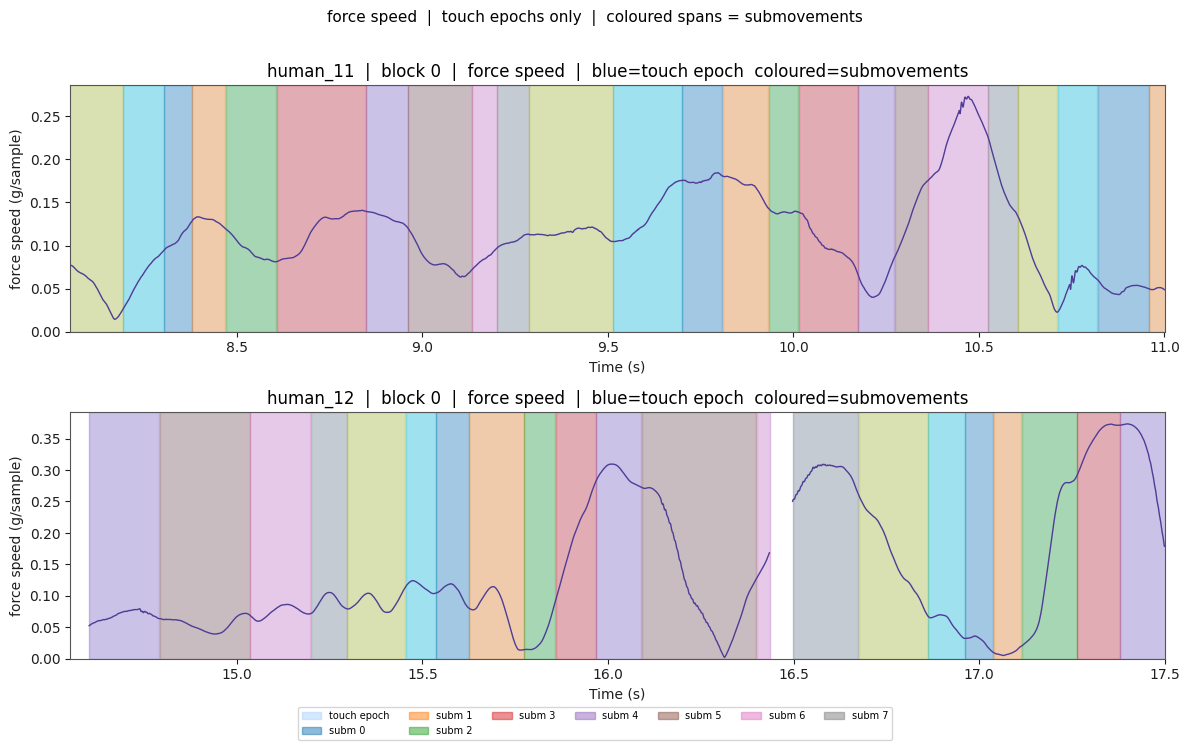

In [29]:
# force traces, 2-D trajectories & submovement timing for a single session
# ── parameters ────────────────────────────────────────────────────────────────
subjects      = ['human_11','human_12']
t_ranges      = ['8,11','14.5,17.5']
start_offset  = 50
session       = 0
trial         = [0,21]     # single int  OR  [start, end] to concatenate a range
block         = 0        # None → first available block; or set e.g. 0, 1, 2 …
smooth_window = 300

# ── labels ────────────────────────────────────────────────────────────────────
L = dict(
    dir         = {'LR': 'Left - Right', 'RL': 'Right - Left',
                   'AP': 'Anterior - Posterior', 'PA': 'Posterior - Anterior'},
    lut_title   = '{subj}  —  target LUT',
    force_title = '{subj}  —  forces vs time',
    force_y     = 'Force magnitude',
    traj_title  = '{subj}  —  trajectory',
    start       = 'start', end  = 'end',
    vec_title   = '{subj}  —  speed & angle',
    vec_mag     = 'Change in force magnitude',
    vec_ang     = 'Change in force direction (°)',
    curv_title  = '{subj}  —  curvature radius',
    curv_y      = 'Curvature radius (g)',
    time_x      = 'Time (s)',
    sess_word   = 'Session', trial_word = 'trial',
    offset_word = 'offset', vs_word    = 'vs',
)

DARK  = "#ffffff"
BG    = "#ffffff"
C_F0  = "#2f00ff"
C_F1  = "#ff8c00"
C_MAG = "#4e3c97"
C_ANG = "#fc0808"
C_CRV = "#09363b"

# ── helper: fetch + preprocess one subject ────────────────────────────────────

import numpy as np

##


def menger_curvature_radius(x, y, half_window=1):
    """
    Radius of curvature using three-point (Menger) formula.
    Uses points [i - half_window, i, i + half_window] to reduce noise sensitivity.
    """
    n = len(x)
    radius = np.full(n, np.inf)

    for i in range(half_window, n - half_window):
        x1, y1 = x[i - half_window], y[i - half_window]
        x2, y2 = x[i],               y[i]
        x3, y3 = x[i + half_window], y[i + half_window]

        # Side lengths
        a = np.hypot(x2 - x1, y2 - y1)
        b = np.hypot(x3 - x2, y3 - y2)
        c = np.hypot(x3 - x1, y3 - y1)

        # Triangle area (cross product / 2)
        area = abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1)) / 2

        if area > 1e-12:
            radius[i] = (a * b * c) / (4 * area)

    return radius

def _fetch(subject_id, session, trial, sw, block=None):
    # resolve block → task_setting_id
    avail_blocks = (experiment.Block() &
                    {'subject_id': subject_id, 'session': session}).fetch('block')
    if len(avail_blocks) == 0:
        avail_sessions = (experiment.Session() & {'subject_id': subject_id}).fetch('session')
        raise ValueError(f"No blocks for {subject_id} session {session}. "
                         f"Available sessions: {avail_sessions}")
    blk = block if block is not None else avail_blocks[0]

    tsid, lut = (experiment.TaskSettings() * experiment.Block() &
                 {'subject_id': subject_id, 'session': session,
                  'block': blk}).fetch1('task_setting_id', 'target_force_lut')

    fa_rows = (experiment.TaskSettings.ForceAxis() &
               {'subject_id': subject_id, 'session': session}).fetch(as_dict=True)
    fad = {r['force_axis_idx']: {'force_direction':   r['force_direction'],
                                  'target_force_axes': r['target_force_axes']}
           for r in fa_rows if r['task_setting_id'] == tsid}

    # join via Block (not TaskSettings) to get correct per-trial filtering
    base = (experiment.TrialForceTrace.TrialForceAxis() *
            experiment.BehaviorTrial() * experiment.Block())

    trial_list = (list(range(int(trial[0]), int(trial[1])))
                  if isinstance(trial, (list, tuple)) and not isinstance(trial, int)
                  else [int(trial)])

    f0_parts, f1_parts, t_parts = [], [], []
    for tr in trial_list:
        key = {'subject_id': subject_id, 'session': session, 'block': blk, 'trial': tr}
        try:
            f0r = (base & {**key, 'force_axis_idx': 0}).fetch1('force_trace_value')
            f1r = (base & {**key, 'force_axis_idx': 1}).fetch1('force_trace_value')
            t_chunks = (experiment.TrialForceTrace() * experiment.BehaviorTrial() *
                        experiment.Block() & key).fetch('force_trace_time')
            dt = np.median(np.diff(np.concatenate(t_chunks)))
            f0_parts.append(f0r);  f1_parts.append(f1r)
            t_parts.append(np.arange(len(f0r)) * dt)
        except Exception as e:
            print(f"  skipping trial {tr}: {e}")

    t_cont, offset = [], 0.0
    for tp in t_parts:
        t_cont.append(tp + offset)
        offset += tp[-1] + (tp[1] - tp[0]) if len(tp) > 1 else tp[-1]
    raw_t   = np.concatenate(t_cont)
    f0r_all = np.concatenate(f0_parts)
    f1r_all = np.concatenate(f1_parts)

    f0  = np.convolve(f0r_all, np.ones(sw)/sw, mode='valid')
    f1  = np.convolve(f1r_all, np.ones(sw)/sw, mode='valid')
    t   = np.convolve(raw_t,   np.ones(sw)/sw, mode='valid')
    mag = np.sqrt(np.diff(f0)**2 + np.diff(f1)**2)
    ang = np.degrees(np.unwrap(np.arctan2(np.diff(f1), np.diff(f0))))
    curvature_radius = menger_curvature_radius(f0, f1, half_window=5)#compute_trajectory_kinematics

    return dict(f0=f0, f1=f1, t=t, mag=mag, ang=ang, lut=lut, fad=fad, block=blk,
                curvature_radius=curvature_radius)

print("Fetching data…")
data = [_fetch(s, session, trial, smooth_window, block) for s in subjects]
print("Done.")
if t_ranges is None:
    t_ranges = [(float(d['t'][0]), float(d['t'][-1])) for d in data]
else:
    t_ranges = [
        tuple(float(x) for x in r.split(',')) if isinstance(r, str) else tuple(r)
        for r in t_ranges
    ]

# ── submovement parameters (used in trajectory + submovement figure) ──────────
touch_param_id = 0
sat_param_id   = 0
subm_param_id  = 0

import matplotlib.patches as mpatches
SUBM_CMAP = plt.get_cmap('tab10')

_trial_list = (list(range(int(trial[0]), int(trial[1])))
               if isinstance(trial, (list, tuple)) else [int(trial)])

_base_join = (experiment.TrialForceTrace.TrialForceAxis() *
              experiment.BehaviorTrial() * experiment.Block())

_t_off_lists = {}
for _s, _d in zip(subjects, data):
    _blk_o = _d['block']
    _tol, _toff = [], 0.0
    for _tr in _trial_list:
        _k = {'subject_id': _s, 'session': session,
              'block': _blk_o, 'trial': _tr}
        try:
            _f0r = (_base_join & {**_k, 'force_axis_idx': 0}
                    ).fetch1('force_trace_value')
            _tch = (experiment.TrialForceTrace() *
                    experiment.BehaviorTrial() *
                    experiment.Block() & _k).fetch('force_trace_time')
            _dt  = float(np.median(np.diff(np.concatenate(_tch))))
            _ns  = len(_f0r)
        except Exception:
            _dt, _ns = 0.001, 0
        _tol.append((_tr, _toff))
        _toff += _ns * _dt
    _t_off_lists[_s] = _tol
print('Time offsets computed for', list(_t_off_lists))

# ── figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(5, len(subjects),
                         figsize=(7 * len(subjects), 26), facecolor=DARK,
                         gridspec_kw={'height_ratios': [1, 1, 2.5, 1, 1]})
if len(subjects) == 1:
    axes = axes[:, np.newaxis]

_trial_str = f"{trial[0]}–{trial[1]-1}" if isinstance(trial, (list,tuple)) else str(trial)
_parts = [f"{s} ({tr[0]}–{tr[1]} s, {L['offset_word']}={start_offset})"
for s, tr in zip(subjects, t_ranges)]
fig.suptitle(
    f"{L['sess_word']} {session}, {L['trial_word']} {_trial_str}  —  "
    + f"  {L['vs_word']}  ".join(_parts),
    color='black', fontsize=12, y=1.005)

for ax in axes.flat:
    ax.set_facecolor(BG)
    ax.tick_params(colors="#1f1e1e")
    for sp in ax.spines.values():
        sp.set_edgecolor('#555')
    ax.xaxis.label.set_color("#1f1e1e")
    ax.yaxis.label.set_color("#1f1e1e")
    ax.title.set_color('black')

for col, (d, subj, (t0, t1)) in enumerate(zip(data, subjects, t_ranges)):
    f0, f1, ts = d['f0'], d['f1'], d['t']
    mag, ang   = d['mag'], d['ang']
    curv_r     = d['curvature_radius']
    t_v = ts[:-1];  lut = d['lut'];  fad = d['fad'];  N = len(ts)

    i0_raw = min(int(np.searchsorted(ts, t0)), N - 1)
    i1     = min(int(np.searchsorted(ts, t1)), N - 1)
    i0     = min(i0_raw + start_offset, i1)
    sl     = slice(i0, i1)
    sl_v   = slice(i0, min(i1, len(mag)))
    sl_c   = slice(i0, min(i1, len(curv_r)))

    print(f"{subj} (block {d['block']}): {ts[i0]:.2f}–{ts[i1]:.2f} s  "
          f"({i1-i0} samples, total {ts[-1]:.2f} s)")

    dir0 = L['dir'][fad[0]['force_direction']]
    dir1 = L['dir'][fad[1]['force_direction']]

    # row 0: target LUT
    ax = axes[0, col]
    ax.imshow(lut,
              extent=[fad[0]['target_force_axes'][0], fad[0]['target_force_axes'][-1],
                      fad[1]['target_force_axes'][0], fad[1]['target_force_axes'][-1]],
              origin='upper', cmap='viridis', aspect='auto')
    ax.set_xlabel(dir0);  ax.set_ylabel(dir1)
    ax.set_title(L['lut_title'].format(subj=subj), color='black')

    # row 1: force vs time
    ax = axes[1, col]
    ax.plot(ts[sl], f0[sl], color=C_F0, lw=1.1, label=dir0)
    ax.plot(ts[sl], f1[sl], color=C_F1, lw=1.1, label=dir1)
    ax.set_xlabel(L['time_x']);  ax.set_ylabel(L['force_y'])
    ax.set_title(L['force_title'].format(subj=subj), color='black')
    ax.legend(fontsize=7, facecolor='#333', labelcolor='black', loc='upper right')

    # row 2: trajectory — gray background, colored per submovement
    ax = axes[2, col]
    ax.plot(f0, f1, color='#07fd1f', lw=0.5, alpha=0.4)  # full background
    for _tr2, _toff2 in _t_off_lists[subj]:
        _tk2 = {'subject_id': subj, 'session': session, 'trial': int(_tr2)}
        _epq2 = (behavior_analysis.TrialTouchTimes.TouchEpoch &
                 {**_tk2, 'sat_param_id': sat_param_id,
                  'touch_param_id': touch_param_id, 'is_touch': True})
        if len(_epq2):
            for _est2, _een2 in zip(
                    *_epq2.fetch('start_time', 'end_time',
                                  order_by='epoch_idx')):
                _j0 = max(int(np.searchsorted(ts, _toff2 + float(_est2))), i0)
                _j1 = min(int(np.searchsorted(ts, _toff2 + float(_een2))), i1)
                if _j1 > _j0:
                    ax.plot(f0[_j0:_j1], f1[_j0:_j1],
                            color='#888', lw=1.2, zorder=2)
        _smq2 = (behavior_analysis.TrialSubmovements.Submovement &
                 {**_tk2, 'sat_param_id': sat_param_id,
                  'touch_param_id': touch_param_id,
                  'subm_param_id': subm_param_id})
        if len(_smq2):
            _ss2, _se2, _si2 = _smq2.fetch(
                'start_time', 'end_time', 'submovement_idx',
                order_by='submovement_idx')
            for _st2, _en2, _idx2 in zip(_ss2, _se2, _si2):
                _j0 = max(int(np.searchsorted(ts, _toff2 + float(_st2))), i0)
                _j1 = min(int(np.searchsorted(ts, _toff2 + float(_en2))), i1)
                if _j1 > _j0:
                    _c2 = SUBM_CMAP(int(_idx2) % 10)
                    ax.plot(f0[_j0:_j1], f1[_j0:_j1],
                            color=_c2, lw=2.5, zorder=3)
                    ax.plot(f0[_j0], f1[_j0],
                            'o', color=_c2, ms=5, zorder=4)
                    ax.plot(f0[_j1-1], f1[_j1-1],
                            's', color=_c2, ms=5, zorder=4)
    ax.plot(f0[i0], f1[i0], 'o', color='lime', ms=7, zorder=5, label=L['start'])
    ax.plot(f0[i1], f1[i1], 'o', color='red',  ms=7, zorder=5, label=L['end'])
    ax.set_xlabel(dir0);  ax.set_ylabel(dir1)
    ax.set_xlim(-50, 120);  ax.set_ylim(-50, 50)
    ax.set_title(L['traj_title'].format(subj=subj), color='black')
    ax.legend(fontsize=7, facecolor='#333', labelcolor='black')

    # row 3: speed & angle (twin axes)
    ax  = axes[3, col]
    axr = ax.twinx()
    axr.set_facecolor(BG);  axr.tick_params(colors=C_ANG)
    axr.yaxis.label.set_color(C_ANG)
    for sp in axr.spines.values():
        sp.set_edgecolor('#555')

    ang_win     = ang[sl_v]
    ang_centred = ang_win - np.round(np.nanmean(ang_win) / 360) * 360

    ax.plot(t_v[sl_v], mag[sl_v], color=C_MAG, lw=1.1)
    axr.plot(t_v[sl_v], ang_centred, color=C_ANG, lw=1.0, alpha=0.85)
    ax.set_xlabel(L['time_x'])
    ax.set_ylabel(L['vec_mag'], color=C_MAG)
    axr.set_ylabel(L['vec_ang'], color=C_ANG)
    ax.set_title(L['vec_title'].format(subj=subj), color='black')

    # row 4: curvature κ = 1/R (clip radius so straight segments → 0, not inf)
    ax  = axes[4, col]
    axr4 = ax.twinx()
    axr4.set_facecolor(BG);  axr4.tick_params(colors=C_ANG)
    axr4.yaxis.label.set_color(C_ANG)
    for sp in axr4.spines.values():
        sp.set_edgecolor('#555')

    cr_win = curv_r[sl_c]
    curv   = np.where(np.isfinite(cr_win), 1.0 / np.clip(cr_win, 1e-3, None), 0.0)

    ang_c_win     = ang[slice(i0, min(i1, len(ang)))]
    ang_c_centred = ang_c_win - np.round(np.nanmean(ang_c_win) / 360) * 360

    ax.plot(ts[sl_c],cr_win, color=C_CRV, lw=1.1, label='radius of curvature')
    axr4.plot(t_v[sl_v], mag[sl_v], color=C_MAG, lw=1.1)
    # axr4.plot(t_v[slice(i0, min(i1, len(ang)))], ang_c_centred,
    #           color=C_MAG, lw=1.0, alpha=0.70, label='angle')
    ax.set_xlabel(L['time_x'])
    ax.set_ylabel(L['curv_y'], color=C_CRV)
    axr4.set_ylabel(L['vec_mag'], color=C_MAG)
    ax.set_title(L['curv_title'].format(subj=subj), color='black')
    ax.tick_params(axis='y', colors=C_CRV)
    ax.set_yscale('log')
   # ax.set_ylim(-.50, 100)

fig.tight_layout(pad=2.0)
#plt.xlim([5,12.5])
plt.show()


# ── Submovement change over time (touch epochs only) ──────────────────────

fig_subm, axes_subm = plt.subplots(
    len(subjects), 1,
    figsize=(12, 3.5 * max(len(subjects), 1)),
    squeeze=False
)
fig_subm.patch.set_facecolor(BG)

for col, (d, subj, (t0_w, t1_w)) in enumerate(zip(data, subjects, t_ranges)):
    ax = axes_subm[col, 0]
    ax.set_facecolor(BG)
    ax.tick_params(colors='#1f1e1e')
    for sp in ax.spines.values():
        sp.set_edgecolor('#555')
    ax.xaxis.label.set_color('#1f1e1e')
    ax.yaxis.label.set_color('#1f1e1e')

    f0, f1, ts = d['f0'], d['f1'], d['t']
    ts_v = ts[:-1]
    blk = d['block']

    # Time-window indices (same as main figure)
    N      = len(ts)
    i0_raw = min(int(np.searchsorted(ts, t0_w)), N - 1)
    i1     = min(int(np.searchsorted(ts, t1_w)), N - 1)
    i0     = min(i0_raw + start_offset, i1)

    # Use pre-computed cumulative time offsets
    t_off_list = _t_off_lists[subj]

    # Touch mask on ts + shade touch epochs
    touch_mask = np.zeros(len(ts), dtype=bool)
    for tr, toff in t_off_list:
        t_key     = {'subject_id': subj, 'session': session, 'trial': int(tr)}
        touch_key = {**t_key, 'sat_param_id': sat_param_id,
                     'touch_param_id': touch_param_id}
        ep_q = (behavior_analysis.TrialTouchTimes.TouchEpoch &
                touch_key & {'is_touch': True})
        if len(ep_q):
            ep_st, ep_en = ep_q.fetch('start_time', 'end_time',
                                       order_by='epoch_idx')
            for st, en in zip(ep_st, ep_en):
                t0_ep = toff + float(st)
                t1_ep = toff + float(en)
                ax.axvspan(t0_ep, t1_ep, color='#aad4ff', alpha=0.25, zorder=0)
                touch_mask |= (ts >= t0_ep) & (ts <= t1_ep)

    # force speed — NaN outside touch epochs
    fm = d['mag'].copy()
    fm[~touch_mask[:-1]] = np.nan
    ax.plot(ts_v[i0:i1], fm[i0:i1], color=C_MAG, lw=1.0, zorder=2)

    # Shade submovements with tab10 colours per submovement index
    max_idx = -1
    for tr, toff in t_off_list:
        t_key     = {'subject_id': subj, 'session': session, 'trial': int(tr)}
        touch_key = {**t_key, 'sat_param_id': sat_param_id,
                     'touch_param_id': touch_param_id}
        subm_key  = {**touch_key, 'subm_param_id': subm_param_id}
        subm_q    = (behavior_analysis.TrialSubmovements.Submovement & subm_key)
        if len(subm_q):
            ss, se, si_arr = subm_q.fetch('start_time', 'end_time',
                                           'submovement_idx',
                                           order_by='submovement_idx')
            for st, en, idx in zip(ss, se, si_arr):
                ax.axvspan(toff + float(st), toff + float(en),
                           color=SUBM_CMAP(int(idx) % 10), alpha=0.35, zorder=1)
                max_idx = max(max_idx, int(idx))

    ax.set_xlim(ts[i0], ts[i1])
    ax.set_ylim(bottom=0)
    ax.set_xlabel(L['time_x'])
    ax.set_ylabel('force speed (g/sample)')
    ax.set_title(
        f'{subj}  |  block {blk}  |  force speed  '
        f'|  blue=touch epoch  coloured=submovements',
        color='black'
    )

n_leg        = min(max_idx + 1, 8) if max_idx >= 0 else 0
touch_patch  = mpatches.Patch(color='#aad4ff', alpha=0.5, label='touch epoch')
subm_handles = [mpatches.Patch(color=SUBM_CMAP(i), alpha=0.5,
                                label=f'subm {i}') for i in range(n_leg)]
fig_subm.legend(handles=[touch_patch] + subm_handles,
                loc='lower center', ncol=min(n_leg + 1, 7),
                fontsize=7, bbox_to_anchor=(0.5, -0.04))
fig_subm.suptitle(
    'force speed  |  touch epochs only  '
    '|  coloured spans = submovements',
    fontsize=11, y=1.01
)
fig_subm.tight_layout()
plt.show()


(0.0, 1000.0)

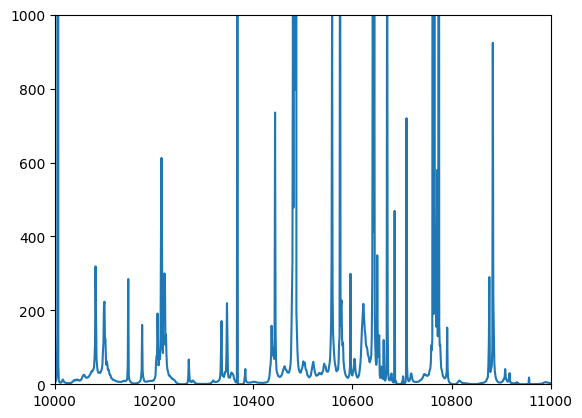

In [13]:
plt.plot(data[0]['curvature_radius'])
plt.xlim([10000,11000])
plt.ylim([0,1000])


Available blocks in session 0: {0: '1D_speed', 1: '2D_speed', 2: '0D_speed', 3: '1D_speed', 4: '1D_position', 5: '2D_position'}

Trial availability per block:
  block 0: 156 trials  (abs #0–#155)
  block 1: 156 trials  (abs #0–#155)
  block 2: 156 trials  (abs #0–#155)
  block 3: 156 trials  (abs #0–#155)
  block 4: 156 trials  (abs #0–#155)
  block 5: 156 trials  (abs #0–#155)

blocks_trials (relative indices) = {0: [0, 10], 1: [0, 10], 2: [0, 10]}

Block 0: using trials #0–#9  (idx 0–9)
Block 1: using trials #0–#9  (idx 0–9)
Block 2: using trials #0–#9  (idx 0–9)

 Block              Trials   Loaded    Samples     Bins   Area mm²   Coverage
──────────────────────────────────────────────────────────────────────────────
     0    #0–#9  (idx 0–9)       10    230,692    4,623     4623.0      93.3%
     1    #0–#9  (idx 0–9)       10    230,692    4,623     4623.0      93.3%
     2    #0–#9  (idx 0–9)       10    230,692    4,623     4623.0      93.3%
────────────────────────────────────

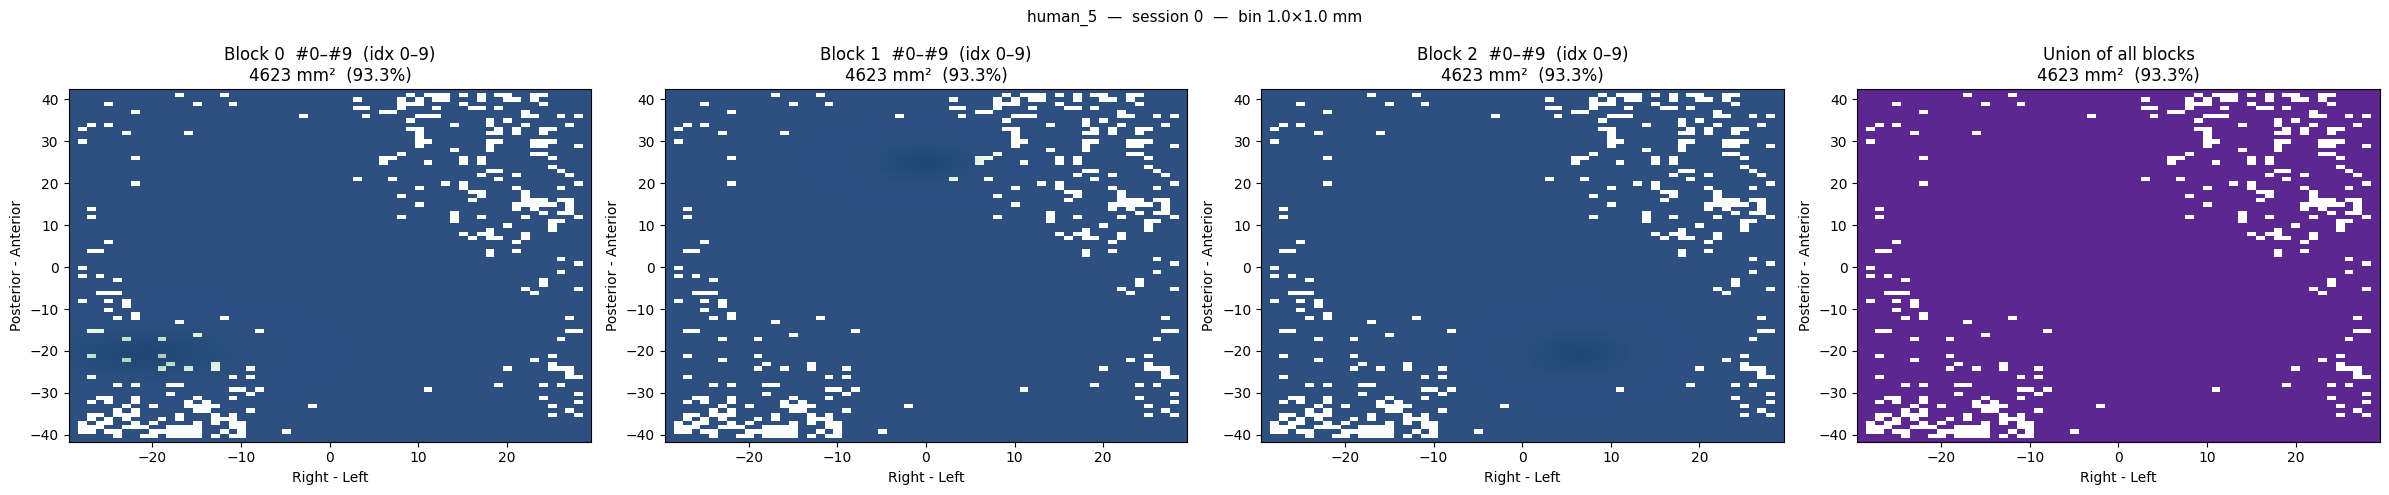

In [14]:

# ── AREA EXPLORED ─────────────────────────────────────────────────────────────
# Workspace is divided into bin_size × bin_size mm bins.
# Area explored = number of unique bins visited × bin_size² mm².
#
# Trial ranges are RELATIVE indices within each block:
#   [0, 10]  → first 10 trials of that block
#   [10, 20] → trials 10–19 of that block (by position, not absolute number)
#   None     → all trials in the block
# ── parameters ────────────────────────────────────────────────────────────────
subject_id_area = 'human_5'
session_area    = 0

blocks_trials = {
    0: [0, 10],
    1: [0, 10],
    2: [0, 10],
}
# Set blocks_trials = None to auto-use all blocks with all their trials.

bin_size_mm     = 1.0   # bin size in force units (mm)
workspace_range = None  # None → sensor range; or [-100, 100, -100, 100]

# ── discover available blocks ─────────────────────────────────────────────────
_avail_blocks, _avail_feedback = (
    experiment.Block() & {'subject_id': subject_id_area, 'session': session_area}
).fetch('block', 'feedback_type')

if len(_avail_blocks) == 0:
    print(f"No blocks found for {subject_id_area} session {session_area}.")
    for _s in (experiment.Session() & {'subject_id': subject_id_area}).fetch('session'):
        _bs = (experiment.Block() & {'subject_id': subject_id_area, 'session': _s}).fetch('block')
        print(f"  session {_s}: blocks {_bs}")
    raise StopIteration("Fix subject_id_area / session_area and re-run.")

print(f"Available blocks in session {session_area}: "
      f"{dict(zip(_avail_blocks.tolist(), _avail_feedback.tolist()))}")

# ── build trial map via TrialForceTrace (more reliable than BehaviorTrial join) ──
print("\nTrial availability per block:")
_block_trial_map = {}
for _b in _avail_blocks:
    _trs = np.sort(np.unique(
        (experiment.TrialForceTrace.TrialForceAxis() * experiment.Block() &
         {'subject_id': subject_id_area, 'session': session_area,
          'block': int(_b), 'force_axis_idx': 0}).fetch('trial')
    ))
    _block_trial_map[int(_b)] = _trs
    _lo = _trs[0] if len(_trs) else '—'
    _hi = _trs[-1] if len(_trs) else '—'
    print(f"  block {_b}: {len(_trs)} trials  (abs #{_lo}–#{_hi})")

# For any block in blocks_trials that's missing from the map, try a direct lookup
if blocks_trials is not None:
    for _b in list(blocks_trials.keys()):
        if int(_b) not in _block_trial_map:
            print(f"  block {_b}: not returned by experiment.Block() — trying direct TrialForceTrace lookup...")
            _trs_direct = np.sort(np.unique(
                (experiment.TrialForceTrace.TrialForceAxis() &
                 {'subject_id': subject_id_area, 'session': session_area,
                  'force_axis_idx': 0}).fetch('trial')
            ))
            _block_trial_map[int(_b)] = _trs_direct
            _lo = _trs_direct[0] if len(_trs_direct) else '—'
            _hi = _trs_direct[-1] if len(_trs_direct) else '—'
            print(f"    → found {len(_trs_direct)} trials (#{_lo}–#{_hi})  "
                  f"NOTE: block key unavailable; using all session trials as fallback")

# auto-fill if not specified
if blocks_trials is None:
    blocks_trials = {int(_b): None for _b in _avail_blocks}

print(f"\nblocks_trials (relative indices) = {blocks_trials}\n")

# ── shared workspace definition ───────────────────────────────────────────────
_first_block = list(blocks_trials.keys())[0]
_first_tsid  = (experiment.TaskSettings() * experiment.Block() &
                {'subject_id': subject_id_area, 'session': session_area,
                 'block': _first_block}).fetch1('task_setting_id')
_fa_rows_all = (experiment.TaskSettings.ForceAxis() &
                {'subject_id': subject_id_area, 'session': session_area}).fetch(as_dict=True)
_fad_global  = {r['force_axis_idx']: r
                for r in _fa_rows_all if r['task_setting_id'] == _first_tsid}

if workspace_range is not None:
    _x_min, _x_max, _y_min, _y_max = workspace_range
else:
    _x_min = _fad_global[0]['target_force_axes'][0]
    _x_max = _fad_global[0]['target_force_axes'][-1]
    _y_min = _fad_global[1]['target_force_axes'][0]
    _y_max = _fad_global[1]['target_force_axes'][-1]

_x_edges    = np.arange(_x_min, _x_max + bin_size_mm, bin_size_mm)
_y_edges    = np.arange(_y_min, _y_max + bin_size_mm, bin_size_mm)
_nx, _ny    = len(_x_edges) - 1, len(_y_edges) - 1
_total_bins = _nx * _ny
_dir0       = direction_dict[_fad_global[0]['force_direction']]
_dir1       = direction_dict[_fad_global[1]['force_direction']]
_ext        = [_x_edges[0], _x_edges[-1], _y_edges[0], _y_edges[-1]]

# ── process each block ────────────────────────────────────────────────────────
_results    = {}
_union_bins = set()

for _block, _t_range in blocks_trials.items():
    # resolve relative indices → absolute trial numbers
    _all_trials = _block_trial_map.get(int(_block), np.array([]))
    if len(_all_trials) == 0:
        print(f"Block {_block}: no trials found, skipping.")
        continue

    if _t_range is None:
        _trial_list = _all_trials.tolist()
        _trial_str  = f"{_all_trials[0]}–{_all_trials[-1]}"
    else:
        _i0, _i1    = int(_t_range[0]), int(_t_range[1])
        _selected   = _all_trials[_i0:_i1]
        if len(_selected) == 0:
            print(f"Block {_block}: range [{_i0},{_i1}) exceeds available "
                  f"{len(_all_trials)} trials — skipping.")
            continue
        _trial_list = _selected.tolist()
        _trial_str  = f"#{_selected[0]}–#{_selected[-1]}  (idx {_i0}–{_i1-1})"

    print(f"Block {_block}: using trials {_trial_str}")

    try:
        _tsid, _lut = (experiment.TaskSettings() * experiment.Block() &
                       {'subject_id': subject_id_area, 'session': session_area,
                        'block': _block}).fetch1('task_setting_id', 'target_force_lut')
    except Exception as _e:
        print(f"  could not fetch task settings — {_e}")
        continue

    _fad  = {r['force_axis_idx']: r
             for r in _fa_rows_all if r['task_setting_id'] == _tsid}

    # fetch force traces: try Block join first, fall back to trial-only join
    _f0_parts, _f1_parts = [], []
    for _tr in _trial_list:
        _key = {'subject_id': subject_id_area, 'session': session_area, 'trial': _tr}
        try:
            _q = (experiment.TrialForceTrace.TrialForceAxis() * experiment.Block() &
                  {**_key, 'block': _block})
            _f0_parts.append((_q & {'force_axis_idx': 0}).fetch1('force_trace_value'))
            _f1_parts.append((_q & {'force_axis_idx': 1}).fetch1('force_trace_value'))
        except Exception:
            try:
                _q2 = (experiment.TrialForceTrace.TrialForceAxis() * experiment.BehaviorTrial() & _key)
                _f0_parts.append((_q2 & {'force_axis_idx': 0}).fetch1('force_trace_value'))
                _f1_parts.append((_q2 & {'force_axis_idx': 1}).fetch1('force_trace_value'))
            except Exception:
                pass

    if len(_f0_parts) == 0:
        print(f"  no force traces found — skipping.")
        continue

    _f0 = np.concatenate(_f0_parts)
    _f1 = np.concatenate(_f1_parts)

    _xi = np.clip(np.digitize(_f0, _x_edges) - 1, 0, _nx - 1)
    _yi = np.clip(np.digitize(_f1, _y_edges) - 1, 0, _ny - 1)

    _visited = set(zip(_xi.tolist(), _yi.tolist()))
    _union_bins.update(_visited)

    _visit_map = np.zeros((_ny, _nx))
    for _xb, _yb in zip(_xi, _yi):
        _visit_map[_yb, _xb] += 1

    _results[_block] = dict(
        tsid=_tsid, lut=_lut, fad=_fad, visit_map=_visit_map,
        n_visited=len(_visited),
        area_mm2=len(_visited) * bin_size_mm**2,
        coverage_pct=100.0 * len(_visited) / _total_bins,
        n_trials=len(_f0_parts), n_samples=len(_f0),
        trial_str=_trial_str,
    )

# ── print summary ─────────────────────────────────────────────────────────────
print(f"\n{'Block':>6}  {'Trials':>18}  {'Loaded':>7}  {'Samples':>9}  "
      f"{'Bins':>7}  {'Area mm²':>9}  {'Coverage':>9}")
print("─" * 78)
for _b, _r in _results.items():
    print(f"{_b:>6}  {_r['trial_str']:>18}  {_r['n_trials']:>7}  {_r['n_samples']:>9,}  "
          f"{_r['n_visited']:>7,}  {_r['area_mm2']:>9.1f}  {_r['coverage_pct']:>8.1f}%")
_union_n    = len(_union_bins)
_union_area = _union_n * bin_size_mm**2
_union_cov  = 100.0 * _union_n / _total_bins
print("─" * 78)
print(f"{'UNION':>6}  {'':>18}  {'':>7}  {'':>9}  "
      f"{_union_n:>7,}  {_union_area:>9.1f}  {_union_cov:>8.1f}%")

# ── figure ─────────────────────────────────────────────────────────────────────
if len(_results) == 0:
    print("\nNo data to plot.")
else:
    _n_cols = len(_results) + 1
    fig, axes = plt.subplots(1, _n_cols, figsize=(6 * _n_cols, 5))
    if _n_cols == 1:
        axes = [axes]

    for _ax, (_b, _r) in zip(axes[:-1], _results.items()):
        _lut_norm = (_r['lut'] - _r['lut'].min()) / (_r['lut'].max() - _r['lut'].min() + 1e-9)
        _lut_ext  = [_r['fad'][0]['target_force_axes'][0], _r['fad'][0]['target_force_axes'][-1],
                     _r['fad'][1]['target_force_axes'][0], _r['fad'][1]['target_force_axes'][-1]]
        _ax.imshow(_lut_norm, extent=_lut_ext, origin='upper',
                   cmap='Greens', alpha=0.30, aspect='auto', zorder=0)
        _ax.imshow(np.ma.masked_where(_r['visit_map'] == 0, (_r['visit_map'] > 0).astype(float)),
                   extent=_ext, origin='lower', cmap='Blues',
                   alpha=0.85, aspect='auto', vmin=0, vmax=1, zorder=1)
        _ax.set_xlabel(_dir0);  _ax.set_ylabel(_dir1)
        _ax.set_title(f"Block {_b}  {_r['trial_str']}\n"
                      f"{_r['area_mm2']:.0f} mm²  ({_r['coverage_pct']:.1f}%)")

    _union_map = np.zeros((_ny, _nx))
    for _xb, _yb in _union_bins:
        _union_map[_yb, _xb] = 1
    axes[-1].imshow(np.ma.masked_where(_union_map == 0, _union_map),
                    extent=_ext, origin='lower', cmap='Purples',
                    alpha=0.85, aspect='auto', vmin=0, vmax=1)
    axes[-1].set_xlabel(_dir0);  axes[-1].set_ylabel(_dir1)
    axes[-1].set_title(f"Union of all blocks\n{_union_area:.0f} mm²  ({_union_cov:.1f}%)")

    fig.suptitle(f"{subject_id_area}  —  session {session_area}  —  bin {bin_size_mm}×{bin_size_mm} mm",
                 fontsize=11)
    plt.tight_layout()
    plt.show()


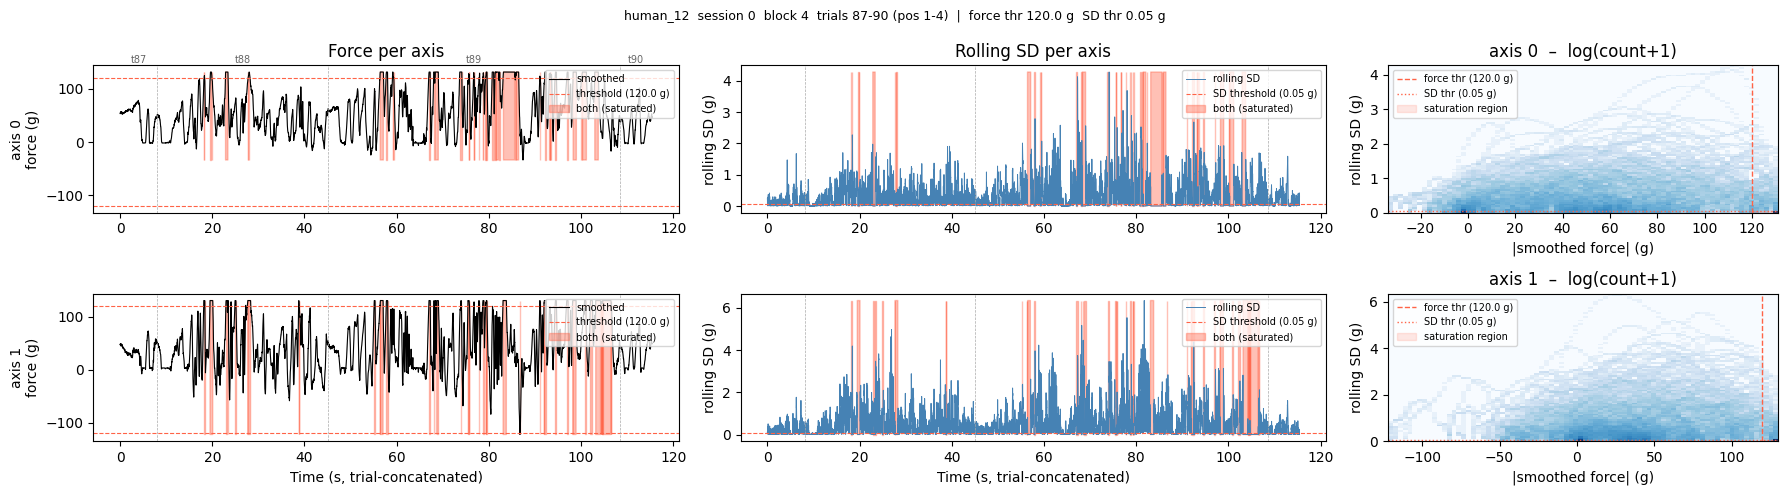

In [102]:
# ---- Saturation detection: per-axis view for one block ------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- parameters ----------------------------------------------------------
subject_id         = 'human_12'
session            = 0
block              = 4
trial_range        = [1,4]      # None = all trials in block;
                               # [first, last] as position within block (0-indexed)
smooth_window_time = 0.01       # (s)
sd_window_time     = 0.01      # (s)
force_threshold    = 120.0      # (g)  |force| per axis must exceed this
sd_threshold       = .05       # (g)  rolling SD must be below this

# ---- get trials in block -------------------------------------------------
all_trials = np.sort((
    experiment.BehaviorTrial
    & {'subject_id': subject_id, 'session': session, 'block': block}
).fetch('trial'))

if len(all_trials) == 0:
    print(f'No trials found for block {block}.')
    avail = (experiment.Block
             & {'subject_id': subject_id, 'session': session}).fetch('block').tolist()
    print(f'Available blocks: {avail}')
else:
    trials = all_trials if trial_range is None else all_trials[trial_range[0]: trial_range[1] + 1]

    if len(trials) == 0:
        print(f'trial_range {trial_range} is out of range '
              f'(block {block} has {len(all_trials)} trials).')
    else:
        # ---- concatenate force traces per axis across trials -----------------
        parts = {0: [], 1: []}
        t_parts, boundaries, loaded_trials = [], [0.0], []
        cursor = 0.0

        for trial in trials:
            key = {'subject_id': subject_id, 'session': session, 'trial': int(trial)}
            ftt = (experiment.TrialForceTrace & key).fetch1('force_trace_time')
            n   = len(ftt)
            if n == 0:
                print(f'  trial {trial}: empty force trace, skipping.')
                continue
            dt = float(np.median(np.diff(ftt)))
            for ax in (0, 1):
                raw = (experiment.TrialForceTrace.TrialForceAxis
                       & {**key, 'force_axis_idx': ax}).fetch1('force_trace_value')
                parts[ax].append(raw)
            t_parts.append(cursor + np.arange(n) * dt)
            cursor = t_parts[-1][-1] + dt
            boundaries.append(cursor)
            loaded_trials.append(trial)

        if len(t_parts) == 0:
            print('All trials in range had empty force traces.')
        else:
            raw_t         = np.concatenate(t_parts)
            axes_raw      = {ax: np.concatenate(parts[ax]) for ax in (0, 1)}
            dt            = float(np.median(np.diff(raw_t)))
            smooth_window = max(1, int(smooth_window_time / dt))
            sd_window     = max(2, int(sd_window_time     / dt))
            half_w        = smooth_window // 2

            # ---- detect per axis ---------------------------------------------
            results = {}
            for ax, raw in axes_raw.items():
                smoothed   = np.convolve(raw, np.ones(smooth_window) / smooth_window, mode='valid')
                sd         = pd.Series(smoothed).rolling(window=sd_window).std()
                crit_force = np.abs(smoothed) > force_threshold
                crit_sd    = (sd < sd_threshold).fillna(False).values
                saturated  = crit_force & crit_sd
                t_smooth = raw_t[half_w: half_w + len(smoothed)]
                if len(t_smooth) < len(smoothed):
                    t_smooth = raw_t[0] + np.arange(len(smoothed)) * dt
                results[ax] = dict(smoothed=smoothed, sd=sd.values,
                                   crit_force=crit_force, crit_sd=crit_sd,
                                   saturated=saturated, t=t_smooth)

            # ---- plot --------------------------------------------------------
            fig, axes_plot = plt.subplots(2, 3, figsize=(18, 5),
                                          gridspec_kw={'width_ratios': [3, 3, 2]})

            for row, ax in enumerate((0, 1)):
                r = results[ax]
                t         = r['t']
                smoothed  = r['smoothed']
                sd        = r['sd']
                saturated = r['saturated']
                sd_finite_max = float(np.nanmax(sd)) if np.any(np.isfinite(sd)) else 1.0

                # -- force subplot --
                af = axes_plot[row, 0]
                af.plot(raw_t, axes_raw[ax], color='#ccc', lw=0.4)
                af.plot(t, smoothed,          color='k',    lw=0.8, label='smoothed')
                af.axhline( force_threshold,  color='tomato', lw=0.8, ls='--',
                            label=f'threshold ({force_threshold} g)')
                af.axhline(-force_threshold,  color='tomato', lw=0.8, ls='--')
                # af.fill_between(t, smoothed.min(), smoothed.max(),
                #                 where=r['crit_force'], alpha=0.10, color='tomato',
                #                 label='force criterion')
                af.fill_between(t, smoothed.min(), smoothed.max(),
                                where=saturated, alpha=0.40, color='tomato',
                                label='both (saturated)')
                for tb in boundaries[1:-1]:
                    af.axvline(tb, color='#aaa', lw=0.5, ls='--')
                af.set_ylabel(f'axis {ax}\nforce (g)')
                af.legend(fontsize=7, loc='upper right')

                # -- SD subplot --
                asd = axes_plot[row, 1]
                asd.plot(t, sd, color='steelblue', lw=0.7, label='rolling SD')
                asd.axhline(sd_threshold, color='tomato', lw=0.8, ls='--',
                            label=f'SD threshold ({sd_threshold} g)')
                # asd.fill_between(t, 0, sd_finite_max,
                #                  where=r['crit_sd'], alpha=0.10, color='tomato',
                #                  label='SD criterion')
                asd.fill_between(t, 0, sd_finite_max,
                                 where=saturated, alpha=0.40, color='tomato',
                                 label='both (saturated)')
                for tb in boundaries[1:-1]:
                    asd.axvline(tb, color='#aaa', lw=0.5, ls='--')
                asd.set_ylabel('rolling SD (g)')
                asd.legend(fontsize=7, loc='upper right')

                # -- 2D histogram: |smoothed| vs SD --
                ah = axes_plot[row, 2]
                abs_smooth = np.abs(smoothed)
                sd_valid   = sd.copy()
                mask       = np.isfinite(sd_valid)
                h, xedges, yedges = np.histogram2d(
                    smoothed[mask], sd_valid[mask], bins=80)
                ah.pcolormesh(xedges, yedges, np.log1p(h).T,
                              cmap='Blues', shading='auto')
                ah.axvline(force_threshold, color='tomato', lw=1.0, ls='--',
                           label=f'force thr ({force_threshold} g)')
                ah.axhline(sd_threshold,    color='tomato', lw=1.0, ls=':',
                           label=f'SD thr ({sd_threshold} g)')
                # shade saturation quadrant
                ah.axvspan(force_threshold, xedges[-1],
                           ymin=0, ymax=sd_threshold / yedges[-1],
                           alpha=0.15, color='tomato', label='saturation region')
                ah.set_xlabel('|smoothed force| (g)')
                ah.set_ylabel('rolling SD (g)')
                ah.set_title(f'axis {ax}  –  log(count+1)')
                ah.legend(fontsize=7, loc='upper left')

            # trial labels on top-left subplot
            ylim = axes_plot[0, 0].get_ylim()
            for i, trial in enumerate(loaded_trials):
                t_mid = (boundaries[i] + boundaries[i + 1]) / 2
                axes_plot[0, 0].text(t_mid, ylim[1], f't{trial}',
                                     ha='center', va='bottom', fontsize=7, color='#666')

            tr_start = trial_range[0] if trial_range else 0
            tr_end   = trial_range[1] if trial_range else len(all_trials) - 1
            for col in (0, 1):
                axes_plot[-1, col].set_xlabel('Time (s, trial-concatenated)')
            axes_plot[0, 0].set_title('Force per axis')
            axes_plot[0, 1].set_title('Rolling SD per axis')
            fig.suptitle(
                f"{subject_id}  session {session}  block {block}  "
                f"trials {loaded_trials[0]}-{loaded_trials[-1]} (pos {tr_start}-{tr_end})  |  "
                f"force thr {force_threshold} g  SD thr {sd_threshold} g",
                fontsize=9
            )
            plt.tight_layout()
            plt.show()


In [ ]:
next_id = np.max(behavior_analysis.TouchDetectionParams().fetch('touch_param_id'))+1
behavior_analysis.TouchDetectionParams.insert1({'touch_param_id': next_id, 'smooth_window_time': 0.1, 'sd_window_time': 0.05,
         'sd_threshold': 0.05, 'force_threshold': 10.0})

DuplicateError: ("Duplicate entry '0' for key 'PRIMARY'", 'To ignore duplicate entries in insert, set skip_duplicates=True')

In [ ]:

#behavior_analysis.TrialSubmovements.populate(display_progress=True, suppress_errors=True)

0

In [4]:
subm_params

{'subm_param_id': 0,
 'smooth_window_time': 0.03,
 'curvature_half_window': 5,
 'min_submovement_duration': 0.05,
 'speed_prominence': 0.05,
 'cooccurrence_window_time': 0.05}

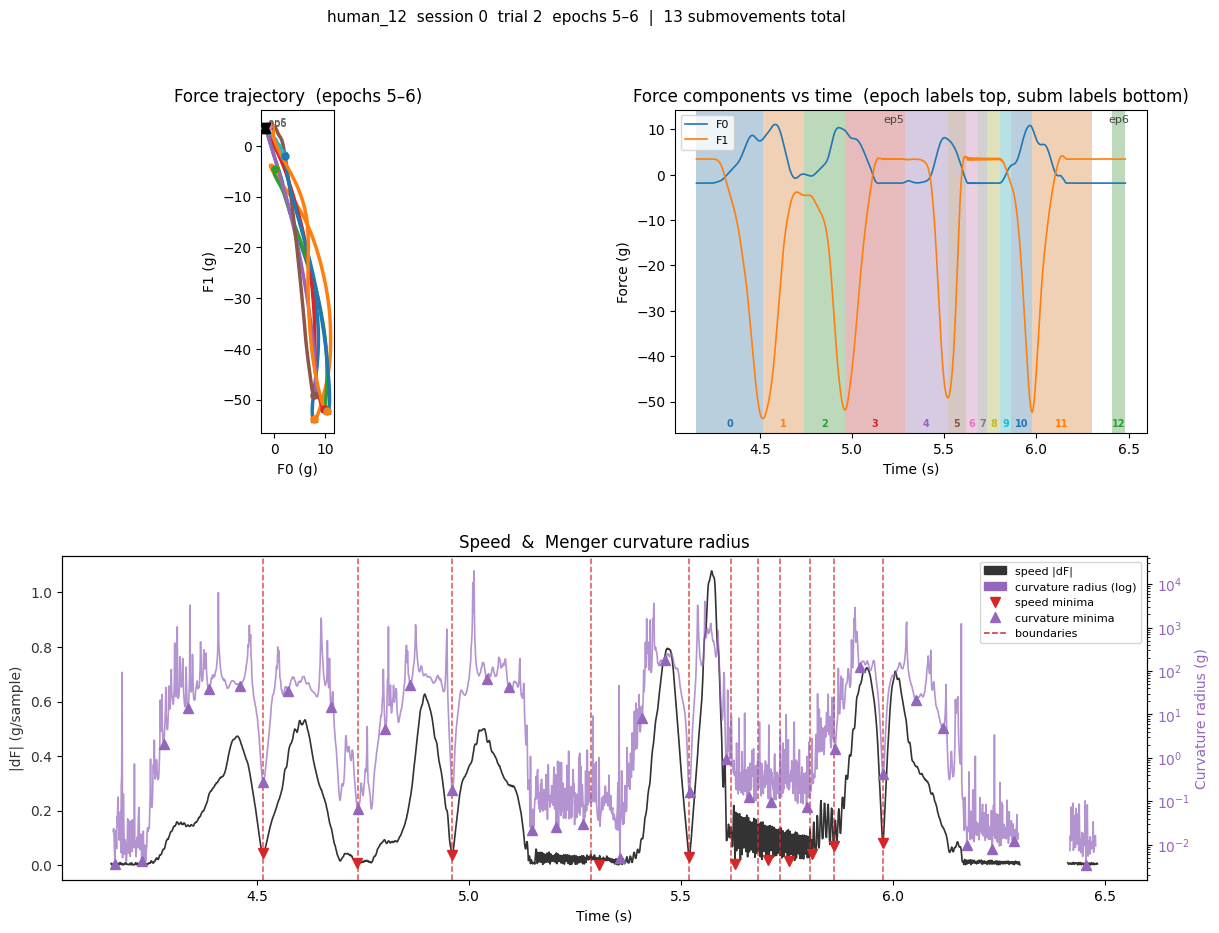

In [31]:
# ---- 2D force trajectory across multiple touch epochs, colored by submovement ----
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from scipy.signal import find_peaks

# ---- parameters --------------------------------------------------------
subject_id     = 'human_12'
session        = 0
trial          = 2
epoch_range    = [5,6]     # [first, last] is_touch=True epoch indices (inclusive)
touch_param_id = 0
sat_param_id   = 0
subm_param_id  = 0

# ---- fetch detection parameters ----------------------------------------
subm_params = (behavior_analysis.SubmovementDetectionParams
               & {'subm_param_id': subm_param_id}).fetch1()
smooth_window_time = subm_params['smooth_window_time']
curv_hw            = int(subm_params['curvature_half_window'])
min_subm_dur       = subm_params['min_submovement_duration']
speed_prom         = subm_params['speed_prominence']
cooc_time          = subm_params['cooccurrence_window_time']

key = {'subject_id': subject_id, 'session': session, 'trial': trial}

# ---- fetch & smooth full trial force trace once ------------------------
force_trace_time = (experiment.TrialForceTrace & key).fetch1('force_trace_time')
dt            = float(np.median(np.diff(force_trace_time)))
smooth_window = max(1, int(smooth_window_time / dt))
min_dist      = max(2, int(min_subm_dur / dt))
cooc_win      = max(1, int(cooc_time / dt))
half_w        = smooth_window // 2

axis_indices, axis_values = (
    experiment.TrialForceTrace.TrialForceAxis & key & 'force_axis_idx < 2'
).fetch('force_axis_idx', 'force_trace_value', order_by='force_axis_idx')

f_raw = {int(idx): val for idx, val in zip(axis_indices, axis_values)}
f_sm  = {ax: np.convolve(f_raw[ax], np.ones(smooth_window) / smooth_window, mode='valid')
         for ax in f_raw}
n  = min(len(v) for v in f_sm.values())
f0 = f_sm[0][:n]
f1 = f_sm[1][:n]
t  = force_trace_time[half_w: half_w + n]
if len(t) < n:
    t = force_trace_time[0] + np.arange(n) * dt

# ---- Menger curvature radius helper ------------------------------------
def menger_radius(x, y, hw=5):
    nr = len(x)
    r  = np.full(nr, np.inf)
    for i in range(hw, nr - hw):
        x1, y1 = x[i - hw], y[i - hw]
        x2, y2 = x[i],      y[i]
        x3, y3 = x[i + hw], y[i + hw]
        a    = np.hypot(x2 - x1, y2 - y1)
        b    = np.hypot(x3 - x2, y3 - y2)
        c    = np.hypot(x3 - x1, y3 - y1)
        area = abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1)) / 2
        if area > 1e-12:
            r[i] = (a * b * c) / (4 * area)
    return r

# ---- fetch stored submovements for the full trial ----------------------
subm_key = {**key, 'touch_param_id': touch_param_id,
            'sat_param_id': sat_param_id, 'subm_param_id': subm_param_id}
all_s_starts, all_s_ends = (
    behavior_analysis.TrialSubmovements.Submovement & subm_key
).fetch('start_time', 'end_time', order_by='submovement_idx')

# ---- build per-epoch data, assign global color indices -----------------
epochs_data = []
global_ci   = 0

for ei in range(epoch_range[0], epoch_range[1] + 1):
    touch_key_e = {**key, 'touch_param_id': touch_param_id,
                   'sat_param_id': sat_param_id, 'is_touch': True, 'epoch_idx': ei}
    rows = behavior_analysis.TrialTouchTimes.TouchEpoch & touch_key_e
    if len(rows) == 0:
        continue
    ep    = rows.fetch1()
    ep_t0 = float(ep['start_time'])
    ep_t1 = float(ep['end_time'])

    i0    = int(np.searchsorted(t, ep_t0))
    i1    = int(np.searchsorted(t, ep_t1))
    f0_ep = f0[i0:i1]
    f1_ep = f1[i0:i1]
    t_ep  = t[i0:i1]
    if len(t_ep) < 4:
        continue

    mag_ep   = np.sqrt(np.diff(f0_ep)**2 + np.diff(f1_ep)**2)
    t_mag_ep = t_ep[:-1]
    curv_ep  = menger_radius(f0_ep, f1_ep, hw=curv_hw)

    speed_mins, _ = find_peaks(-mag_ep,  distance=min_dist, prominence=speed_prom)
    curv_mins,  _ = find_peaks(-curv_ep, distance=min_dist)
    boundaries = set()
    for sm in speed_mins:
        for cm_ in curv_mins:
            if abs(int(sm) - int(cm_)) <= cooc_win:
                boundaries.add((int(sm) + int(cm_)) // 2)
                break
    boundaries = sorted(boundaries)

    in_epoch = [(float(s), float(e))
                for s, e in zip(all_s_starts, all_s_ends)
                if float(e) > ep_t0 and float(s) < ep_t1]
    cis = list(range(global_ci, global_ci + len(in_epoch)))
    global_ci += len(in_epoch)

    epochs_data.append({
        'ei': ei, 'ep_t0': ep_t0, 'ep_t1': ep_t1,
        'f0_ep': f0_ep, 'f1_ep': f1_ep, 't_ep': t_ep,
        'mag_ep': mag_ep, 't_mag_ep': t_mag_ep, 'curv_ep': curv_ep,
        'speed_mins': speed_mins, 'curv_mins': curv_mins,
        'boundaries': boundaries,
        'submovements': list(zip(in_epoch, cis)),
    })

n_total_subm = global_ci
colors = [cm.tab10(i % 10) for i in range(max(n_total_subm, 1))]

# ---- 3-panel figure (top 2 + wide bottom) ------------------------------
fig = plt.figure(figsize=(14, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.3)
ax  = fig.add_subplot(gs[0, 0])   # 2D trajectory
ax2 = fig.add_subplot(gs[0, 1])   # force time series
ax3 = fig.add_subplot(gs[1, :])   # speed (left)
ax4 = ax3.twinx()                 # curvature radius (right)

# Panel 1 — 2D trajectory: gray background per epoch, submovements in color
legend_handles = []
for ed in epochs_data:
    ax.plot(ed['f0_ep'], ed['f1_ep'], color='#cccccc', lw=1.5, zorder=1)
    ax.plot(ed['f0_ep'][0],  ed['f1_ep'][0],  'k^', ms=7, zorder=5)
    ax.plot(ed['f0_ep'][-1], ed['f1_ep'][-1], 'kv', ms=7, zorder=5)
    ax.text(ed['f0_ep'][0], ed['f1_ep'][0],
            f" ep{ed['ei']}", fontsize=7, color='#555', va='bottom')
    for (s_t, e_t), ci in ed['submovements']:
        j0 = int(np.searchsorted(ed['t_ep'], s_t))
        j1 = min(int(np.searchsorted(ed['t_ep'], e_t)) + 1, len(ed['f0_ep']))
        ax.plot(ed['f0_ep'][j0:j1], ed['f1_ep'][j0:j1],
                color=colors[ci], lw=2.5, zorder=3)
        ax.plot(ed['f0_ep'][j0],    ed['f1_ep'][j0],
                'o', color=colors[ci], ms=5, zorder=4)
        ax.plot(ed['f0_ep'][j1-1],  ed['f1_ep'][j1-1],
                's', color=colors[ci], ms=5, zorder=4)
        legend_handles.append(
            mpatches.Patch(color=colors[ci], label=f'subm {ci} (ep{ed["ei"]})')
        )
ax.set_xlabel('F0 (g)')
ax.set_ylabel('F1 (g)')
ax.set_title(f'Force trajectory  (epochs {epoch_range[0]}\u2013{epoch_range[1]})')
# ax.legend(handles=legend_handles, fontsize=6, loc='best',
#           ncol=max(1, n_total_subm // 6))
ax.set_aspect('equal')

# Panel 2 — F0, F1 time series spanning all epochs
t_lo = min(ed['ep_t0'] for ed in epochs_data)
t_hi = max(ed['ep_t1'] for ed in epochs_data)
i_lo = int(np.searchsorted(t, t_lo))
i_hi = int(np.searchsorted(t, t_hi))
ax2.plot(t[i_lo:i_hi], f0[i_lo:i_hi], color='tab:blue',   lw=1.2, label='F0')
ax2.plot(t[i_lo:i_hi], f1[i_lo:i_hi], color='tab:orange', lw=1.2, label='F1')
y_top = max(np.max(f0[i_lo:i_hi]), np.max(f1[i_lo:i_hi]))
y_bot = min(np.min(f0[i_lo:i_hi]), np.min(f1[i_lo:i_hi]))
for ed in epochs_data:
    ax2.axvspan(ed['ep_t0'], ed['ep_t1'], alpha=0.07, color='black', linewidth=0)
    ax2.text((ed['ep_t0'] + ed['ep_t1']) / 2, y_top,
             f"ep{ed['ei']}", ha='center', va='bottom', fontsize=8, color='#444')
    for (s_t, e_t), ci in ed['submovements']:
        ax2.axvspan(s_t, e_t, alpha=0.25, color=colors[ci], linewidth=0)
        ax2.text((s_t + e_t) / 2, y_bot, str(ci),
                 ha='center', va='top', fontsize=7,
                 color=colors[ci], fontweight='bold')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Force (g)')
ax2.set_title('Force components vs time  (epoch labels top, subm labels bottom)')
ax2.legend(fontsize=8)

# Panel 3 (bottom, full width) — speed (left) + curvature radius (right, twinx)
spd_color  = '#333333'
curv_color = 'tab:purple'

for ed in epochs_data:
    ax3.plot(ed['t_mag_ep'], ed['mag_ep'], color=spd_color, lw=1.2)
    ax3.plot(ed['t_mag_ep'][ed['speed_mins']], ed['mag_ep'][ed['speed_mins']],
             'v', color='tab:red', ms=7, zorder=4)
    finite = np.isfinite(ed['curv_ep'])
    ax4.plot(ed['t_ep'][finite], ed['curv_ep'][finite], color=curv_color, lw=1.2, alpha=0.7)
    valid_cm = ed['curv_mins'][np.isfinite(ed['curv_ep'][ed['curv_mins']])]
    ax4.plot(ed['t_ep'][valid_cm], ed['curv_ep'][valid_cm],
             '^', color=curv_color, ms=7, zorder=4)
    for b in ed['boundaries']:
        if b < len(ed['t_mag_ep']):
            ax3.axvline(ed['t_mag_ep'][b], color='tab:red',
                        lw=1.1, linestyle='--', alpha=0.8)

ax3.set_xlabel('Time (s)')
ax3.set_ylabel('|dF| (g/sample)', color=spd_color)
ax3.tick_params(axis='y', labelcolor=spd_color)
ax4.set_ylabel('Curvature radius (g)', color=curv_color)
ax4.tick_params(axis='y', labelcolor=curv_color)
ax4.set_yscale('log')

handles = [
    mpatches.Patch(color=spd_color,  label='speed |dF|'),
    mpatches.Patch(color=curv_color, label='curvature radius (log)'),
    plt.Line2D([0], [0], marker='v', color='tab:red', lw=0, ms=7, label='speed minima'),
    plt.Line2D([0], [0], marker='^', color=curv_color, lw=0, ms=7, label='curvature minima'),
    plt.Line2D([0], [0], color='tab:red', lw=1.1, linestyle='--', label='boundaries'),
]
ax3.legend(handles=handles, fontsize=8, loc='upper right')
ax3.set_title('Speed  &  Menger curvature radius')

fig.suptitle(
    f"{subject_id}  session {session}  trial {trial}  "
    f"epochs {epoch_range[0]}\u2013{epoch_range[1]}  |  "
    f"{n_total_subm} submovements total",
    fontsize=11
)
plt.show()


In [11]:
behavior_analysis.SubmovementDetectionParams().delete()

[2026-06-18 19:38:27,347][INFO]: Deleting 1 rows from `pipeline_behavior_analysis`.`#submovement_detection_params`
[2026-06-18 19:38:32,024][INFO]: Delete committed.


1

In [6]:
import matplotlib.cm as cm

cm

<module 'matplotlib.cm' from 'c:\\Scripts\\NDNF-pipeline\\.venv\\Lib\\site-packages\\matplotlib\\cm.py'>

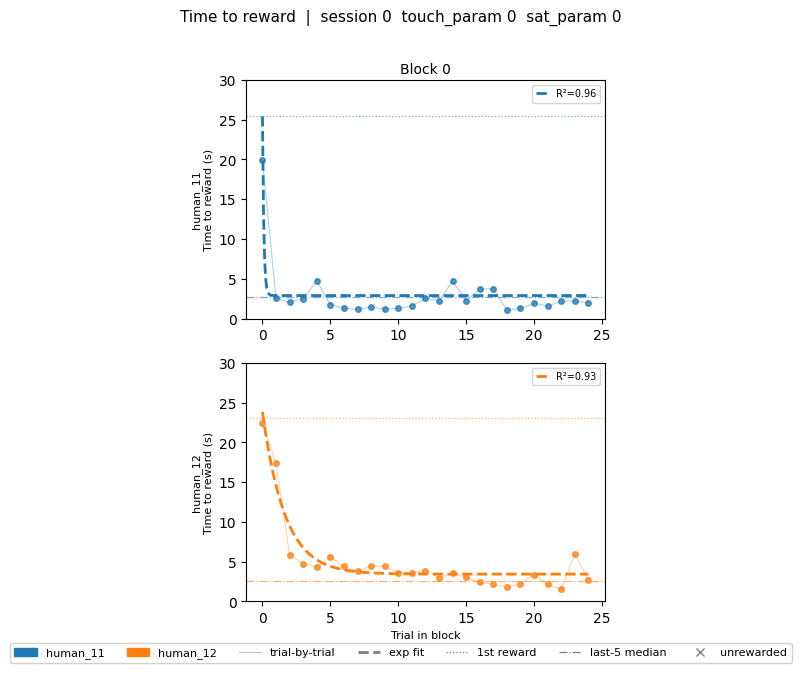

In [35]:
# ---- Time-to-reward learning curves: multi-participant x multi-block ----
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches

# ---- parameters --------------------------------------------------------
subject_ids    = ['human_11','human_12']   # participants to compare
session        = 0                          # int or dict {subject_id: session}
blocks         = [0]                 # block indices to show
touch_param_id = 0
sat_param_id   = 0
show_exp_fit   = True   # overlay BlockStatistics exponential fit
y_max          = 30   # (s) fix y-axis top; None = auto per row

# Layout: rows = participants, cols = blocks
# Reading left-to-right: progression through the session
# Reading top-to-bottom: same block across participants

def get_session(sid):
    return session if isinstance(session, int) else session[sid]

n_subj   = len(subject_ids)
n_blocks = len(blocks)
colors   = {sid: cm.tab10(i % 10) for i, sid in enumerate(subject_ids)}

fig, axes = plt.subplots(
    n_subj, n_blocks,
    figsize=(4.5 * n_blocks, 3.2 * n_subj),
    sharey='row', sharex=False,
    squeeze=False
)

for si, subject_id in enumerate(subject_ids):
    col  = colors[subject_id]
    sess = get_session(subject_id)

    for bi, block in enumerate(blocks):
        ax = axes[si, bi]

        block_key = {'subject_id': subject_id, 'session': sess, 'block': block}
        trial_key = {**block_key,
                     'touch_param_id': touch_param_id,
                     'sat_param_id':   sat_param_id}

        rows = behavior_analysis.TrialTiming * experiment.BehaviorTrial & trial_key
        if len(rows) == 0:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='#bbb', fontsize=9)
        else:
            trials, ttrs = rows.fetch(
                'trial', 'time_to_reward', order_by='trial')
            first_trial = int(trials.min())
            t_blk       = (trials - first_trial).astype(float)
            ttrs        = ttrs.astype(float)
            rewarded    = ~np.isnan(ttrs)

            # rewarded trials: dots + thin connecting line
            if rewarded.any():
                ax.plot(t_blk[rewarded], ttrs[rewarded],
                        'o', color=col, ms=4, alpha=0.75, zorder=3)
                ax.plot(t_blk[rewarded], ttrs[rewarded],
                        '-', color=col, lw=0.8, alpha=0.35, zorder=2)

            # unrewarded trials: tick marks at the top of the y range
            if (~rewarded).any() and rewarded.any():
                y_ceil = np.nanmax(ttrs[rewarded]) * 1.05
                ax.scatter(t_blk[~rewarded],
                           np.full((~rewarded).sum(), y_ceil),
                           marker='x', color=col, s=22, alpha=0.45,
                           zorder=2, label='unrewarded')

            # exponential fit
            if show_exp_fit:
                fit_rows = behavior_analysis.BlockStatistics.ExpFit & block_key
                if len(fit_rows):
                    fp    = fit_rows.fetch1()
                    t_fit = np.linspace(0, t_blk[rewarded].max(), 300)
                    y_fit = (fp['steady_state']
                             + (fp['first_trial_value'] - fp['steady_state'])
                             * np.exp(-t_fit / fp['time_constant']))
                    ax.plot(t_fit, y_fit, '--', color=col, lw=2.0,
                            label=f"R\u00b2={fp['r_squared']:.2f}")
                    ax.legend(fontsize=7, loc='upper right',
                              handlelength=1.2, borderpad=0.4)

            # block summary: first and last-5 median lines
            stats_rows = behavior_analysis.BlockStatistics & block_key
            if len(stats_rows):
                st = stats_rows.fetch1()
                ax.axhline(float(st['time_to_first_reward']),
                           color=col, lw=0.9, linestyle=':', alpha=0.6)
                if st['time_to_last_rewards'] is not None:
                    ax.axhline(float(st['time_to_last_rewards']),
                               color=col, lw=0.9, linestyle='-.', alpha=0.6)

        ax.set_ylim(bottom=0)
        if y_max is not None:
            ax.set_ylim(top=y_max)

        # titles and axis labels
        if si == 0:
            ax.set_title(f'Block {block}', fontsize=10, pad=5)
        if bi == 0:
            ax.set_ylabel(f'{subject_id}\nTime to reward (s)', fontsize=8)
        if si == n_subj - 1:
            ax.set_xlabel('Trial in block', fontsize=8)

# shared legend for line styles
style_handles = [
    plt.Line2D([0],[0], color='gray', lw=0.8, alpha=0.5, label='trial-by-trial'),
    plt.Line2D([0],[0], color='gray', lw=2.0, linestyle='--', label='exp fit'),
    plt.Line2D([0],[0], color='gray', lw=0.9, linestyle=':', label='1st reward'),
    plt.Line2D([0],[0], color='gray', lw=0.9, linestyle='-.', label='last-5 median'),
    plt.Line2D([0],[0], marker='x', color='gray', lw=0, ms=6, label='unrewarded'),
]
subj_handles = [
    mpatches.Patch(color=colors[sid], label=sid) for sid in subject_ids
]
fig.legend(handles=subj_handles + style_handles,
           loc='lower center', ncol=len(subject_ids) + len(style_handles),
           fontsize=8, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    f'Time to reward  |  session {session}  '
    f'touch_param {touch_param_id}  sat_param {sat_param_id}',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()


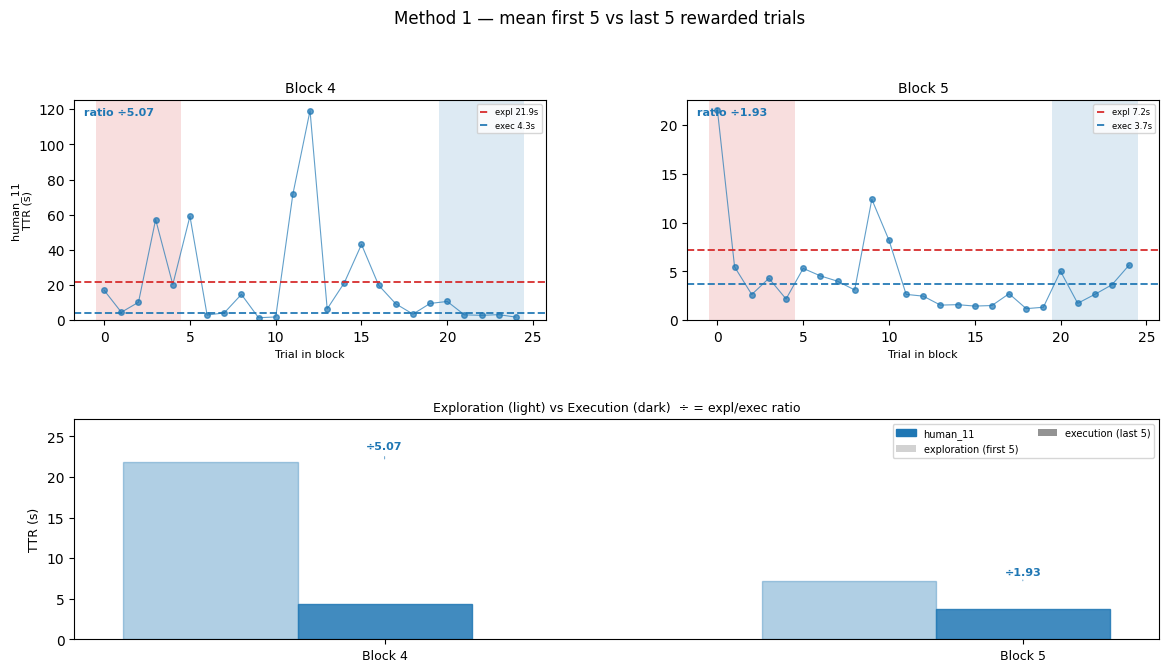

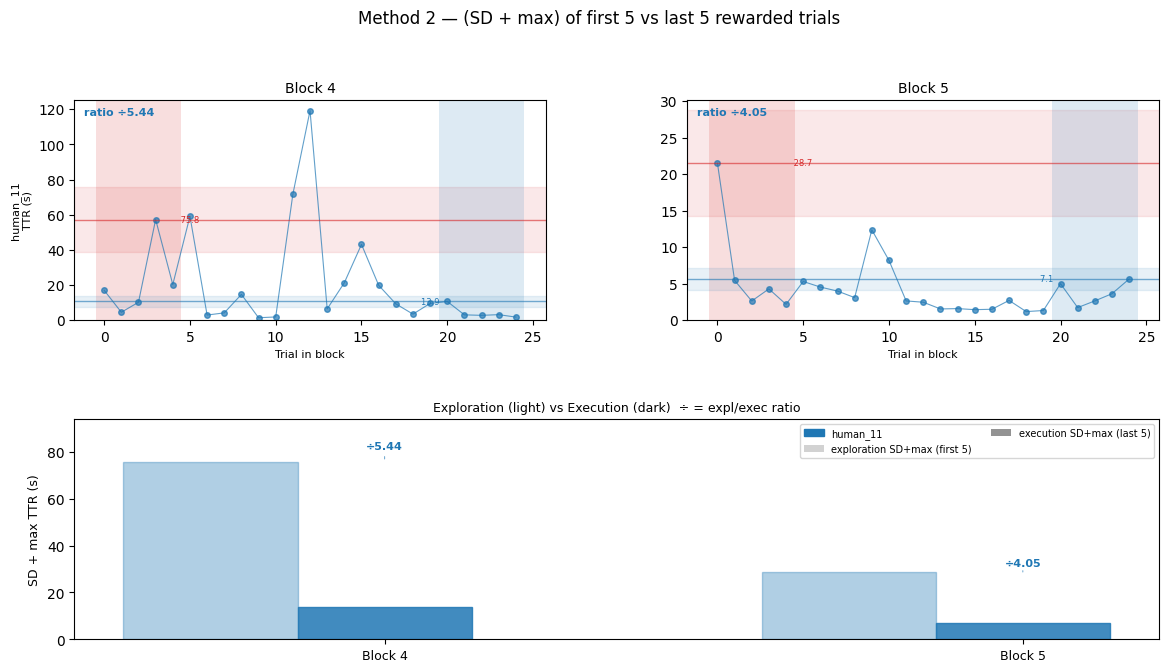

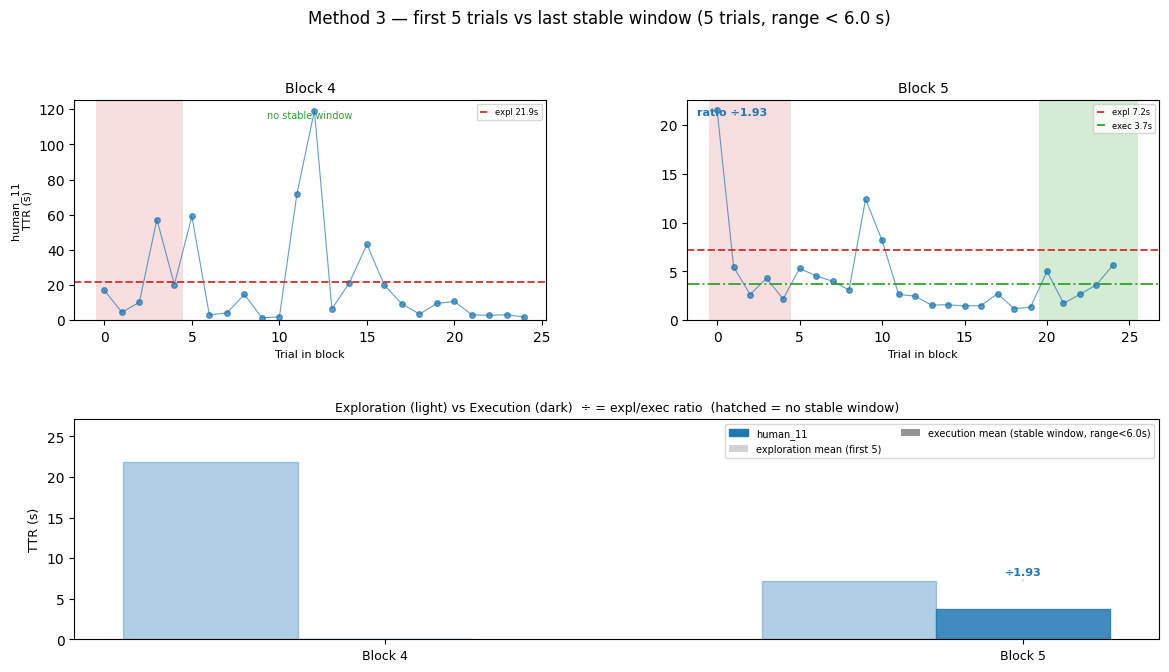


Summary (n_early=5, n_late=5, n_window=5, range_thr=6.0s)
              block  M1 ratio   M2 ratio   M3 ratio 
human_11      4           5.07       5.44    no window
human_11      5           1.93       4.05       1.93


In [2]:
# ---- Exploration vs Execution: 3 methods to split a block ----
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

# ---- parameters --------------------------------------------------------
subject_ids    = ['human_11'] #participants
session        = 0                          # int or dict {subj: session}
blocks         = [4,5]         # block indices
touch_param_id = 0
sat_param_id   = 0

n_early   = 5    # rewarded trials defining 'exploration' (all methods)
n_late    = 5    # rewarded trials defining 'execution' (methods 1 & 2)
n_window  = 5    # window size for stable-window search (method 3)
range_thr = 6.0  # (s) max TTR range within stable window (method 3)

def get_session(sid):
    return session if isinstance(session, int) else session[sid]

colors = {sid: cm.tab10(i % 10) for i, sid in enumerate(subject_ids)}

# ---- compute metrics ---------------------------------------------------
results = []
for subject_id in subject_ids:
    sess = get_session(subject_id)
    for block in blocks:
        trial_key = {'subject_id': subject_id, 'session': sess, 'block': block,
                     'touch_param_id': touch_param_id, 'sat_param_id': sat_param_id}
        rows = behavior_analysis.TrialTiming * experiment.BehaviorTrial & trial_key
        if len(rows) == 0:
            continue
        trials, ttrs = rows.fetch('trial', 'time_to_reward', order_by='trial')
        first_trial = int(trials.min())
        t_blk = (trials - first_trial).astype(float)
        ttrs  = ttrs.astype(float)
        rewarded = ~np.isnan(ttrs)
        if rewarded.sum() < max(n_early, n_late, n_window):
            continue
        ttrs_r  = ttrs[rewarded]
        t_blk_r = t_blk[rewarded]

        # Method 1: mean first-N vs mean last-N
        m1_expl = float(np.mean(ttrs_r[:n_early]))
        m1_exec = float(np.mean(ttrs_r[-n_late:]))

        # Method 2: (SD + max) first-N vs last-N  — variability + peak
        m2_expl = float(np.std(ttrs_r[:n_early])  + np.max(ttrs_r[:n_early]))
        m2_exec = float(np.std(ttrs_r[-n_late:]) + np.max(ttrs_r[-n_late:]))

        # Method 3: search backwards for last stable window
        m3_expl = float(np.mean(ttrs_r[:n_early]))
        m3_exec, stable_start_trial = None, None
        for i in range(len(ttrs_r) - n_window, -1, -1):
            window = ttrs_r[i:i + n_window]
            if np.ptp(window) < range_thr:
                m3_exec = float(np.mean(window))
                stable_start_trial = float(t_blk_r[i])
                break

        results.append({
            'subject_id': subject_id, 'block': block,
            'm1_expl': m1_expl, 'm1_exec': m1_exec,
            'm2_expl': m2_expl, 'm2_exec': m2_exec,
            'm3_expl': m3_expl, 'm3_exec': m3_exec,
            'stable_start_trial': stable_start_trial,
            'n_rewarded': int(rewarded.sum()),
            'ttrs_r': ttrs_r, 't_blk_r': t_blk_r,
        })

# ---- helper: bar chart with ratio annotations --------------------------
def draw_bar_row(ax, results, expl_key, exec_key, colors, subject_ids, blocks):
    bar_w = 0.3
    blk_gap = 0.5
    n_subj = len(subject_ids)
    subj_span = n_subj * 2 * bar_w + (n_subj - 1) * 0.05
    block_span = subj_span
    tick_pos, tick_labels = [], []
    for bi, block in enumerate(blocks):
        x_blk = bi * (block_span + blk_gap)
        for si, subject_id in enumerate(subject_ids):
            row = next((r for r in results
                        if r['subject_id'] == subject_id and r['block'] == block), None)
            if row is None:
                continue
            ev  = row[expl_key]
            xv  = row[exec_key]
            col = colors[subject_id]
            x0  = x_blk + si * (2 * bar_w + 0.05)
            ax.bar(x0,         ev if ev is not None else 0,
                   bar_w, color=col, alpha=0.35, edgecolor=col, linewidth=1.0)
            ax.bar(x0 + bar_w, xv if xv is not None else 0,
                   bar_w, color=col, alpha=0.85, edgecolor=col, linewidth=1.0,
                   hatch='//' if xv is None else '')
            # ratio annotation above the bar pair
            if ev is not None and xv is not None and xv > 0:
                ratio   = ev / xv
                y_top   = max(ev, xv)
                x_mid   = x0 + bar_w          # gap between the two bars
                ax.annotate(
                    f'\u00f7{ratio:.2f}',      # e.g. '÷2.14'
                    xy=(x_mid, y_top),
                    xytext=(x_mid, y_top * 1.06),
                    ha='center', va='bottom',
                    fontsize=8, color=col, fontweight='bold',
                    arrowprops=dict(arrowstyle='-', color=col,
                                   lw=0.8, alpha=0.6),
                )
        tick_pos.append(x_blk + block_span / 2)
        tick_labels.append(f'Block {block}')
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set_ylim(bottom=0)
    # leave headroom for the ratio labels
    yhi = ax.get_ylim()[1]
    ax.set_ylim(top=yhi * 1.18)

n_subj   = len(subject_ids)
n_blocks = len(blocks)
fw       = max(3.5 * n_blocks, 14)

# ========================================================================
# Figure 1 — Method 1: mean first-N vs mean last-N
# ========================================================================
fig1 = plt.figure(figsize=(fw, 3.5 * n_subj + 3.5))
gs1  = gridspec.GridSpec(n_subj + 1, n_blocks, figure=fig1,
                         hspace=0.45, wspace=0.3,
                         height_ratios=[3] * n_subj + [3])
for si, subject_id in enumerate(subject_ids):
    col = colors[subject_id]
    for bi, block in enumerate(blocks):
        ax = fig1.add_subplot(gs1[si, bi])
        row = next((r for r in results
                    if r['subject_id'] == subject_id and r['block'] == block), None)
        if row is None:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='#bbb')
        else:
            ax.plot(row['t_blk_r'], row['ttrs_r'], 'o-', color=col,
                    ms=4, lw=0.8, alpha=0.7)
            ax.axvspan(row['t_blk_r'][0] - 0.5, row['t_blk_r'][n_early - 1] + 0.5,
                       alpha=0.15, color='tab:red', linewidth=0)
            ax.axhline(row['m1_expl'], color='tab:red', lw=1.4,
                       linestyle='--', alpha=0.9, label=f"expl {row['m1_expl']:.1f}s")
            ax.axvspan(row['t_blk_r'][-n_late] - 0.5, row['t_blk_r'][-1] + 0.5,
                       alpha=0.15, color='tab:blue', linewidth=0)
            ax.axhline(row['m1_exec'], color='tab:blue', lw=1.4,
                       linestyle='--', alpha=0.9, label=f"exec {row['m1_exec']:.1f}s")
            ratio = row['m1_expl'] / row['m1_exec'] if row['m1_exec'] > 0 else float('inf')
            ax.text(0.02, 0.97, f'ratio \u00f7{ratio:.2f}',
                    transform=ax.transAxes, ha='left', va='top',
                    fontsize=8, color=col, fontweight='bold')
            ax.legend(fontsize=6, loc='upper right', handlelength=1)
        if si == 0:
            ax.set_title(f'Block {block}', fontsize=10)
        if bi == 0:
            ax.set_ylabel(f'{subject_id}\nTTR (s)', fontsize=8)
        if si == n_subj - 1:
            ax.set_xlabel('Trial in block', fontsize=8)
        ax.set_ylim(bottom=0)

ax_b1 = fig1.add_subplot(gs1[n_subj, :])
draw_bar_row(ax_b1, results, 'm1_expl', 'm1_exec', colors, subject_ids, blocks)
ax_b1.set_ylabel('TTR (s)', fontsize=9)
ax_b1.set_title(f'Exploration (light) vs Execution (dark)  \u00f7 = expl/exec ratio',
                fontsize=9)
subj_handles = [mpatches.Patch(color=colors[s], label=s) for s in subject_ids]
style_handles = [
    mpatches.Patch(facecolor='gray', alpha=0.35, label=f'exploration (first {n_early})'),
    mpatches.Patch(facecolor='gray', alpha=0.85, label=f'execution (last {n_late})'),
]
ax_b1.legend(handles=subj_handles + style_handles, fontsize=7,
             loc='upper right', ncol=2)
fig1.suptitle(f'Method 1 \u2014 mean first {n_early} vs last {n_late} rewarded trials',
              fontsize=12, y=1.01)
plt.show()

# ========================================================================
# Figure 2 — Method 2: (SD + max) first-N vs last-N
# ========================================================================
fig2 = plt.figure(figsize=(fw, 3.5 * n_subj + 3.5))
gs2  = gridspec.GridSpec(n_subj + 1, n_blocks, figure=fig2,
                         hspace=0.45, wspace=0.3,
                         height_ratios=[3] * n_subj + [3])
for si, subject_id in enumerate(subject_ids):
    col = colors[subject_id]
    for bi, block in enumerate(blocks):
        ax = fig2.add_subplot(gs2[si, bi])
        row = next((r for r in results
                    if r['subject_id'] == subject_id and r['block'] == block), None)
        if row is None:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='#bbb')
        else:
            ttrs_r  = row['ttrs_r']
            t_blk_r = row['t_blk_r']
            ax.plot(t_blk_r, ttrs_r, 'o-', color=col, ms=4, lw=0.8, alpha=0.7)
            ax.axvspan(t_blk_r[0] - 0.5, t_blk_r[n_early - 1] + 0.5,
                       alpha=0.15, color='tab:red', linewidth=0)
            early_max = float(np.max(ttrs_r[:n_early]))
            early_std = float(np.std(ttrs_r[:n_early]))
            ax.axhline(early_max, color='tab:red', lw=1.0, linestyle='-', alpha=0.6)
            ax.axhspan(early_max - early_std, early_max + early_std,
                       alpha=0.10, color='tab:red')
            ax.text(t_blk_r[n_early - 1] + 0.3, early_max,
                    f' {row["m2_expl"]:.1f}', fontsize=6, color='tab:red', va='center')
            ax.axvspan(t_blk_r[-n_late] - 0.5, t_blk_r[-1] + 0.5,
                       alpha=0.15, color='tab:blue', linewidth=0)
            late_max = float(np.max(ttrs_r[-n_late:]))
            late_std = float(np.std(ttrs_r[-n_late:]))
            ax.axhline(late_max, color='tab:blue', lw=1.0, linestyle='-', alpha=0.6)
            ax.axhspan(late_max - late_std, late_max + late_std,
                       alpha=0.10, color='tab:blue')
            ax.text(t_blk_r[-n_late] - 0.3, late_max,
                    f'{row["m2_exec"]:.1f} ', fontsize=6, color='tab:blue',
                    va='center', ha='right')
            ratio = row['m2_expl'] / row['m2_exec'] if row['m2_exec'] > 0 else float('inf')
            ax.text(0.02, 0.97, f'ratio \u00f7{ratio:.2f}',
                    transform=ax.transAxes, ha='left', va='top',
                    fontsize=8, color=col, fontweight='bold')
        if si == 0:
            ax.set_title(f'Block {block}', fontsize=10)
        if bi == 0:
            ax.set_ylabel(f'{subject_id}\nTTR (s)', fontsize=8)
        if si == n_subj - 1:
            ax.set_xlabel('Trial in block', fontsize=8)
        ax.set_ylim(bottom=0)

ax_b2 = fig2.add_subplot(gs2[n_subj, :])
draw_bar_row(ax_b2, results, 'm2_expl', 'm2_exec', colors, subject_ids, blocks)
ax_b2.set_ylabel('SD + max TTR (s)', fontsize=9)
ax_b2.set_title('Exploration (light) vs Execution (dark)  \u00f7 = expl/exec ratio',
                fontsize=9)
style_handles2 = [
    mpatches.Patch(facecolor='gray', alpha=0.35,
                   label=f'exploration SD+max (first {n_early})'),
    mpatches.Patch(facecolor='gray', alpha=0.85,
                   label=f'execution SD+max (last {n_late})'),
]
ax_b2.legend(handles=subj_handles + style_handles2, fontsize=7,
             loc='upper right', ncol=2)
fig2.suptitle(f'Method 2 \u2014 (SD + max) of first {n_early} vs last {n_late} rewarded trials',
              fontsize=12, y=1.01)
plt.show()

# ========================================================================
# Figure 3 — Method 3: first-N vs last stable window
# ========================================================================
fig3 = plt.figure(figsize=(fw, 3.5 * n_subj + 3.5))
gs3  = gridspec.GridSpec(n_subj + 1, n_blocks, figure=fig3,
                         hspace=0.45, wspace=0.3,
                         height_ratios=[3] * n_subj + [3])
for si, subject_id in enumerate(subject_ids):
    col = colors[subject_id]
    for bi, block in enumerate(blocks):
        ax = fig3.add_subplot(gs3[si, bi])
        row = next((r for r in results
                    if r['subject_id'] == subject_id and r['block'] == block), None)
        if row is None:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='#bbb')
        else:
            ax.plot(row['t_blk_r'], row['ttrs_r'], 'o-', color=col,
                    ms=4, lw=0.8, alpha=0.7)
            ax.axvspan(row['t_blk_r'][0] - 0.5, row['t_blk_r'][n_early - 1] + 0.5,
                       alpha=0.15, color='tab:red', linewidth=0)
            ax.axhline(row['m3_expl'], color='tab:red', lw=1.4,
                       linestyle='--', alpha=0.9, label=f"expl {row['m3_expl']:.1f}s")
            if row['stable_start_trial'] is not None:
                sw_end = row['stable_start_trial'] + n_window
                ax.axvspan(row['stable_start_trial'] - 0.5, sw_end + 0.5,
                           alpha=0.20, color='tab:green', linewidth=0)
                ax.axhline(row['m3_exec'], color='tab:green', lw=1.4,
                           linestyle='-.', alpha=0.9,
                           label=f"exec {row['m3_exec']:.1f}s")
                ratio = row['m3_expl'] / row['m3_exec'] if row['m3_exec'] > 0 else float('inf')
                ax.text(0.02, 0.97, f'ratio \u00f7{ratio:.2f}',
                        transform=ax.transAxes, ha='left', va='top',
                        fontsize=8, color=col, fontweight='bold')
            else:
                ax.text(0.5, 0.92, 'no stable window', ha='center',
                        transform=ax.transAxes, color='tab:green', fontsize=7)
            ax.legend(fontsize=6, loc='upper right', handlelength=1)
        if si == 0:
            ax.set_title(f'Block {block}', fontsize=10)
        if bi == 0:
            ax.set_ylabel(f'{subject_id}\nTTR (s)', fontsize=8)
        if si == n_subj - 1:
            ax.set_xlabel('Trial in block', fontsize=8)
        ax.set_ylim(bottom=0)

ax_b3 = fig3.add_subplot(gs3[n_subj, :])
draw_bar_row(ax_b3, results, 'm3_expl', 'm3_exec', colors, subject_ids, blocks)
ax_b3.set_ylabel('TTR (s)', fontsize=9)
ax_b3.set_title('Exploration (light) vs Execution (dark)  \u00f7 = expl/exec ratio  '
                '(hatched = no stable window)', fontsize=9)
style_handles3 = [
    mpatches.Patch(facecolor='gray', alpha=0.35,
                   label=f'exploration mean (first {n_early})'),
    mpatches.Patch(facecolor='gray', alpha=0.85,
                   label=f'execution mean (stable window, range<{range_thr}s)'),
]
ax_b3.legend(handles=subj_handles + style_handles3, fontsize=7,
             loc='upper right', ncol=2)
fig3.suptitle(
    f'Method 3 \u2014 first {n_early} trials vs last stable window '
    f'({n_window} trials, range < {range_thr} s)',
    fontsize=12, y=1.01
)
plt.show()

# ── console summary ──────────────────────────────────────────────────
print(f'\nSummary (n_early={n_early}, n_late={n_late}, n_window={n_window}, range_thr={range_thr}s)')
print(f'{"":12s}  {"block":5s}  {"M1 ratio":9s}  {"M2 ratio":9s}  {"M3 ratio":9s}')
for r in results:
    r1 = r['m1_expl']/r['m1_exec'] if r['m1_exec'] > 0 else float('nan')
    r2 = r['m2_expl']/r['m2_exec'] if r['m2_exec'] > 0 else float('nan')
    r3 = (r['m3_expl']/r['m3_exec'] if (r['m3_exec'] is not None and r['m3_exec'] > 0)
          else float('nan'))
    print(f"{r['subject_id']:12s}  {r['block']:<5d}  "
          f"{r1:>9.2f}  {r2:>9.2f}  "
          + (f"{r3:>9.2f}" if not np.isnan(r3) else '  no window'))


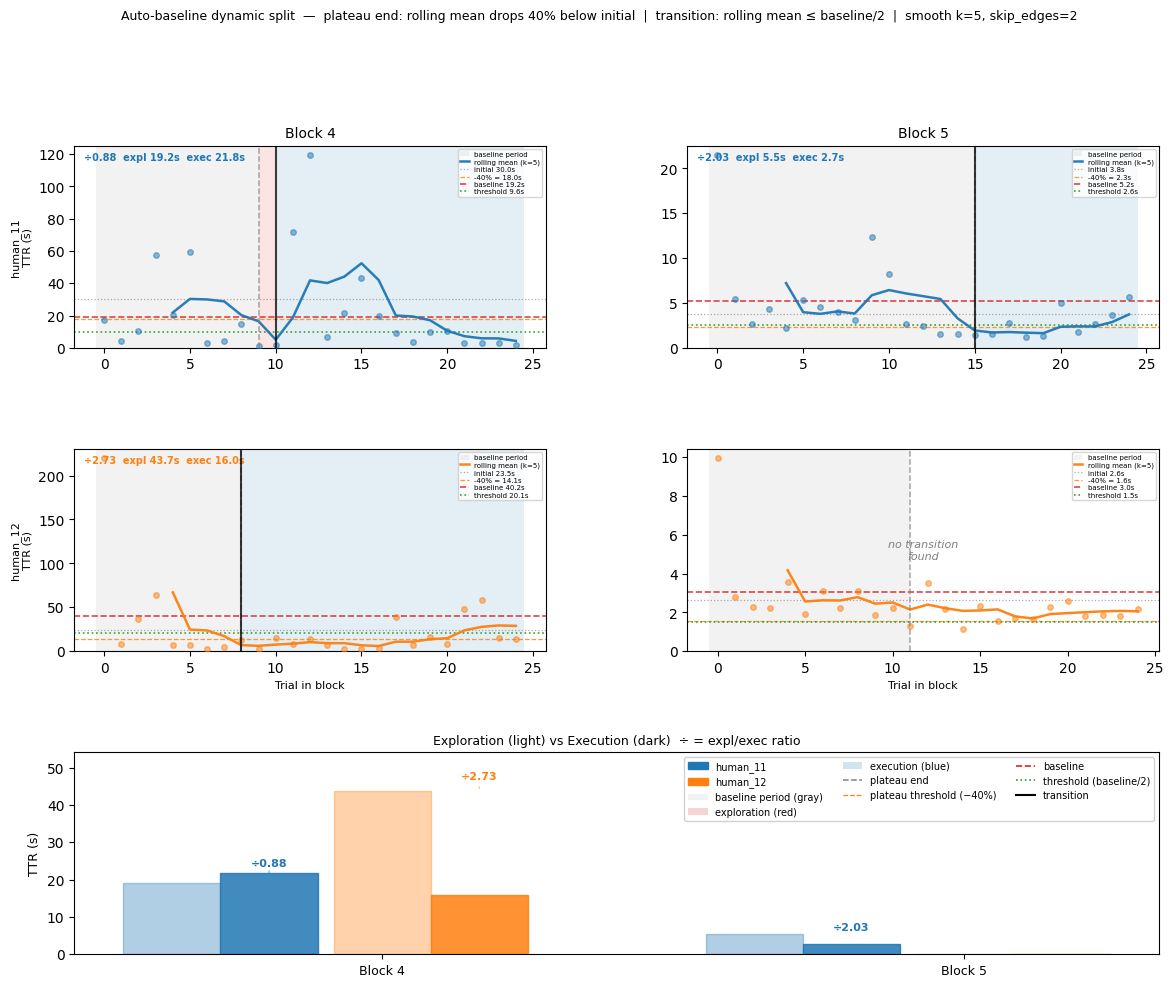


Auto-baseline summary  (smooth_k=5, drop_fraction=0.4)
              blk   initial  baseline   thresh   plat@  trans@    expl    exec   ratio
human_11        4     30.00     19.19     9.60       9      10   19.19   21.84    0.88
human_11        5      3.79      5.21     2.60      15      15    5.46    2.69    2.03
human_12        4     23.48     40.22    20.11       8       8   43.69   15.99    2.73
human_12        5      2.62      3.05     1.52      11     n/a     nan     n/a     n/a


In [ ]:
# ---- Dynamic exploration / execution split:
#      baseline auto-detected from initial rolling-mean plateau
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

# ---- parameters --------------------------------------------------------
subject_ids    = ['human_11','human_12']
session        = 0                   # int or dict {subj: session}
blocks         = [4,5]
touch_param_id = 0
sat_param_id   = 0

# smooth_k: box-car window applied to raw per-trial TTRs before any detection.
# Larger values suppress single-trial noise but lag behind real transitions.
smooth_k      = 3

# skip_edges: number of rolling-mean samples to exclude from the search at
# each end of the block. Needed because smooth_k >= 2 means the first/last
# windows are based on fewer raw trials and are more sensitive to outliers.
# Rule of thumb: skip_edges >= smooth_k - 1.
skip_edges    = 3

# drop_fraction: the rolling mean must fall this fraction below initial_level
# (sampled at skip_edges) for the plateau to be declared over. 0.20 = 20% drop.
# Larger values require a bigger signal before the plateau ends, reducing
# sensitivity to noise but potentially missing gradual learning curves.
drop_fraction = 0.20

def get_session(sid):
    return session if isinstance(session, int) else session[sid]

colors = {sid: cm.tab10(i % 10) for i, sid in enumerate(subject_ids)}

# ---- auto-baseline algorithm -------------------------------------------
#
#  1. Compute rolling mean of rewarded TTRs (window = smooth_k).
#  2. initial_level  = rolling mean at skip_edges (first stable point).
#  3. plateau_end    = first index where rolling mean < initial_level * (1 - drop_fraction).
#                      Fallback: first third of the smooth trace.
#  4. baseline       = mean of ALL raw trials whose rolling window ends before plateau_end.
#  5. threshold      = baseline / 2.
#  6. transition     = first index >= plateau_end where rolling mean <= threshold.
#

results = []
for subject_id in subject_ids:
    sess = get_session(subject_id)
    for block in blocks:
        trial_key = {'subject_id': subject_id, 'session': sess, 'block': block,
                     'touch_param_id': touch_param_id, 'sat_param_id': sat_param_id}

        # fetch all trials in block; time_to_reward is NaN for unrewarded trials
        rows = behavior_analysis.TrialTiming * experiment.BehaviorTrial & trial_key
        if len(rows) == 0:
            continue
        trials, ttrs = rows.fetch('trial', 'time_to_reward', order_by='trial')

        # re-index trial numbers to start at 0 within the block
        first_trial  = int(trials.min())
        t_blk        = (trials - first_trial).astype(float)
        ttrs         = ttrs.astype(float)

        # keep only rewarded trials — unrewarded don't contribute to TTR statistics
        rewarded     = ~np.isnan(ttrs)
        ttrs_r       = ttrs[rewarded]       # TTR values of rewarded trials
        t_blk_r      = t_blk[rewarded]      # their within-block trial indices

        # need enough rewarded trials for the algorithm to be valid:
        # 2*skip_edges (excluded at edges) + smooth_k (one full window) + 2 (minimum search range)
        min_len = 2 * skip_edges + smooth_k + 2
        if len(ttrs_r) < min_len:
            continue

        # step 1 — causal rolling mean: smooth[i] = mean(raw[i : i+smooth_k])
        # mode='valid' drops the edge windows that don't have smooth_k full trials,
        # giving length = len(ttrs_r) - smooth_k + 1.
        # t_smooth[i] is the trial index of the LAST raw trial in window i.
        kernel     = np.ones(smooth_k) / smooth_k
        ttr_smooth = np.convolve(ttrs_r, kernel, mode='valid')
        t_smooth   = t_blk_r[smooth_k - 1:]

        # step 2 — initial level: sampled at skip_edges to avoid the unstable
        # first windows. plateau_threshold is the level that must be crossed
        # downward to declare the plateau over.
        initial_level     = ttr_smooth[skip_edges]
        plateau_threshold = initial_level * (1.0 - drop_fraction)

        # step 3 — plateau end: first smooth index (within the search window)
        # where the rolling mean dips below plateau_threshold.
        # If no such drop is found (TTR never decreases enough), fall back to
        # the first third of the trace so the algorithm can still proceed.
        plateau_end_idx = None
        for i in range(skip_edges, len(ttr_smooth) - skip_edges):
            if ttr_smooth[i] < plateau_threshold:
                plateau_end_idx = i
                break
        if plateau_end_idx is None:
            plateau_end_idx = max(1, len(ttr_smooth) // 3)  # fallback: first third

        # step 4 — baseline: average TTR over the raw trials that fall inside
        # the plateau. Because smooth[i] = mean(raw[i : i+smooth_k]), all raw
        # trials up to index plateau_end_idx + smooth_k - 1 were part of the
        # plateau windows, so raw_baseline_end is that exclusive upper bound.
        raw_baseline_end  = plateau_end_idx + smooth_k   # exclusive
        baseline          = float(np.mean(ttrs_r[:raw_baseline_end]))
        plateau_end_trial = float(t_smooth[plateau_end_idx])  # in trial-index units

        # step 5 — threshold: exploration ends when TTR drops to half the baseline.
        # step 6 — transition: first smooth index at or after plateau_end where
        # the rolling mean crosses below threshold. Search ends skip_edges before
        # the end to avoid detecting a spurious dip on the last few trials.
        threshold = baseline / 2.0
        trans_idx = None
        for i in range(plateau_end_idx, len(ttr_smooth) - skip_edges):
            if ttr_smooth[i] <= threshold:
                trans_idx = i
                break

        # map smooth-trace transition index back to a raw trial index
        trans_trial = float(t_smooth[trans_idx]) if trans_idx is not None else None

        # split raw rewarded trials at the transition and compute phase means
        if trans_trial is not None:
            split     = int(np.searchsorted(t_blk_r, trans_trial))
            expl_mean = float(np.mean(ttrs_r[:split]))  if split > 0           else float('nan')
            exec_mean = float(np.mean(ttrs_r[split:]))  if split < len(ttrs_r)  else float('nan')
            ratio     = expl_mean / exec_mean if exec_mean > 0 else float('nan')
        else:
            split = expl_mean = exec_mean = ratio = float('nan')

        results.append({
            'subject_id': subject_id, 'block': block,
            'ttrs_r': ttrs_r, 't_blk_r': t_blk_r,
            'ttr_smooth': ttr_smooth, 't_smooth': t_smooth,
            'initial_level': initial_level,
            'plateau_threshold': plateau_threshold,
            'plateau_end_trial': plateau_end_trial,
            'raw_baseline_end': raw_baseline_end,
            'baseline': baseline, 'threshold': threshold,
            'trans_trial': trans_trial,
            'expl_mean': expl_mean, 'exec_mean': exec_mean, 'ratio': ratio,
            'n_rewarded': int(rewarded.sum()),
        })

# ---- figure ------------------------------------------------------------
n_subj   = len(subject_ids)
n_blocks = len(blocks)
fw       = max(3.5 * n_blocks, 14)

# rows = one per participant, cols = one per block, plus one summary row at the bottom
fig = plt.figure(figsize=(fw, 3.5 * n_subj + 3.5))
gs  = gridspec.GridSpec(n_subj + 1, n_blocks, figure=fig,
                        hspace=0.50, wspace=0.30,
                        height_ratios=[3] * n_subj + [3])

for si, subject_id in enumerate(subject_ids):
    col = colors[subject_id]
    for bi, block in enumerate(blocks):
        ax  = fig.add_subplot(gs[si, bi])
        row = next((r for r in results
                    if r['subject_id'] == subject_id and r['block'] == block), None)
        if row is None:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='#bbb')
        else:
            ttrs_r = row['ttrs_r'];  t_blk_r = row['t_blk_r']
            ttr_sm = row['ttr_smooth'];  t_sm = row['t_smooth']

            # shade the three phases:
            # gray  = baseline estimation period (before plateau_end)
            # red   = exploration (plateau_end to transition)
            # blue  = execution   (transition to end)
            ax.axvspan(t_blk_r[0] - 0.5, row['plateau_end_trial'],
                       alpha=0.10, color='gray', linewidth=0, label='baseline period')
            if row['trans_trial'] is not None:
                ax.axvspan(row['plateau_end_trial'], row['trans_trial'],
                           alpha=0.12, color='tab:red',  linewidth=0)
                ax.axvspan(row['trans_trial'], t_blk_r[-1] + 0.5,
                           alpha=0.12, color='tab:blue', linewidth=0)

            # individual trial TTRs (faded dots) and smoothed TTR (solid line)
            ax.plot(t_blk_r, ttrs_r, 'o', color=col, ms=4, alpha=0.50, zorder=3)
            ax.plot(t_sm, ttr_sm, '-', color=col, lw=1.8, alpha=0.95,
                    zorder=4, label=f'rolling mean (k={smooth_k})')

            # reference lines for the plateau-end detection:
            # gray dotted  = initial_level (rolling mean at skip_edges)
            # orange dashed = initial_level * (1 - drop_fraction) — the trigger level
            ax.axhline(row['initial_level'],    color='#888', lw=0.9,
                       linestyle=':', alpha=0.7, label=f'initial {row["initial_level"]:.1f}s')
            ax.axhline(row['plateau_threshold'], color='tab:orange', lw=0.9,
                       linestyle='--', alpha=0.8,
                       label=f'-{drop_fraction*100:.0f}% = {row["plateau_threshold"]:.1f}s')

            # gray dashed vertical = plateau_end trial (boundary of baseline period)
            ax.axvline(row['plateau_end_trial'], color='gray', lw=1.1,
                       linestyle='--', alpha=0.7, zorder=5)

            # red dashed  = auto-computed baseline (mean of gray-shaded trials)
            # green dotted = threshold = baseline / 2 (transition trigger level)
            ax.axhline(row['baseline'],  color='tab:red',   lw=1.2,
                       linestyle='--', alpha=0.85,
                       label=f'baseline {row["baseline"]:.1f}s')
            ax.axhline(row['threshold'], color='tab:green', lw=1.2,
                       linestyle=':',  alpha=0.95,
                       label=f'threshold {row["threshold"]:.1f}s')

            # black vertical = transition trial; top-left text shows ratio and phase means
            if row['trans_trial'] is not None:
                ax.axvline(row['trans_trial'], color='k', lw=1.5,
                           linestyle='-', alpha=0.75, zorder=6)
                ax.text(0.02, 0.97,
                        f'\u00f7{row["ratio"]:.2f}  '
                        f'expl {row["expl_mean"]:.1f}s  '
                        f'exec {row["exec_mean"]:.1f}s',
                        transform=ax.transAxes, ha='left', va='top',
                        fontsize=7, color=col, fontweight='bold')
            else:
                ax.text(0.50, 0.50, 'no transition\nfound',
                        transform=ax.transAxes, ha='center', va='center',
                        fontsize=8, color='gray', style='italic')

            ax.legend(fontsize=5, loc='upper right', handlelength=1.2,
                      borderpad=0.3, labelspacing=0.2)

        if si == 0:
            ax.set_title(f'Block {block}', fontsize=10)
        if bi == 0:
            ax.set_ylabel(f'{subject_id}\nTTR (s)', fontsize=8)
        if si == n_subj - 1:
            ax.set_xlabel('Trial in block', fontsize=8)
        ax.set_ylim(bottom=0)

# ── summary bar chart: mean TTR in each phase, one bar pair per (subject, block) ──
ax_bar = fig.add_subplot(gs[n_subj, :])
bar_w   = 0.3
blk_gap = 0.5   # horizontal gap between block groups
tick_pos, tick_labels = [], []

for bi, block in enumerate(blocks):
    # x_blk: left edge of this block's group of bar pairs
    x_blk = bi * (len(subject_ids) * (2 * bar_w + 0.05) + blk_gap)
    for si, subject_id in enumerate(subject_ids):
        row = next((r for r in results
                    if r['subject_id'] == subject_id and r['block'] == block), None)
        if row is None:
            continue
        col = colors[subject_id]
        x0  = x_blk + si * (2 * bar_w + 0.05)  # left edge of this subject's pair
        ev  = row['expl_mean']
        xv  = row['exec_mean']

        # light bar = exploration mean, dark bar = execution mean
        ax_bar.bar(x0,         ev if not np.isnan(ev) else 0,
                   bar_w, color=col, alpha=0.35, edgecolor=col, linewidth=1.0)
        ax_bar.bar(x0 + bar_w, xv if not np.isnan(xv) else 0,
                   bar_w, color=col, alpha=0.85, edgecolor=col, linewidth=1.0,
                   hatch='//' if np.isnan(xv) else '')  # hatched when no transition found

        # annotate with the exploration/execution ratio above the taller bar
        if not np.isnan(ev) and not np.isnan(xv) and xv > 0:
            y_top = max(ev, xv)
            ax_bar.annotate(
                f'\u00f7{row["ratio"]:.2f}',
                xy=(x0 + bar_w, y_top),
                xytext=(x0 + bar_w, y_top * 1.06),
                ha='center', va='bottom', fontsize=8,
                color=col, fontweight='bold',
                arrowprops=dict(arrowstyle='-', color=col, lw=0.8, alpha=0.6),
            )
    # place the block label at the center of its group
    tick_pos.append(x_blk + len(subject_ids) * (2 * bar_w + 0.05) / 2)
    tick_labels.append(f'Block {block}')

ax_bar.set_xticks(tick_pos)
ax_bar.set_xticklabels(tick_labels, fontsize=9)
ax_bar.set_ylabel('TTR (s)', fontsize=9)
ax_bar.set_ylim(bottom=0, top=ax_bar.get_ylim()[1] * 1.18)  # headroom for ratio labels
ax_bar.set_title('Exploration (light) vs Execution (dark)  \u00f7 = expl/exec ratio',
                 fontsize=9)
subj_handles  = [mpatches.Patch(color=colors[s], label=s) for s in subject_ids]
style_handles = [
    mpatches.Patch(facecolor='gray', alpha=0.10,  label='baseline period (gray)'),
    mpatches.Patch(facecolor='tab:red',  alpha=0.20, label='exploration (red)'),
    mpatches.Patch(facecolor='tab:blue', alpha=0.20, label='execution (blue)'),
    plt.Line2D([0],[0], color='gray',       lw=1.1, linestyle='--', label='plateau end'),
    plt.Line2D([0],[0], color='tab:orange', lw=0.9, linestyle='--',
               label=f'plateau threshold (\u2212{drop_fraction*100:.0f}%)'),
    plt.Line2D([0],[0], color='tab:red',    lw=1.2, linestyle='--', label='baseline'),
    plt.Line2D([0],[0], color='tab:green',  lw=1.2, linestyle=':',  label='threshold (baseline/2)'),
    plt.Line2D([0],[0], color='k',          lw=1.5, linestyle='-',  label='transition'),
]
ax_bar.legend(handles=subj_handles + style_handles,
              fontsize=7, loc='upper right', ncol=3, framealpha=0.9)

fig.suptitle(
    f'Auto-baseline dynamic split  \u2014  '
    f'plateau end: rolling mean drops {drop_fraction*100:.0f}% below initial  |  '
    f'transition: rolling mean \u2264 baseline/2  |  '
    f'smooth k={smooth_k}, skip_edges={skip_edges}',
    fontsize=9, y=1.01
)
plt.show()

# ── console summary table ─────────────────────────────────────────────────
print(f'\nAuto-baseline summary  (smooth_k={smooth_k}, drop_fraction={drop_fraction})')
print(f'{"":12s}  {"blk":>3}  {"initial":>8}  {"baseline":>8}  '
      f'{"thresh":>7}  {"plat@":>6}  {"trans@":>6}  '
      f'{"expl":>6}  {"exec":>6}  {"ratio":>6}')
for r in results:
    t_str = f'{r["trans_trial"]:>6.0f}' if r['trans_trial'] is not None else '   n/a'
    e_str = (f'{r["exec_mean"]:>6.2f}  {r["ratio"]:>6.2f}'
             if not np.isnan(r['exec_mean']) else '   n/a     n/a')
    print(f"{r['subject_id']:12s}  {r['block']:>3d}  "
          f"{r['initial_level']:>8.2f}  {r['baseline']:>8.2f}  "
          f"{r['threshold']:>7.2f}  "
          f"{r['plateau_end_trial']:>6.0f}  {t_str}  "
          f"{r['expl_mean']:>6.2f}  {e_str}")


human_11  1D_speed  blk 0  ONSET: trials 2->7  t=[23.7, 43.1] s
human_11  1D_speed  blk 0  section 2: trials 14->19  t=[62.1, 85.3] s
  max_dist=70.04 g  min_dist=0.13 g  threshold=70.04 g
human_11  2D_speed  blk 1  ONSET: trials 28->33  t=[50.6, 78.0] s
  max_dist=36.86 g  min_dist=0.64 g  threshold=36.86 g
human_11  1D_speed  blk 3  ONSET: trials 87->92  t=[56.6, 76.5] s
  max_dist=52.50 g  min_dist=0.84 g  threshold=52.50 g


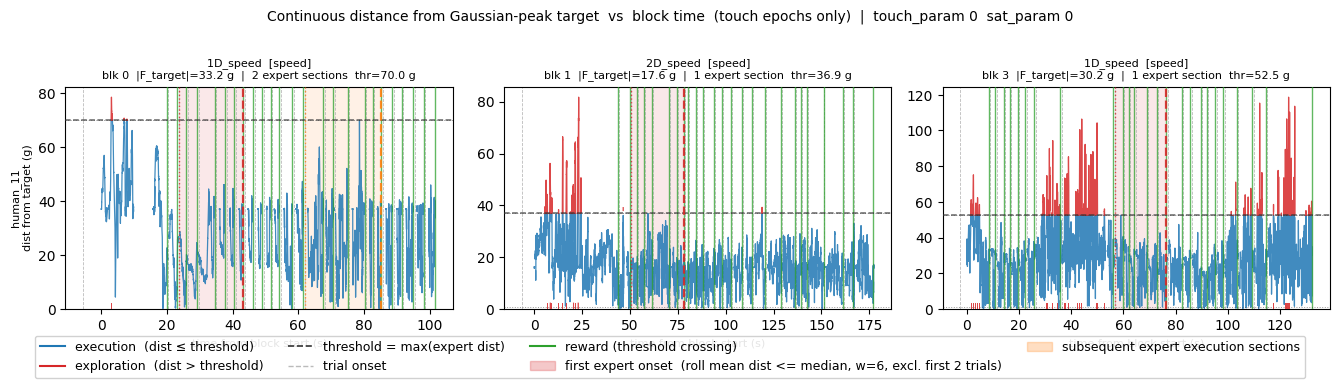

In [36]:
# ---- Distance from LUT target (continuous, touch epochs only) ----
# Expert onset sections: strict 6-trial rolling window where
#   rolling mean of distance-from-target <= global median of that series.
# First 2 trials of the block are always excluded from expert windows.
# First section -> red, subsequent -> orange.
# Threshold = max(dist inside expert sections):
#   dist > threshold  -> exploration  (red trace)
#   dist <= threshold -> execution    (blue trace)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

# ---- parameters --------------------------------------------------------
subject_ids    = ['human_11']
session        = 0
# select blocks by feedback type; None = all blocks
# types: '1D_speed', '1D_position', '2D_speed', '2D_position', '0D_position', '0D_speed'
feedback_types = ['1D_speed','2D_speed']
touch_param_id = 0
sat_param_id   = 0
expert_window  = 6   # rolling window over rewarded trials

def get_session(sid):
    return session if isinstance(session, int) else session[sid]

def lut_target(subject_id, sess, task_setting_id, fb_type):
    """Return (tgt_f0, tgt_f1, max_fmag, modality) from the Gaussian LUT peak.
    Speed LUT:    lut[i,j] = cursor speed; argmax = force producing max speed.
    Position LUT: lut[i,j] = cursor position; argmax = force at target position.
    """
    modality = 'position' if 'position' in fb_type else 'speed'
    task_key = {'subject_id': subject_id, 'session': sess,
                'task_setting_id': task_setting_id}
    lut = (experiment.TaskSettings & task_key).fetch1('target_force_lut')
    ax_idxs, ax_arrays = (
        experiment.TaskSettings.ForceAxis & task_key
    ).fetch('force_axis_idx', 'target_force_axes', order_by='force_axis_idx')
    fa = {int(i): v for i, v in zip(ax_idxs, ax_arrays)}
    peak_i, peak_j = np.unravel_index(np.nanargmax(lut), lut.shape)
    tgt_f0   = float(fa[0][peak_i])
    tgt_f1   = float(fa[1][peak_j])
    max_fmag = float(np.sqrt(tgt_f0**2 + tgt_f1**2))
    return tgt_f0, tgt_f1, max_fmag, modality

def rolling_mean(arr, w):
    """Rolling mean; NaN for the first w-1 positions (full window required)."""
    out = np.full(len(arr), np.nan)
    for i in range(w - 1, len(arr)):
        out[i] = arr[i - w + 1 : i + 1].mean()
    return out

def find_runs(bool_arr):
    """Return list of (start, end) index pairs for contiguous True runs."""
    runs, in_run, start = [], False, 0
    for i, v in enumerate(bool_arr):
        if v and not in_run:
            start, in_run = i, True
        elif not v and in_run:
            runs.append((start, i - 1))
            in_run = False
    if in_run:
        runs.append((start, len(bool_arr) - 1))
    return runs

# ---- collect data for each matching block ---
block_data = []

for subject_id in subject_ids:
    sess     = get_session(subject_id)
    base_key = {'subject_id': subject_id, 'session': sess}

    blk_query = experiment.Block & base_key
    if feedback_types is not None:
        blk_query = blk_query & [{'feedback_type': ft} for ft in feedback_types]
    block_nums, fb_types_arr, task_ids = blk_query.fetch(
        'block', 'feedback_type', 'task_setting_id', order_by='block'
    )

    if len(block_nums) == 0:
        print(f'{subject_id}: no blocks for feedback_types={feedback_types}')
        continue

    for block, fb_type, task_id in zip(block_nums.tolist(),
                                        fb_types_arr.tolist(),
                                        task_ids.tolist()):
        blk_key = {**base_key, 'block': block}
        det_key = {**blk_key,
                   'touch_param_id': touch_param_id,
                   'sat_param_id':   sat_param_id}

        trials = (experiment.BehaviorTrial & blk_key).fetch('trial', order_by='trial')
        if len(trials) == 0:
            continue

        try:
            tgt_f0, tgt_f1, max_fmag, modality = lut_target(
                subject_id, sess, task_id, fb_type
            )
        except Exception as e:
            print(f'{subject_id}  {fb_type} (blk {block}): {e}'); continue

        first_trial  = int(trials.min())
        timing_first = behavior_analysis.TrialTiming & {**det_key, 'trial': first_trial}
        if len(timing_first) == 0:
            print(f'{subject_id}  {fb_type} (blk {block}): TrialTiming missing'); continue
        block_start = float(timing_first.fetch1('first_touch_time'))

        dist_by_trial        = {}
        trial_start_blk      = {}
        reward_time_by_trial = {}
        t_cont_list          = []
        dist_cont_list       = []
        touch_spans          = []
        trial_bounds         = []

        for trial in trials:
            tint      = int(trial)
            exp_key   = {**blk_key, 'trial': tint}
            touch_key = {**exp_key,
                         'touch_param_id': touch_param_id,
                         'sat_param_id':   sat_param_id}

            st_rows = experiment.SessionTrial & exp_key
            if len(st_rows) == 0: continue
            offset = float(st_rows.fetch1('trial_start_time')) - block_start

            tc_rows = (experiment.TrialEvent & exp_key
                       & {'trial_event_type': 'threshold crossing'})
            if len(tc_rows) > 0:
                reward_time_by_trial[tint] = (
                    offset + float(tc_rows.fetch1('trial_event_time'))
                )

            ft_rows = experiment.TrialForceTrace & exp_key
            if len(ft_rows) == 0: continue
            ftt = ft_rows.fetch1('force_trace_time')
            if len(ftt) == 0: continue
            ax_idx, ax_val = (
                experiment.TrialForceTrace.TrialForceAxis & exp_key & 'force_axis_idx < 2'
            ).fetch('force_axis_idx', 'force_trace_value', order_by='force_axis_idx')
            if len(ax_val) < 2: continue
            f_raw = {int(i): v for i, v in zip(ax_idx, ax_val)}

            t_blk = offset + ftt
            trial_bounds.append(float(t_blk[0]))
            trial_start_blk[tint] = float(t_blk[0])

            ep_st, ep_en = (
                behavior_analysis.TrialTouchTimes.TouchEpoch & touch_key & {'is_touch': True}
            ).fetch('start_time', 'end_time')
            touch_mask = np.zeros(len(ftt), dtype=bool)
            for st, en in zip(ep_st, ep_en):
                touch_mask |= (ftt >= float(st)) & (ftt <= float(en))
                touch_spans.append((offset + float(st), offset + float(en)))

            if not touch_mask.any():
                continue

            dist_all        = np.sqrt((f_raw[0] - tgt_f0)**2 + (f_raw[1] - tgt_f1)**2)
            dist_touch_only = np.where(touch_mask, dist_all, np.nan)

            dist_by_trial[tint] = float(np.mean(dist_all[touch_mask]))

            if t_cont_list:
                t_cont_list.append(np.nan)
                dist_cont_list.append(np.nan)
            t_cont_list.extend(t_blk)
            dist_cont_list.extend(dist_touch_only)

        # ---- expert section detection (distance only) ------------------
        dist_arr = np.array([dist_by_trial.get(int(t), np.nan) for t in trials], dtype=float)

        # all trials with force data
        has_dist   = ~np.isnan(dist_arr)
        rew_trials = [int(t) for t, m in zip(trials, has_dist) if m]
        dist_rew   = dist_arr[has_dist]

        expert_sections = []

        if len(rew_trials) >= expert_window:
            roll_dist = rolling_mean(dist_rew, expert_window)
            med_dist  = np.nanmedian(roll_dist)

            is_low = (roll_dist <= med_dist) & ~np.isnan(roll_dist)
            # first 2 trials excluded: no window may contain trial index 0 or 1
            is_low[:2 + expert_window - 1] = False

            for run_s, run_e in find_runs(is_low):
                first_t = rew_trials[run_s - expert_window + 1]
                last_t  = rew_trials[run_s]   # strict 6-trial window
                t0 = trial_start_blk.get(first_t)
                t1 = reward_time_by_trial.get(
                    last_t, trial_start_blk.get(last_t)
                )
                if t0 is not None and t1 is not None and t1 > t0:
                    expert_sections.append((t0, t1, first_t, last_t))

        # ---- threshold from expert sections ----------------------------
        t_cont_arr    = np.array(t_cont_list,    dtype=float)
        dist_cont_arr = np.array(dist_cont_list, dtype=float)

        max_dist_expert = None
        min_dist_expert = None
        threshold       = None

        if expert_sections:
            expert_mask = np.zeros(len(t_cont_arr), dtype=bool)
            for (t0, t1, _, _) in expert_sections:
                expert_mask |= (t_cont_arr >= t0) & (t_cont_arr <= t1)
            valid = expert_mask & ~np.isnan(dist_cont_arr)
            if valid.any():
                max_dist_expert = float(np.nanmax(dist_cont_arr[valid]))
                min_dist_expert = float(np.nanmin(dist_cont_arr[valid]))
                threshold       = max_dist_expert

        if expert_sections:
            for k, (t0, t1, ft, lt) in enumerate(expert_sections):
                tag = 'ONSET' if k == 0 else f'section {k+1}'
                print(
                    f'{subject_id}  {fb_type}  blk {block}  '
                    f'{tag}: trials {ft}->{lt}  t=[{t0:.1f}, {t1:.1f}] s'
                )
            if threshold is not None:
                print(
                    f'  max_dist={max_dist_expert:.2f} g  '
                    f'min_dist={min_dist_expert:.2f} g  '
                    f'threshold={threshold:.2f} g'
                )

        block_data.append({
            'subject_id': subject_id, 'sess': sess,
            'block': block, 'fb_type': fb_type, 'modality': modality,
            'tgt_f0': tgt_f0, 'tgt_f1': tgt_f1, 'max_fmag': max_fmag,
            't_cont':      t_cont_arr,
            'dist_cont':   dist_cont_arr,
            'touch_spans': touch_spans,
            'trial_bounds': trial_bounds,
            'reward_times': sorted(reward_time_by_trial.values()),
            'expert_sections':   expert_sections,
            'max_dist_expert':   max_dist_expert,
            'min_dist_expert':   min_dist_expert,
            'threshold':         threshold,
            'n_trials': len(trials),
        })

if not block_data:
    print('No data to plot.')
else:
    from collections import defaultdict
    block_data_s = sorted(block_data, key=lambda r: (r['subject_id'], r['block']))
    by_subj = defaultdict(list)
    for r in block_data_s:
        by_subj[r['subject_id']].append(r)
    n_subj = len(subject_ids)
    n_cols = max(len(v) for v in by_subj.values())

    exec_col    = 'tab:blue'
    expl_col    = 'tab:red'
    onset_col   = 'tab:red'
    section_col = 'tab:orange'
    thr_col     = '#333333'

    fig, axes = plt.subplots(
        n_subj, n_cols,
        figsize=(max(4.5 * n_cols, 12), 3.5 * n_subj),
        squeeze=False
    )
    for si, subject_id in enumerate(subject_ids):
        for ci, row in enumerate(by_subj[subject_id]):
            ax = axes[si][ci]

            for tb in row['trial_bounds']:
                ax.axvline(tb, color='#bbbbbb', lw=0.6, linestyle='--', zorder=1)

            for rt in row['reward_times']:
                ax.axvline(rt, color='tab:green', lw=1.0,
                           linestyle='-', alpha=0.75, zorder=3)

            for k, (t0, t1, _ft, _lt) in enumerate(row['expert_sections']):
                col = onset_col if k == 0 else section_col
                ax.axvspan(t0, t1, color=col, alpha=0.10, zorder=0, lw=0)
                ax.axvline(t0, color=col, lw=1.0, linestyle=':', alpha=0.8, zorder=4)
                ax.axvline(t1, color=col, lw=1.6, linestyle='--', alpha=0.9, zorder=4)

            thr = row['threshold']
            tc  = row['t_cont']
            dc  = row['dist_cont']
            if thr is not None:
                dc_exec = np.where(dc <= thr, dc, np.nan)
                dc_expl = np.where(dc >  thr, dc, np.nan)
                ax.plot(tc, dc_exec, color=exec_col, lw=0.9, alpha=0.85, zorder=2)
                ax.plot(tc, dc_expl, color=expl_col, lw=0.9, alpha=0.85, zorder=2)
                ax.axhline(thr, color=thr_col, lw=1.1, linestyle='--',
                           alpha=0.75, zorder=3)
                ax.axhline(row['max_dist_expert'], color=thr_col, lw=0.7,
                           linestyle=':', alpha=0.5, zorder=3)
                ax.axhline(row['min_dist_expert'], color=thr_col, lw=0.7,
                           linestyle=':', alpha=0.5, zorder=3)
                # exploration strip: filled band at the base of the plot
                expl_mask = np.isfinite(dc) & (dc > thr)
                if expl_mask.any():
                    strip_h = np.nanmax(dc) * 0.03
                    ax.fill_between(tc, 0, strip_h, where=expl_mask,
                                    color=expl_col, alpha=0.85,
                                    zorder=6, linewidth=0)
            else:
                ax.plot(tc, dc, color=exec_col, lw=0.9, alpha=0.85, zorder=2)

            ax.set_ylim(bottom=0)
            ax.set_xlabel('time from block start (s)', fontsize=8)
            n_sec = len(row['expert_sections'])
            sec_lbl = (
                f"{n_sec} expert section{'s' if n_sec != 1 else ''}"
                if n_sec else 'no expert sections'
            )
            thr_lbl = (
                f"  thr={row['threshold']:.1f} g"
                if row['threshold'] is not None else ''
            )
            ax.set_title(
                f"{row['fb_type']}  [{row['modality']}]\n"
                f"blk {row['block']}  |F_target|={row['max_fmag']:.1f} g  "
                f"|  {sec_lbl}{thr_lbl}",
                fontsize=8
            )
            if ci == 0:
                ax.set_ylabel(f"{subject_id}\ndist from target (g)", fontsize=8)

        for ci in range(len(by_subj[subject_id]), n_cols):
            axes[si][ci].set_visible(False)

    h_exec    = mlines.Line2D([], [], color=exec_col, lw=1.5,
                               label='execution  (dist \u2264 threshold)')
    h_expl    = mlines.Line2D([], [], color=expl_col, lw=1.5,
                               label='exploration  (dist > threshold)')
    h_thr     = mlines.Line2D([], [], color=thr_col, lw=1.2, linestyle='--',
                               label='threshold = max(expert dist)')
    h_trial   = mlines.Line2D([], [], color='#bbbbbb', lw=1,
                               linestyle='--', label='trial onset')
    h_reward  = mlines.Line2D([], [], color='tab:green', lw=1.5,
                               label='reward (threshold crossing)')
    h_onset   = mpatches.Patch(color=onset_col,   alpha=0.25,
                                label=f'first expert onset  '
                                      f'(roll mean dist <= median, '
                                      f'w={expert_window}, excl. first 2 trials)')
    h_section = mpatches.Patch(color=section_col, alpha=0.25,
                                label='subsequent expert execution sections')
    fig.legend(
        handles=[h_exec, h_expl, h_thr, h_trial, h_reward, h_onset, h_section],
        loc='lower center', ncol=4, fontsize=9,
        bbox_to_anchor=(0.5, -0.06), framealpha=0.9
    )
    fig.suptitle(
        'Continuous distance from Gaussian-peak target  vs  block time  '
        '(touch epochs only)  |  '
        f'touch_param {touch_param_id}  sat_param {sat_param_id}',
        fontsize=10, y=1.01
    )
    plt.tight_layout()
    plt.show()


C:\Users\labadmin\AppData\Local\Temp\ipykernel_23408\1175640967.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


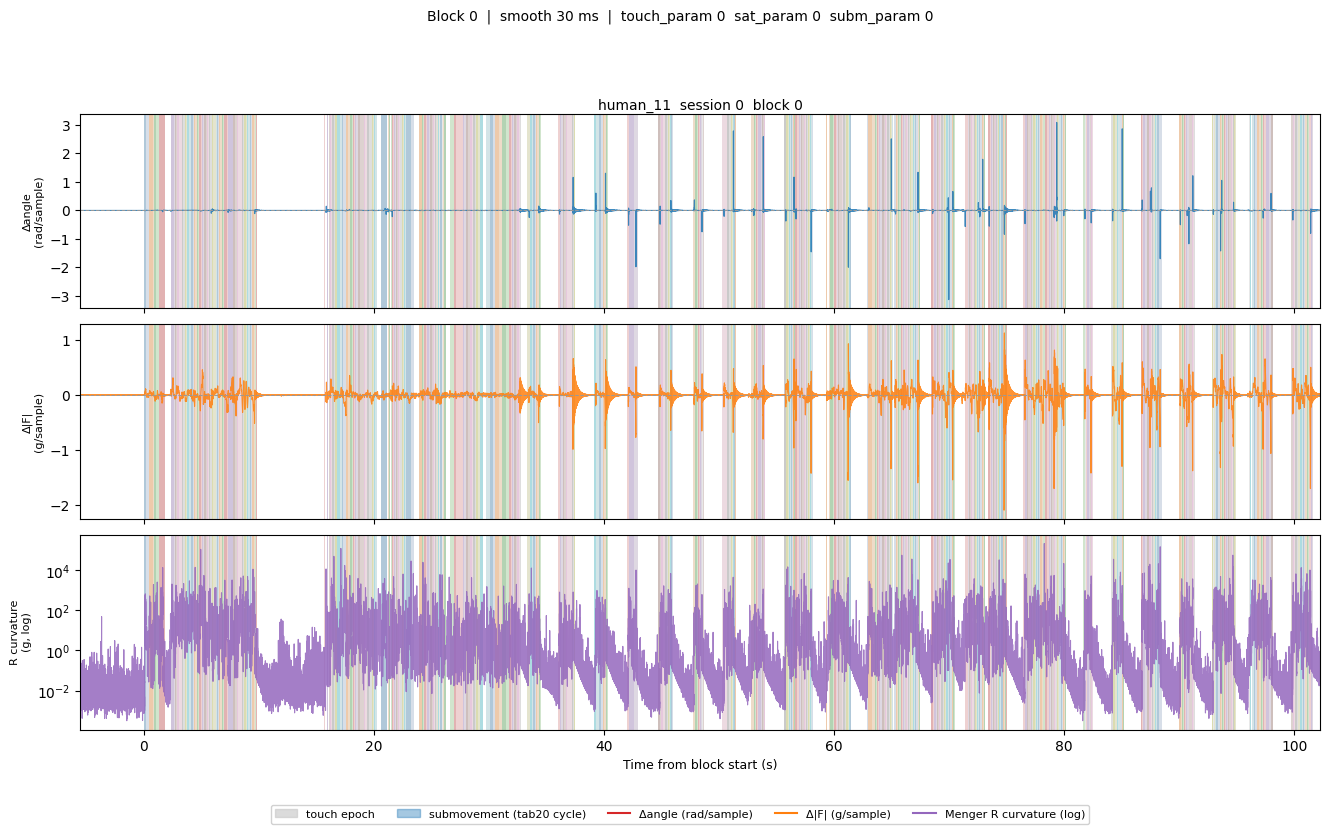

In [8]:
# ---- Block-level force derivatives + submovements ----
# Panels per participant: (1) angular velocity of force direction,
# (2) rate of change of force magnitude, (3) Menger curvature radius.
# X-axis = block-relative time; submovements colored, touch epochs shaded.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm_mod
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

# ---- parameters --------------------------------------------------------
subject_ids    = ['human_11']
session        = 0
block          = 0
touch_param_id = 0
sat_param_id   = 0
subm_param_id  = 0
# seconds from block start to display; None = full block
time_range     = None    # e.g. [0.0, 60.0]

# ---- Menger curvature radius (same helper used in TrialSubmovements) ---
def menger_radius(x, y, hw=5):
    nr = len(x); r = np.full(nr, np.inf)
    for i in range(hw, nr - hw):
        x1,y1 = x[i-hw],y[i-hw]; x2,y2 = x[i],y[i]; x3,y3 = x[i+hw],y[i+hw]
        a = np.hypot(x2-x1,y2-y1); b = np.hypot(x3-x2,y3-y2); c = np.hypot(x3-x1,y3-y1)
        area = abs((x2-x1)*(y3-y1)-(x3-x1)*(y2-y1))/2
        if area > 1e-12: r[i] = (a*b*c)/(4*area)
    return r

# ---- fetch smoothing params used during submovement detection ----------
subm_p             = (behavior_analysis.SubmovementDetectionParams
                      & {'subm_param_id': subm_param_id}).fetch1()
smooth_window_time = subm_p['smooth_window_time']
curv_hw            = int(subm_p['curvature_half_window'])

# ---- collect data per participant ------------------------------------
collected = {}   # subject_id -> arrays and span lists

for subject_id in subject_ids:
    sess     = session if isinstance(session, int) else session[subject_id]
    base_key = {'subject_id': subject_id, 'session': sess, 'block': block}
    det_key  = {**base_key, 'touch_param_id': touch_param_id, 'sat_param_id': sat_param_id}

    # fetch all trial numbers in this block, ordered
    trials = (experiment.BehaviorTrial & base_key).fetch('trial', order_by='trial')
    if len(trials) == 0:
        print(f'{subject_id}: no trials in block {block}, skipping'); continue

    # block_start: session-absolute time of the first touch in the block's first trial.
    # Computed from TrialTiming (avoids depending on BlockTiming being populated).
    first_trial = int(trials.min())
    timing_rows = behavior_analysis.TrialTiming & {**det_key, 'trial': first_trial}
    if len(timing_rows) == 0:
        print(f'{subject_id}: TrialTiming missing for trial {first_trial}, skipping'); continue
    block_start = float(timing_rows.fetch1('first_touch_time'))  # session-absolute

    # running lists concatenated across trials with NaN gap separators
    t_d_list, da_list, dm_list = [], [], []   # derivative-grid (length n-1 per trial)
    t_c_list, curv_list = [], []               # curvature-grid  (length n  per trial)
    subm_spans  = []   # (t0_blk, t1_blk, ci) for each detected submovement
    touch_spans = []   # (t0_blk, t1_blk) for each is_touch=True epoch

    for trial in trials:
        trial_int = int(trial)
        exp_key   = {**base_key, 'trial': trial_int}
        touch_key = {**exp_key,  'touch_param_id': touch_param_id, 'sat_param_id': sat_param_id}
        subm_key  = {**touch_key, 'subm_param_id': subm_param_id}

        # trial_start_time is session-absolute; subtract block_start for block-relative axis
        st_rows = experiment.SessionTrial & exp_key
        if len(st_rows) == 0: continue
        offset = float(st_rows.fetch1('trial_start_time')) - block_start

        # raw force trace times are trial-relative (seconds from trial start)
        ft_rows = experiment.TrialForceTrace & exp_key
        if len(ft_rows) == 0: continue
        ftt = ft_rows.fetch1('force_trace_time')
        if len(ftt) < 4: continue

        dt = float(np.median(np.diff(ftt)))
        sw = max(1, int(smooth_window_time / dt))   # smoothing window in samples
        hw = sw // 2

        # fetch force axes 0 and 1 (x and y in force space)
        ax_idx, ax_val = (
            experiment.TrialForceTrace.TrialForceAxis & exp_key & 'force_axis_idx < 2'
        ).fetch('force_axis_idx', 'force_trace_value', order_by='force_axis_idx')
        if len(ax_val) < 2: continue

        # box-car smooth; mode='valid' trims edge windows that lack sw full samples
        f_sm = {int(i): np.convolve(v, np.ones(sw)/sw, mode='valid')
                for i, v in zip(ax_idx, ax_val)}
        n    = min(len(v) for v in f_sm.values())
        f0, f1 = f_sm[0][:n], f_sm[1][:n]

        # time array for the smoothed trace, shifted to block-relative
        t_s = ftt[hw: hw+n]
        if len(t_s) < n:
            t_s = ftt[0] + np.arange(n)*dt
        t_blk = offset + t_s

        # angular velocity: unwrap first to avoid +-pi jumps at angle wrap-around
        da   = np.diff(np.unwrap(np.arctan2(f1, f0)))    # rad / sample
        # signed rate of change of force magnitude
        dm   = np.diff(np.sqrt(f0**2 + f1**2))           # g / sample
        # Menger radius of curvature in force space
        curv = menger_radius(f0, f1, hw=curv_hw)

        # da / dm live at midpoints between adjacent samples (length n-1)
        t_der = t_blk[:-1] + dt/2

        # NaN gap between consecutive trials so matplotlib breaks the plotted line
        if t_d_list:
            t_d_list.append(np.nan); da_list.append(np.nan); dm_list.append(np.nan)
        if t_c_list:
            t_c_list.append(np.nan); curv_list.append(np.nan)

        t_d_list.extend(t_der); da_list.extend(da); dm_list.extend(dm)
        t_c_list.extend(t_blk); curv_list.extend(curv)

        # submovement spans: start/end_time are trial-relative, shifted to block-relative
        if len(behavior_analysis.TrialSubmovements & subm_key) > 0:
            s_st, s_en, s_ix = (
                behavior_analysis.TrialSubmovements.Submovement & subm_key
            ).fetch('start_time', 'end_time', 'submovement_idx', order_by='submovement_idx')
            for st, en, ix in zip(s_st, s_en, s_ix):
                subm_spans.append((offset + float(st), offset + float(en), int(ix)))

        # touch epoch spans: trial-relative times shifted to block-relative
        ep_st, ep_en = (
            behavior_analysis.TrialTouchTimes.TouchEpoch & touch_key & {'is_touch': True}
        ).fetch('start_time', 'end_time')
        for st, en in zip(ep_st, ep_en):
            touch_spans.append((offset + float(st), offset + float(en)))

    if not t_d_list:
        print(f'{subject_id}: no force data found'); continue

    collected[subject_id] = {
        't_d':  np.array(t_d_list,  dtype=float),
        'da':   np.array(da_list,   dtype=float),
        'dm':   np.array(dm_list,   dtype=float),
        't_c':  np.array(t_c_list,  dtype=float),
        'curv': np.array(curv_list, dtype=float),
        'subm_spans':  subm_spans,
        'touch_spans': touch_spans,
        'sess': sess,
    }

# ---- figure ----------------------------------------------------------
if not collected:
    print('No data collected.')
else:
    n_s = len(collected)
    fig = plt.figure(figsize=(16, n_s * 7 + 1))
    outer = gridspec.GridSpec(n_s, 1, hspace=0.50, figure=fig)

    for si, (subject_id, d) in enumerate(collected.items()):
        # 3 stacked panels sharing x-axis within each participant
        inner = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=outer[si], hspace=0.08)
        ax0   = fig.add_subplot(inner[0])
        ax1   = fig.add_subplot(inner[1], sharex=ax0)
        ax2   = fig.add_subplot(inner[2], sharex=ax0)

        t_d = d['t_d']; da = d['da']; dm = d['dm']
        t_c = d['t_c']; curv = d['curv']

        # visible time window
        if time_range is not None:
            t_lo, t_hi = float(time_range[0]), float(time_range[1])
        else:
            fin = np.concatenate([t_d[np.isfinite(t_d)], t_c[np.isfinite(t_c)]])
            t_lo, t_hi = float(fin.min()), float(fin.max())

        # gray shading: touch epochs
        for t0, t1 in d['touch_spans']:
            if t1 < t_lo or t0 > t_hi: continue
            for ax in (ax0, ax1, ax2):
                ax.axvspan(max(t0, t_lo), min(t1, t_hi),
                           color='#cccccc', alpha=0.45, linewidth=0, zorder=0)

        # colored shading: submovement spans cycling through tab20
        for ci, (t0, t1, ix) in enumerate(d['subm_spans']):
            if t1 < t_lo or t0 > t_hi: continue
            col = cm_mod.tab20(ci % 20)
            for ax in (ax0, ax1, ax2):
                ax.axvspan(max(t0, t_lo), min(t1, t_hi),
                           color=col, alpha=0.28, linewidth=0, zorder=1)

        # panel 0: angular velocity of force direction
        ax0.plot(t_d, da, lw=0.8, color='tab:blue', alpha=0.85)
        ax0.axhline(0, color='#999', lw=0.7, linestyle='--')
        ax0.set_ylabel('\u0394angle\n(rad/sample)', fontsize=8)
        ax0.set_title(f"{subject_id}  session {d['sess']}  block {block}",
                      fontsize=10, pad=3)
        plt.setp(ax0.get_xticklabels(), visible=False)

        # panel 1: rate of change of force magnitude
        ax1.plot(t_d, dm, lw=0.8, color='tab:orange', alpha=0.85)
        ax1.axhline(0, color='#999', lw=0.7, linestyle='--')
        ax1.set_ylabel('\u0394|F|\n(g/sample)', fontsize=8)
        plt.setp(ax1.get_xticklabels(), visible=False)

        # panel 2: Menger radius of curvature (log; inf = straight segment)
        finite = np.isfinite(curv)
        ax2.plot(t_c[finite], curv[finite], lw=0.8, color='tab:purple', alpha=0.85)
        ax2.set_yscale('log')
        ax2.set_ylabel('R curvature\n(g, log)', fontsize=8)
        ax2.set_xlabel('Time from block start (s)', fontsize=9)

        ax0.set_xlim(t_lo, t_hi)

    legend_handles = [
        mpatches.Patch(color='#cccccc', alpha=0.7, label='touch epoch'),
        mpatches.Patch(color=cm_mod.tab20(0), alpha=0.4, label='submovement (tab20 cycle)'),
        plt.Line2D([0],[0], color='tab:red',   lw=1.5, label='\u0394angle (rad/sample)'),
        plt.Line2D([0],[0], color='tab:orange', lw=1.5, label='\u0394|F| (g/sample)'),
        plt.Line2D([0],[0], color='tab:purple', lw=1.5, label='Menger R curvature (log)'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=5, fontsize=8,
               bbox_to_anchor=(0.5, -0.015), framealpha=0.9)
    fig.suptitle(
        f'Block {block}  |  smooth {smooth_window_time*1000:.0f} ms  |  '
        f'touch_param {touch_param_id}  sat_param {sat_param_id}  subm_param {subm_param_id}',
        fontsize=10, y=1.01
    )
    plt.tight_layout()
    plt.show()


  skip  human_2  1D_speed  blk 3: 2 trials (< 10)
  skip  human_2  1D_speed  blk 4: 9 trials (< 10)
  skip  human_3  1D_speed  blk 3: 6 trials (< 10)
  skip  human_6  1D_position  blk 4: 2 trials (< 10)
  skip  human_7  0D_speed  blk 2: 5 trials (< 10)
  skip  human_12  0D_speed  blk 2: 8 trials (< 10)


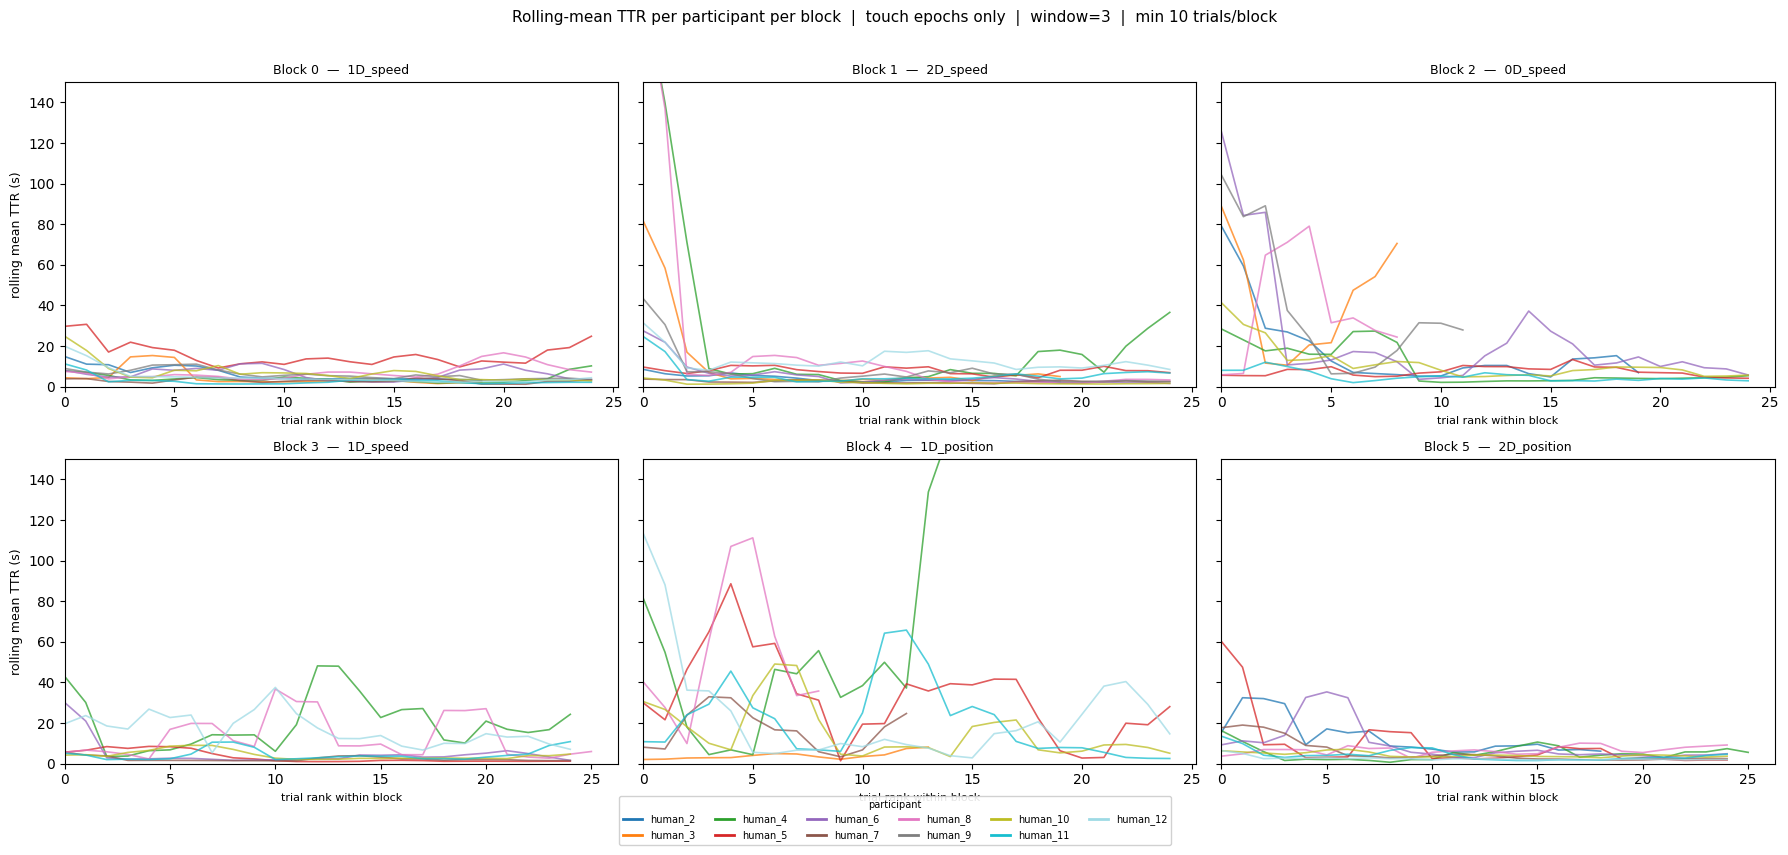

C:\Users\labadmin\AppData\Local\Temp\ipykernel_3280\1142602095.py:195: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(mat, axis=0)
c:\Scripts\NDNF-pipeline\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


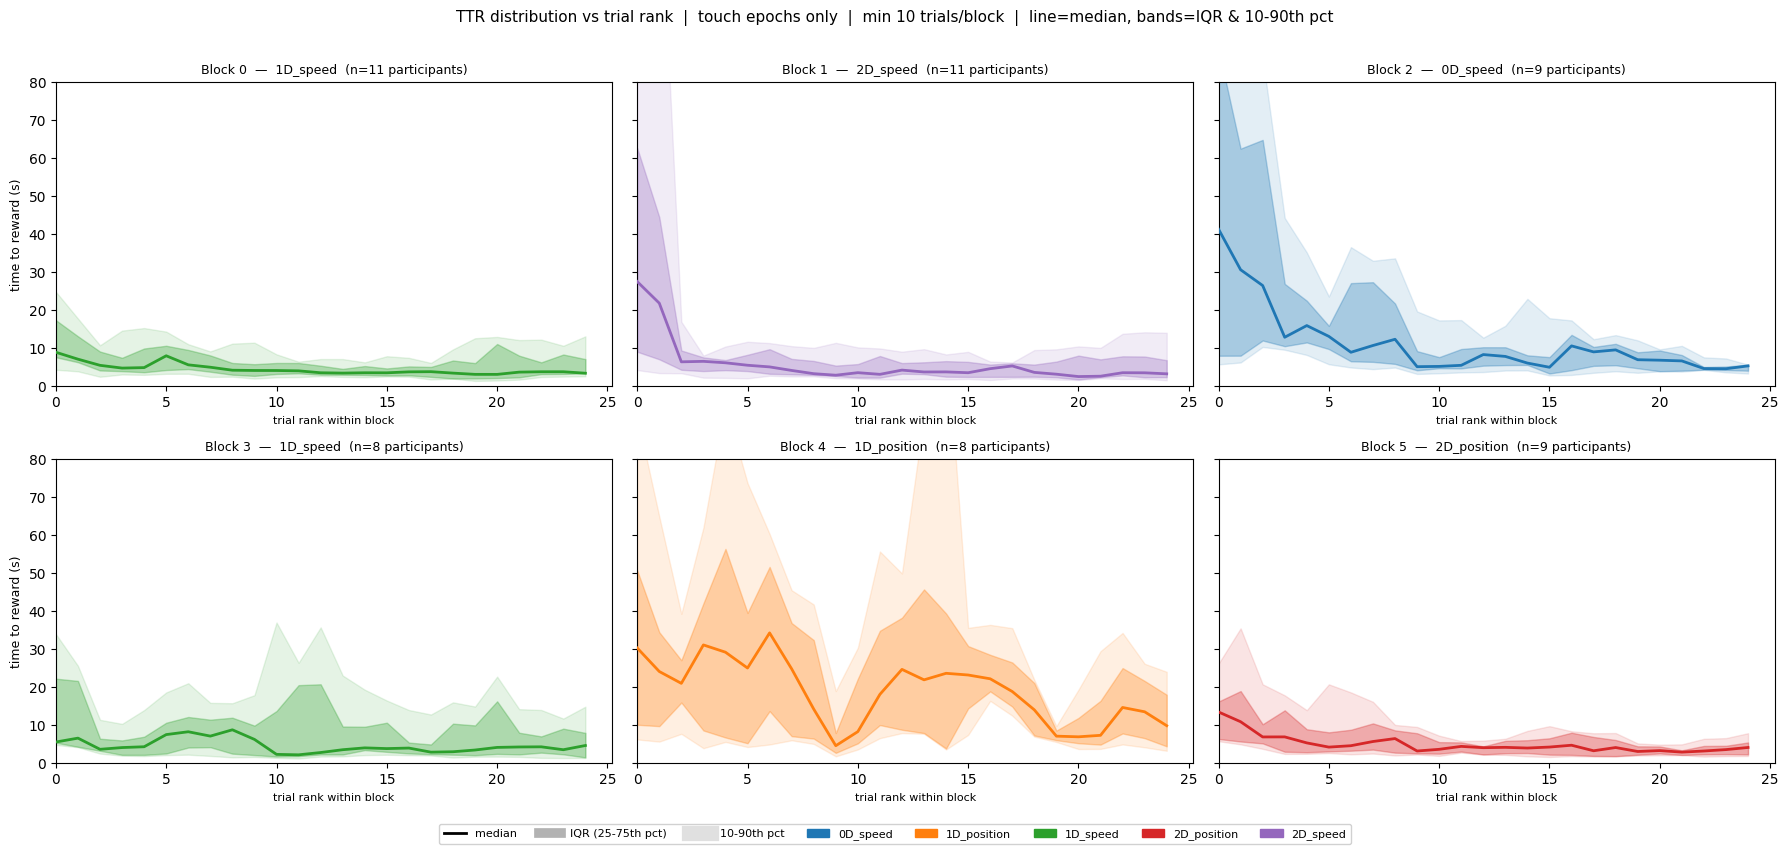


 Block  Feedback type     Participants  Rewarded trials   Median TTR (s)
------------------------------------------------------------------------
     0  1D_speed                    11              265             4.25
     1  2D_speed                    11              265             4.57
     2  0D_speed                     9              175             9.19
     3  1D_speed                     8              201             4.38
     4  1D_position                  8              151            18.27
     5  2D_position                  9              220             4.33


In [50]:
# ---- TTR by feedback type across participants -------------------------
# Figure 1: rolling-mean TTR per participant per block (one subplot per block).
# Figure 2: aggregate distribution (median + IQR + 10-90th pct) per feedback type.
# Only touch epochs (first_touch_time not None) and rewarded trials.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import math
from collections import defaultdict

# ---- parameters --------------------------------------------------------
subject_ids      = [f'human_{i}' for i in range(1, 13)]
session          = 0
min_trials       = 10       # skip blocks with fewer trials
touch_param_id   = 0
sat_param_id     = 0
include_blocks   = None     # None = all blocks, or list e.g. [0, 3]
trial_rank_range = None     # None = all, or (first, last) inclusive 0-indexed rank
min_coverage     = 2        # min participant-blocks needed to draw distribution
smooth_window    = 3        # within-block rolling-mean window (Figure 1 lines)
y_max_fig1       = 150      # y-axis upper limit for Figure 
y_max_fig2       = 80     # y-axis upper limit for Figure 2 (None = auto)1 (None = auto)

BLOCK_LABELS = {
    0: '1D_speed',
    1: '2D_speed',
    2: '0D_speed',
    3: '1D_speed',
    4: '1D_position',
    5: '2D_position',
}

# ---- collect data ------------------------------------------------------
# line_data[block]  = list of (smoothed_arr, subject_id)   <- Figure 1
# dist_data[ft]     = list of per-block smoothed arrays     <- Figure 2
line_data = defaultdict(list)
dist_data = defaultdict(list)

def rolling_mean_1d(arr, w):
    out = np.full(len(arr), np.nan)
    valid = ~np.isnan(arr)
    idx   = np.where(valid)[0]
    vals  = arr[valid]
    for k, i in enumerate(idx):
        lo = max(0, k - w // 2)
        hi = min(len(vals), k + w // 2 + 1)
        out[i] = np.mean(vals[lo:hi])
    return out

for subject_id in subject_ids:
    base_key  = {'subject_id': subject_id, 'session': session}
    blk_query = experiment.Block & base_key
    if len(blk_query) == 0:
        continue

    b_nums, fb_types_arr = blk_query.fetch('block', 'feedback_type', order_by='block')

    for block, fb_type in zip(b_nums.tolist(), fb_types_arr.tolist()):
        blk_num = int(block)
        if include_blocks is not None and blk_num not in include_blocks:
            continue

        blk_key = {**base_key, 'block': block}
        det_key = {**blk_key,
                   'touch_param_id': touch_param_id,
                   'sat_param_id':   sat_param_id}

        trials = (experiment.BehaviorTrial & blk_key).fetch('trial', order_by='trial')
        if len(trials) < min_trials:
            print(f'  skip  {subject_id}  {fb_type}  blk {blk_num}: '
                  f'{len(trials)} trials (< {min_trials})')
            continue

        timing_rows = behavior_analysis.TrialTiming & det_key
        if len(timing_rows) == 0:
            continue

        t_nums, ttrs, ft_times = timing_rows.fetch(
            'trial', 'time_to_reward', 'first_touch_time', order_by='trial'
        )

        trial_order = {int(t): rank for rank, t in enumerate(trials)}
        block_arr   = np.full(len(trials), np.nan)

        for t, ttr, ftt in zip(t_nums, ttrs, ft_times):
            if ttr is None or ftt is None:
                continue
            rank = trial_order.get(int(t))
            if rank is None:
                continue
            if trial_rank_range is not None:
                lo, hi = trial_rank_range
                if rank < lo or rank > hi:
                    continue
            block_arr[rank] = float(ttr)

        smoothed = rolling_mean_1d(block_arr, smooth_window)

        if np.any(~np.isnan(smoothed)):
            line_data[blk_num].append((smoothed, subject_id))
            dist_data[fb_type].append(smoothed)

fb_types = sorted(set(dist_data.keys()))
blocks   = sorted(BLOCK_LABELS.keys())

if not line_data and not dist_data:
    print('No data collected.')
else:
    subjects = sorted(
        set(subj for arrs in line_data.values() for _, subj in arrs),
        key=lambda s: int(s.split('_')[1])
    )
    cmap        = plt.get_cmap('tab20')
    subj_colors = {s: cmap(i / max(len(subjects) - 1, 1))
                   for i, s in enumerate(subjects)}

    # ---- Figure 1: rolling-mean TTR lines per block --------------------
    n_blks = len(blocks)
    n_cols = 3
    n_rows = math.ceil(n_blks / n_cols)

    fig1, axes1 = plt.subplots(
        n_rows, n_cols,
        figsize=(6 * n_cols, 4 * n_rows),
        sharey=True, squeeze=False
    )
    for pi, blk in enumerate(blocks):
        ax    = axes1.flat[pi]
        label = BLOCK_LABELS[blk]
        for smoothed, subj in line_data.get(blk, []):
            valid = ~np.isnan(smoothed)
            if valid.any():
                ax.plot(np.where(valid)[0], smoothed[valid],
                        color=subj_colors[subj], lw=1.2, alpha=0.75,
                        zorder=2)
        ax.set_title(f'Block {blk}  —  {label}', fontsize=9)
        ax.set_xlabel('trial rank within block', fontsize=8)
        ax.set_xlim(left=0)
        ax.set_ylim(0, y_max_fig1) if y_max_fig1 is not None else ax.set_ylim(bottom=0)
        if pi % n_cols == 0:
            ax.set_ylabel('rolling mean TTR (s)', fontsize=9)

    for ax in list(axes1.flat)[n_blks:]:
        ax.set_visible(False)

    legend_handles = [
        mlines.Line2D([], [], color=subj_colors[s], lw=2, label=s)
        for s in subjects
    ]
    fig1.legend(handles=legend_handles,
                loc='lower center', ncol=min(len(subjects), 6),
                fontsize=7, bbox_to_anchor=(0.5, -0.04),
                framealpha=0.9, title='participant', title_fontsize=7)
    fig1.suptitle(
        f'Rolling-mean TTR per participant per block  |  touch epochs only  '
        f'|  window={smooth_window}  |  min {min_trials} trials/block',
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.show()

    # ---- Figure 2: distribution subplots per block --------------------
    # Colour by feedback type so blocks sharing the same type share a hue.
    ft_unique = sorted(set(BLOCK_LABELS.values()))
    cmap2     = plt.get_cmap('tab10')
    ft_color  = {ft: cmap2(i % 10) for i, ft in enumerate(ft_unique)}

    n_blks2 = len(blocks)
    n_cols2 = 3
    n_rows2 = math.ceil(n_blks2 / n_cols2)

    fig2, axes2 = plt.subplots(
        n_rows2, n_cols2,
        figsize=(6 * n_cols2, 4 * n_rows2),
        sharey=True, squeeze=False
    )
    for pi, blk in enumerate(blocks):
        ax    = axes2.flat[pi]
        label = BLOCK_LABELS[blk]
        col   = ft_color[label]
        arrs  = [a for a, _ in line_data.get(blk, [])]

        if arrs:
            max_t = max(len(a) for a in arrs)
            n_blk = len(arrs)
            mat   = np.full((n_blk, max_t), np.nan)
            for bi, arr in enumerate(arrs):
                mat[bi, :len(arr)] = arr

            coverage = np.sum(~np.isnan(mat), axis=0)
            xv       = np.where(coverage >= min_coverage)[0]

            if len(xv) > 0:
                med = np.nanmedian(mat, axis=0)
                q25 = np.nanpercentile(mat, 25, axis=0)
                q75 = np.nanpercentile(mat, 75, axis=0)
                q10 = np.nanpercentile(mat, 10, axis=0)
                q90 = np.nanpercentile(mat, 90, axis=0)
                ax.fill_between(xv, q10[xv], q90[xv],
                                color=col, alpha=0.12, zorder=1)
                ax.fill_between(xv, q25[xv], q75[xv],
                                color=col, alpha=0.30, zorder=2)
                ax.plot(xv, med[xv], color=col, lw=2.0, zorder=3)

        ax.set_title(f'Block {blk}  —  {label}  (n={len(arrs)} participants)',
                     fontsize=9)
        ax.set_xlabel('trial rank within block', fontsize=8)
        ax.set_xlim(left=0)
        ax.set_ylim(0, y_max_fig2) if y_max_fig2 is not None else ax.set_ylim(bottom=0)
        if pi % n_cols2 == 0:
            ax.set_ylabel('time to reward (s)', fontsize=9)

    for ax in list(axes2.flat)[n_blks2:]:
        ax.set_visible(False)

    h_med  = mlines.Line2D([], [], color='black', lw=2.0, label='median')
    h_iqr  = mlines.Line2D([], [], color='black', lw=7,   alpha=0.30,
                            label='IQR (25-75th pct)')
    h_wide = mlines.Line2D([], [], color='black', lw=11,  alpha=0.12,
                            label='10-90th pct')
    ft_handles = [
        mpatches.Patch(color=ft_color[ft], label=ft) for ft in ft_unique
    ]
    fig2.legend(handles=[h_med, h_iqr, h_wide] + ft_handles,
                loc='lower center', ncol=3 + len(ft_unique), fontsize=8,
                bbox_to_anchor=(0.5, -0.04), framealpha=0.9)
    fig2.suptitle(
        'TTR distribution vs trial rank  |  touch epochs only  '
        f'|  min {min_trials} trials/block  |  line=median, bands=IQR & 10-90th pct',
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.show()

    # ---- summary table -------------------------------------------------
    print(f'\n{"Block":>6}  {"Feedback type":<16} {"Participants":>13} '
          f'{"Rewarded trials":>16} {"Median TTR (s)":>16}')
    print('-' * 72)
    for blk in blocks:
        arrs    = line_data.get(blk, [])
        all_v   = np.concatenate(
            [a[~np.isnan(a)] for a, _ in arrs]
        ) if arrs else np.array([])
        ft_lbl  = BLOCK_LABELS[blk]
        med_s   = f'{np.median(all_v):.2f}' if len(all_v) else 'n/a'
        print(f'{blk:>6}  {ft_lbl:<16} {len(arrs):>13} '
              f'{len(all_v):>16} {med_s:>16}')


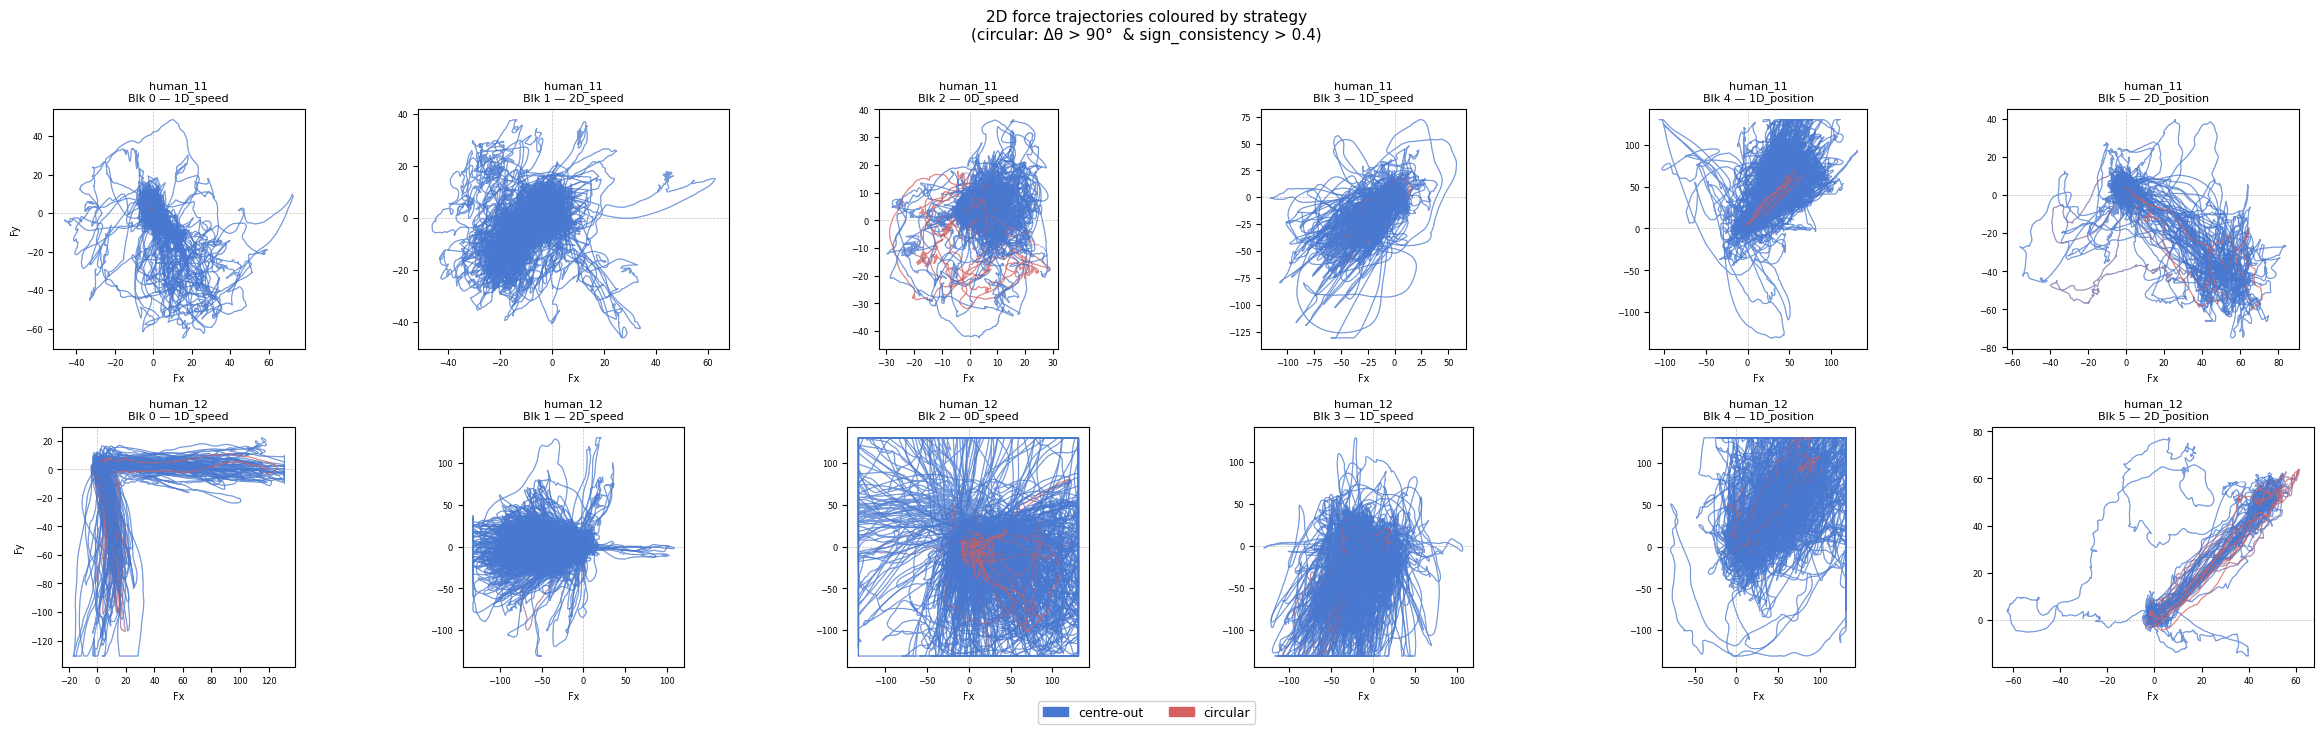

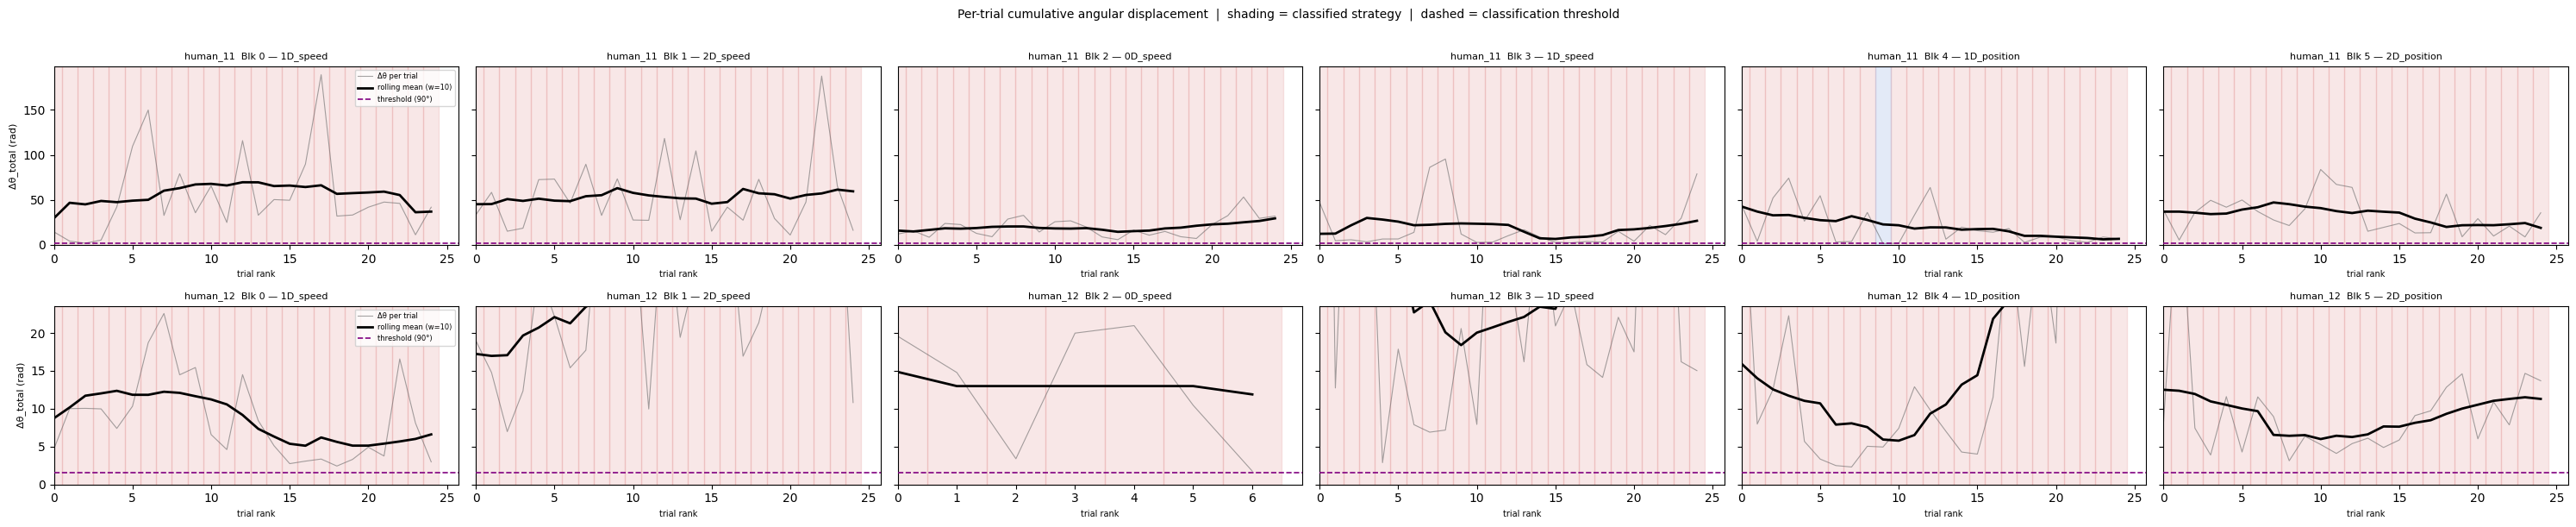


Subject      Block Label           Epochs  % circular  % centre-out
------------------------------------------------------------------
human_11         0 1D_speed           108        1.9%         98.1%
human_11         1 2D_speed           163        3.1%         96.9%
human_11         2 0D_speed           314        9.6%         90.4%
human_11         3 1D_speed           250        8.8%         91.2%
human_11         4 1D_position        282        6.0%         94.0%
human_11         5 2D_position        129        7.8%         92.2%
human_12         0 1D_speed           408       10.0%         90.0%
human_12         1 2D_speed           310        2.9%         97.1%
human_12         2 0D_speed           867       12.3%         87.7%
human_12         3 1D_speed           344        8.7%         91.3%
human_12         4 1D_position        348       22.7%         77.3%
human_12         5 2D_position        119       17.6%         82.4%


In [57]:
# =============================================================================
# STRATEGY CLASSIFICATION: Centre-out  vs  Circular
# =============================================================================
#
# Background
# ----------
# Participants use one of two qualitatively different strategies when exploring
# the 2D force space:
#
#   Centre-out  (e.g. human_12)
#       The participant drives the force cursor in a roughly straight radial
#       line from its current resting position toward the target.  The
#       *direction* of the applied force barely changes — they push in one
#       direction and stop.
#
#   Circular  (e.g. human_11)
#       The participant sweeps the force cursor in an arc or circle around the
#       2D force plane.  The *direction* of the applied force rotates
#       substantially — they steer continuously rather than push straight.
#
# Approach
# --------
# Both strategies leave distinct signatures in the time-series of the force
# *direction angle*  θ(t) = arctan2(Fy(t), Fx(t)).
# We extract four complementary features from each touch epoch and use a
# simple threshold rule to assign a strategy label.  We then track these
# labels across trials to detect when a participant switches strategy.
#
# Features computed per touch epoch
# ----------------------------------
# 1. delta_theta_total
#       Cumulative absolute angular displacement of the force vector (radians).
#       = Σ |θ(t+1) − θ(t)|  (angles unwrapped to remove ±π discontinuities)
#       Interpretation: small → force direction barely moves (centre-out);
#                       large → force direction sweeps widely (circular).
#
# 2. sign_consistency
#       Directional consistency of the angular rotation.
#       = |Σ dθ_i| / Σ |dθ_i|   ∈ [0, 1]
#       A purely clockwise or anti-clockwise sweep gives 1; random noise gives 0.
#       Why needed alongside delta_theta_total: noisy short-duration epochs
#       can accumulate high angular displacement without any real rotation.
#
# 3. straightness_index
#       Ratio of end-to-end Euclidean distance to total path length in force
#       space.  = ||F_end − F_start|| / Σ ||F(t+1) − F(t)||   ∈ (0, 1]
#       1 = perfectly straight line (centre-out), < 1 = curved (circular).
#
# 4. vtan_vrad_ratio
#       Mean tangential velocity divided by mean radial velocity in polar
#       force coordinates.
#       Radial velocity   = component of ΔF along the current force direction.
#       Tangential velocity = component of ΔF perpendicular to it.
#       High ratio → participant is steering *around* the origin (circular);
#       low ratio  → participant is pushing *toward/away* from origin (centre-out).
#
# Classification rule (applied per epoch)
# ----------------------------------------
#   circular   if  delta_theta_total > theta_threshold
#              AND sign_consistency  > sign_threshold
#   centre-out otherwise
#
# Switch detection
# ----------------
# We compute a per-trial summary score (mean delta_theta_total across all
# touch epochs in that trial) and smooth it with a rolling mean.
# A sustained shift in this trace across trials signals a strategy change.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import math
from collections import defaultdict

# ---- Parameters ------------------------------------------------------------
subject_ids       = ['human_11', 'human_12']
session           = 0
blocks_to_analyse = None      # None = all blocks, or list e.g. [0, 1, 2]
touch_param_id    = 0
sat_param_id      = 0
min_epoch_samples = 5         # discard touch epochs shorter than this many samples

# force_trace_time is stored directly in experiment.TrialForceTrace —
# no sampling rate needed; the time axis is fetched with the trace.

# Classification thresholds
# theta_threshold: cumulative angular displacement above which an epoch is
#   classified as "circular".  pi/2 (~90°) is a reasonable starting point;
#   increase to require more sweeping before calling it circular.
theta_threshold = np.pi / 2   # radians

# sign_threshold: sign_consistency must also exceed this to be "circular".
#   Prevents noisy, jittery epochs from being misclassified.
sign_threshold  = 0.4

# Switch detection: width of the centred rolling-mean window (in trials).
rolling_window  = 10

# Visual style
STRATEGY_COLORS = {'centre-out': '#4878CF', 'circular': '#D65F5F'}

BLOCK_LABELS = {
    0: '1D_speed',
    1: '2D_speed',
    2: '0D_speed',
    3: '1D_speed',
    4: '1D_position',
    5: '2D_position',
}

# ---- Helper: unwrap angular differences ------------------------------------
def angular_diff(theta_arr):
    """
    Compute the first difference of an angle array with proper wrapping.
    Returns an array of length len(theta_arr)-1 where each element is the
    shortest angular step (in radians) from one sample to the next,
    constrained to [-pi, pi].
    """
    # np.unwrap removes discontinuities at ±π before differencing
    return np.diff(np.unwrap(theta_arr))


# ---- Helper: compute the four strategy features for one touch epoch --------
def compute_epoch_features(fx, fy):
    """
    Parameters
    ----------
    fx, fy : 1-D float arrays
        Fx and Fy force components sampled at uniform rate within one epoch.

    Returns
    -------
    dict with keys delta_theta_total, sign_consistency,
                   straightness_index, vtan_vrad_ratio
    or None if the epoch is too short.
    """
    n = len(fx)
    if n < 3:
        return None

    # ---- Feature 1 & 2: angular displacement of force direction --------
    # θ(t): direction of the force vector at each sample.
    theta  = np.arctan2(fy, fx)          # shape (n,),  range (-π, π]
    dtheta = angular_diff(theta)          # shape (n-1,), signed steps

    # Cumulative angular displacement — the "total degrees swept".
    delta_theta_total = float(np.sum(np.abs(dtheta)))

    # Sign consistency: are the angular steps all in the same direction?
    # |net change| / cumulative change.  Guard against near-zero denominators.
    if delta_theta_total > 1e-6:
        sign_consistency = float(abs(np.sum(dtheta)) / delta_theta_total)
    else:
        sign_consistency = 0.0

    # ---- Feature 3: path straightness ----------------------------------
    # Step lengths in 2D force space
    dfx = np.diff(fx)
    dfy = np.diff(fy)
    step_lengths = np.sqrt(dfx**2 + dfy**2)
    path_length  = float(np.sum(step_lengths))

    end_to_end = float(np.hypot(fx[-1] - fx[0], fy[-1] - fy[0]))
    straightness_index = (min(end_to_end / path_length, 1.0)
                          if path_length > 1e-9 else 1.0)

    # ---- Feature 4: tangential vs radial velocity ----------------------
    # Velocity vectors are the step displacements (dfx, dfy).
    # We decompose each into:
    #   radial component    = projection onto the current force unit vector F̂
    #   tangential component = perpendicular component (the "steering" part)
    #
    # Force vector at midpoint between consecutive samples:
    fx_mid = (fx[:-1] + fx[1:]) / 2.0
    fy_mid = (fy[:-1] + fy[1:]) / 2.0
    r_mid  = np.hypot(fx_mid, fy_mid)      # force magnitude at midpoint
    safe   = r_mid > 1e-9

    # Radial velocity: dot product of velocity with F̂
    v_rad = np.where(safe,
                     (dfx * fx_mid + dfy * fy_mid) / r_mid,
                     0.0)

    # Tangential velocity: 2D cross-product magnitude (|dfx*fy_mid - dfy*fx_mid| / r_mid)
    # This is always >= 0 (perpendicular speed).
    v_tan = np.where(safe,
                     np.abs(dfx * fy_mid - dfy * fx_mid) / r_mid,
                     0.0)

    mean_vrad = float(np.mean(np.abs(v_rad)))
    mean_vtan = float(np.mean(v_tan))

    vtan_vrad_ratio = (mean_vtan / mean_vrad
                       if mean_vrad > 1e-9
                       else float(mean_vtan > 1e-9))

    return {
        'delta_theta_total':  delta_theta_total,
        'sign_consistency':   sign_consistency,
        'straightness_index': straightness_index,
        'vtan_vrad_ratio':    vtan_vrad_ratio,
    }


# ---- Helper: classify a single epoch -----------------------------------
def classify_strategy(features):
    """
    Apply threshold rule.
    Returns 'circular' or 'centre-out'.
    """
    if (features['delta_theta_total'] > theta_threshold and
            features['sign_consistency']  > sign_threshold):
        return 'circular'
    return 'centre-out'


# ---- Helper: centred rolling mean --------------------------------------
def rolling_mean_1d(arr, w):
    """
    Centred rolling mean over a 1-D float array, ignoring NaN.
    Window half-width = w // 2.
    """
    out = np.full_like(arr, np.nan, dtype=float)
    for i in range(len(arr)):
        lo = max(0, i - w // 2)
        hi = min(len(arr), i + w // 2 + 1)
        seg = arr[lo:hi]
        valid = seg[~np.isnan(seg)]
        if len(valid):
            out[i] = valid.mean()
    return out


# ---- Data collection ---------------------------------------------------
# For each participant → block → trial → touch epoch:
#   1. Load the force trace for the trial.
#   2. Build a trial-relative time axis using the sampling rate.
#   3. Clip the trace to the touch epoch window.
#   4. Compute the four features on the clipped trace.
#   5. Assign a strategy label.
#
# epoch_records[subject_id] = list of dicts, one per classified touch epoch.
epoch_records = defaultdict(list)

for subject_id in subject_ids:
    base_key  = {'subject_id': subject_id, 'session': session}
    blk_query = experiment.Block & base_key
    if len(blk_query) == 0:
        print(f'  no blocks: {subject_id}')
        continue

    b_nums  = blk_query.fetch('block', order_by='block')

    for block in b_nums.tolist():
        blk_num = int(block)
        if blocks_to_analyse is not None and blk_num not in blocks_to_analyse:
            continue

        blk_key = {**base_key, 'block': block}
        det_key = {**blk_key,
                   'touch_param_id': touch_param_id,
                   'sat_param_id':   sat_param_id}

        # All trials in this block, ordered so trial_rank is meaningful.
        trials = (experiment.BehaviorTrial & blk_key).fetch(
            'trial', order_by='trial'
        )
        trial_rank_map = {int(t): rank for rank, t in enumerate(trials)}

        for trial in trials:
            t_key = {**blk_key, 'trial': trial}

            # -- Load force trace ----------------------------------------
            # experiment.TrialForceTrace stores the time axis on the master
            # table (force_trace_time, seconds from trial start) and the
            # per-axis force values in the TrialForceAxis part table
            # (force_axis_idx 0 = x, 1 = y; force_trace_value in grams).
            if len(experiment.TrialForceTrace & t_key) == 0:
                continue

            t_rel = np.array(
                (experiment.TrialForceTrace & t_key).fetch1('force_trace_time'),
                dtype=float
            )  # seconds from trial start

            axis_idx, axis_val = (
                experiment.TrialForceTrace.TrialForceAxis & t_key
                & 'force_axis_idx < 2'
            ).fetch('force_axis_idx', 'force_trace_value',
                    order_by='force_axis_idx')

            if len(axis_val) < 2:
                continue  # need both x and y axes

            force_axes = {int(i): np.array(v, dtype=float)
                          for i, v in zip(axis_idx, axis_val)}
            fx_full = force_axes[0]  # axis 0 = x
            fy_full = force_axes[1]  # axis 1 = y

            # -- Load touch epochs for this trial ------------------------
            # TrialTouchTimes.TouchEpoch primary key: (is_touch, epoch_idx).
            # Filter to is_touch=True to get only contact periods.
            # start_time / end_time are in seconds from trial start —
            # same reference frame as force_trace_time above.
            touch_query = (behavior_analysis.TrialTouchTimes.TouchEpoch
                           & t_key & {'is_touch': True})
            if len(touch_query) == 0:
                continue

            ep_idxs, ep_starts, ep_ends = touch_query.fetch(
                'epoch_idx', 'start_time', 'end_time',
                order_by='epoch_idx'
            )

            for ep_idx, ep_start, ep_end in zip(ep_idxs, ep_starts, ep_ends):
                # Slice the force trace to the epoch window.
                mask = (t_rel >= float(ep_start)) & (t_rel <= float(ep_end))
                if mask.sum() < min_epoch_samples:
                    continue  # too short — features would be unreliable

                fx_ep = fx_full[mask]
                fy_ep = fy_full[mask]

                features = compute_epoch_features(fx_ep, fy_ep)
                if features is None:
                    continue

                strategy = classify_strategy(features)

                epoch_records[subject_id].append({
                    'block':       blk_num,
                    'trial':       int(trial),
                    'trial_rank':  trial_rank_map[int(trial)],
                    'epoch_idx':   int(ep_idx),
                    'fx':          fx_ep,
                    'fy':          fy_ep,
                    'features':    features,
                    'strategy':    strategy,
                })

if not any(epoch_records.values()):
    print('No data collected.  '
          'Check subject_ids, field names in experiment.TrialForceTrace, '
          'and whether epoch times are trial-relative or block-relative.')
else:
    all_blocks_found = sorted(set(
        ep['block']
        for eplist in epoch_records.values()
        for ep in eplist
    ))

    n_subj = len(subject_ids)
    n_blks = len(all_blocks_found)

    # ---- Figure 1: 2D force trajectories coloured by strategy ----------
    # Layout: rows = participants, columns = blocks.
    # Each line = one touch epoch; colour encodes the classified strategy.
    # This gives an immediate visual impression of which strategy dominates
    # and where (in force space) each strategy tends to occur.
    fig1, axes1 = plt.subplots(
        n_subj, n_blks,
        figsize=(4 * n_blks, 3.5 * n_subj),
        squeeze=False
    )
    for si, subject_id in enumerate(subject_ids):
        for bi, blk in enumerate(all_blocks_found):
            ax     = axes1[si][bi]
            epochs = [ep for ep in epoch_records[subject_id]
                      if ep['block'] == blk]

            for ep in epochs:
                ax.plot(ep['fx'], ep['fy'],
                        color=STRATEGY_COLORS[ep['strategy']],
                        lw=0.8, alpha=0.5, zorder=2)

            # Reference lines at the origin (neutral force position)
            ax.axhline(0, color='silver', lw=0.5, ls='--', zorder=1)
            ax.axvline(0, color='silver', lw=0.5, ls='--', zorder=1)

            blk_label = BLOCK_LABELS.get(blk, f'blk {blk}')
            ax.set_title(f'{subject_id}\nBlk {blk} — {blk_label}', fontsize=8)
            ax.set_xlabel('Fx', fontsize=7)
            if bi == 0:
                ax.set_ylabel('Fy', fontsize=7)
            ax.set_aspect('equal')
            ax.tick_params(labelsize=6)

    strat_handles = [
        mpatches.Patch(color=v, label=k)
        for k, v in STRATEGY_COLORS.items()
    ]
    fig1.legend(handles=strat_handles, loc='lower center', ncol=2,
                fontsize=9, bbox_to_anchor=(0.5, -0.02), framealpha=0.9)
    fig1.suptitle(
        '2D force trajectories coloured by strategy\n'
        f'(circular: Δθ > {np.degrees(theta_threshold):.0f}°  '
        f'& sign_consistency > {sign_threshold})',
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.show()

    # ---- Figure 2: per-trial strategy score over time ------------------
    # For each trial we compute the mean delta_theta_total across all its
    # touch epochs.  Plotting this over trial rank reveals when the
    # participant's strategy changes:
    #   — sustained values above the threshold line → circular phase
    #   — sustained values below                   → centre-out phase
    #
    # The rolling mean (thick line) acts as a low-pass filter that makes
    # transitions visible even when individual trials are noisy.
    # Background shading uses the per-trial classification to provide an
    # intuitive colour-coded timeline of strategy use.
    fig2, axes2 = plt.subplots(
        n_subj, n_blks,
        figsize=(5 * n_blks, 3 * n_subj),
        sharey='row',
        squeeze=False
    )
    for si, subject_id in enumerate(subject_ids):
        for bi, blk in enumerate(all_blocks_found):
            ax = axes2[si][bi]

            # Aggregate delta_theta_total per trial rank (mean over epochs)
            trial_scores = defaultdict(list)
            for ep in epoch_records[subject_id]:
                if ep['block'] == blk:
                    trial_scores[ep['trial_rank']].append(
                        ep['features']['delta_theta_total']
                    )

            if not trial_scores:
                ax.set_visible(False)
                continue

            ranks  = np.array(sorted(trial_scores.keys()))
            scores = np.array([np.mean(trial_scores[r]) for r in ranks])

            # Shade each trial column by its dominant strategy.
            # This creates a colour-coded timeline without needing a binary
            # step function.
            for r, s in zip(ranks, scores):
                strat = 'circular' if s > theta_threshold else 'centre-out'
                ax.axvspan(r - 0.5, r + 0.5,
                           color=STRATEGY_COLORS[strat],
                           alpha=0.15, zorder=0)

            # Raw per-trial score: noisy but trial-level resolution.
            ax.plot(ranks, scores,
                    color='dimgrey', lw=0.8, alpha=0.6,
                    zorder=2, label='Δθ per trial')

            # Rolling mean: the primary indicator of strategy phase.
            # A crossing of the threshold line that persists for > ~window/2
            # trials is a candidate strategy switch.
            smoothed = rolling_mean_1d(scores, rolling_window)
            ax.plot(ranks, smoothed,
                    color='black', lw=2.0,
                    zorder=3, label=f'rolling mean (w={rolling_window})')

            # Threshold line: the decision boundary for classification.
            ax.axhline(theta_threshold,
                       color='purple', lw=1.2, ls='--', zorder=4,
                       label=f'threshold ({np.degrees(theta_threshold):.0f}°)')

            blk_label = BLOCK_LABELS.get(blk, f'blk {blk}')
            ax.set_title(f'{subject_id}  Blk {blk} — {blk_label}', fontsize=8)
            ax.set_xlabel('trial rank', fontsize=7)
            ax.set_xlim(left=0)
            ax.set_ylim(bottom=0)
            if bi == 0:
                ax.set_ylabel('Δθ_total (rad)', fontsize=8)
                ax.legend(fontsize=6, loc='upper right')

    fig2.suptitle(
        'Per-trial cumulative angular displacement  |  '
        'shading = classified strategy  |  '
        'dashed = classification threshold',
        fontsize=10, y=1.01
    )
    plt.tight_layout()
    plt.show()

    # ---- Summary table -------------------------------------------------
    print(f'\n{"Subject":<12} {"Block":>5} {"Label":<14} '
          f'{"Epochs":>7} {"% circular":>11} {"% centre-out":>13}')
    print('-' * 66)
    for subject_id in subject_ids:
        blk_grp = defaultdict(list)
        for ep in epoch_records[subject_id]:
            blk_grp[ep['block']].append(ep['strategy'])
        for blk in sorted(blk_grp):
            strats  = blk_grp[blk]
            n_circ  = sum(s == 'circular' for s in strats)
            n_tot   = len(strats)
            lbl     = BLOCK_LABELS.get(blk, '?')
            print(f'{subject_id:<12} {blk:>5} {lbl:<14} '
                  f'{n_tot:>7} {100*n_circ/n_tot:>10.1f}% '
                  f'{100*(n_tot-n_circ)/n_tot:>12.1f}%')


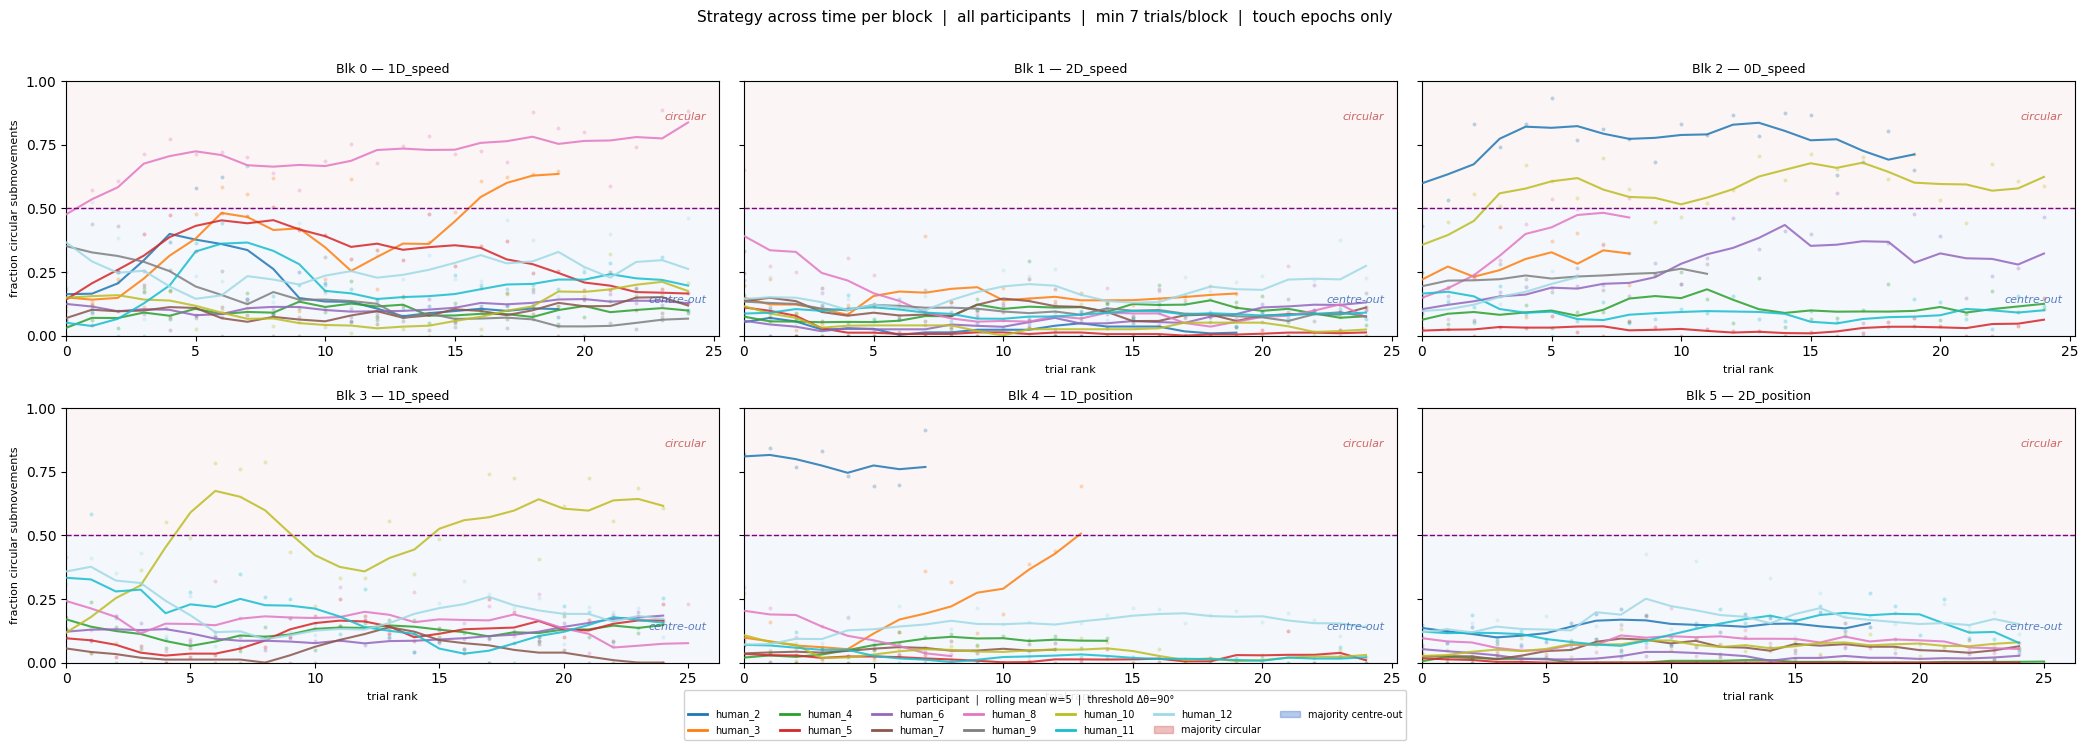


Subject       Blk0(1D_speed)  Blk1(2D_speed)  Blk2(0D_speed)  Blk3(1D_speed)  Blk4(1D_position)  Blk5(2D_position)
------------------------------------------------------------------------------------------------------------------------
human_2                 0.19            0.03            0.76        excluded            0.79            0.14
human_3                 0.38            0.15            0.28        excluded            0.22        excluded
human_4                 0.09            0.09            0.11            0.12            0.07            0.01
human_5                 0.31            0.02            0.03            0.11            0.02            0.00
human_6                 0.11            0.06            0.27            0.11        excluded            0.03
human_7                 0.10            0.10        excluded            0.05            0.05            0.06
human_8                 0.71            0.13            0.35            0.16            0.12            0.08


In [50]:
# =============================================================================
# STRATEGY ACROSS TIME — circular vs centre-out, all participants, per block
#
# For every participant-block (with >= min_trials trials) we compute a
# per-trial strategy score:
#
#   score = fraction of submovements in that trial classified as "circular"
#           (circular if Δθ_total > theta_threshold)
#
# score = 1 → all submovements circular
# score = 0 → all submovements centre-out
#
# Figure 1: line plots — score vs trial rank, one line per participant per block
#   Rolling mean applied to reveal sustained strategy phases.
#   Dashed horizontal line at 0.5 = majority-circular boundary.
#
# Figure 2: heatmap — participants × trial rank, colour = strategy score
#   Useful for spotting which participants switch strategy and when.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import math
from collections import defaultdict

# ---- Parameters --------------------------------------------------------
subject_ids        = [f'human_{i}' for i in range(1, 13)]
session            = 0
min_trials         = 7        # skip participant-blocks with fewer trials
touch_param_id     = 0
sat_param_id       = 0
subm_param_id      = 0

# Must match SubmovementDetectionParams
smooth_window_time = 0.03     # (s)

# Classification threshold
theta_threshold    = np.pi / 2   # radians

# Smoothing for Figure 1 line plots
rolling_window     = 5
exclude_blocks     = [6]

BLOCK_LABELS = {
    0: '1D_speed',   1: '2D_speed',  2: '0D_speed',
    3: '1D_speed',   4: '1D_position', 5: '2D_position',
}

# ---- Helpers -----------------------------------------------------------
def rolling_mean_1d(arr, w):
    out = np.full_like(arr, np.nan, dtype=float)
    for i in range(len(arr)):
        lo = max(0, i - w // 2)
        hi = min(len(arr), i + w // 2 + 1)
        v  = arr[lo:hi][~np.isnan(arr[lo:hi])]
        if len(v):
            out[i] = v.mean()
    return out

# ---- Data collection ---------------------------------------------------
# scores[subject_id][blk_num] = dict {trial_rank: fraction_circular}
scores = defaultdict(lambda: defaultdict(dict))

for subject_id in subject_ids:
    base_key  = {'subject_id': subject_id, 'session': session}
    blk_query = experiment.Block & base_key
    if len(blk_query) == 0:
        continue

    b_nums = blk_query.fetch('block', order_by='block')

    for block in b_nums.tolist():
        blk_num = int(block)
        blk_key = {**base_key, 'block': block}

        trials = (experiment.BehaviorTrial & blk_key).fetch(
            'trial', order_by='trial'
        )
        if len(trials) < min_trials:
            continue   # skip this participant-block

        trial_rank_map = {int(t): r for r, t in enumerate(trials)}

        for trial in trials:
            t_key     = {'subject_id': subject_id, 'session': session,
                         'trial': int(trial)}
            touch_key = {**t_key, 'sat_param_id': sat_param_id,
                         'touch_param_id': touch_param_id}
            subm_key  = {**touch_key, 'subm_param_id': subm_param_id}

            subm_master = behavior_analysis.TrialSubmovements & subm_key
            if len(subm_master) == 0 or subm_master.fetch1('n_submovements') == 0:
                continue

            # Load & smooth force trace
            if len(experiment.TrialForceTrace & t_key) == 0:
                continue
            t_full = np.array(
                (experiment.TrialForceTrace & t_key).fetch1('force_trace_time'),
                dtype=float
            )
            if len(t_full) < 3:
                continue

            ax_idx, ax_val = (
                experiment.TrialForceTrace.TrialForceAxis & t_key
                & 'force_axis_idx < 2'
            ).fetch('force_axis_idx', 'force_trace_value',
                    order_by='force_axis_idx')
            if len(ax_val) < 2:
                continue

            f_raw = {int(i): np.array(v, dtype=float)
                     for i, v in zip(ax_idx, ax_val)}
            dt = float(np.median(np.diff(t_full)))
            sw = max(1, int(smooth_window_time / dt))
            hw = sw // 2

            fx_s = np.convolve(f_raw[0], np.ones(sw)/sw, mode='valid')
            fy_s = np.convolve(f_raw[1], np.ones(sw)/sw, mode='valid')
            n    = min(len(fx_s), len(fy_s))
            fx_s, fy_s = fx_s[:n], fy_s[:n]

            t_s = t_full[hw: hw + n]
            if len(t_s) < n:
                t_s = t_full[0] + np.arange(n) * dt

            # Touch epoch mask
            touch_q = (behavior_analysis.TrialTouchTimes.TouchEpoch
                       & touch_key & {'is_touch': True})
            if len(touch_q) == 0:
                continue
            ep_st, ep_en = touch_q.fetch(
                'start_time', 'end_time', order_by='epoch_idx'
            )
            touch_mask = np.zeros(len(t_s), dtype=bool)
            for es, ee in zip(ep_st, ep_en):
                touch_mask |= (t_s >= float(es)) & (t_s <= float(ee))

            if not touch_mask.any():
                continue

            # Classify each submovement
            subm_q = (behavior_analysis.TrialSubmovements.Submovement & subm_key)
            if len(subm_q) == 0:
                continue
            ss, se = subm_q.fetch('start_time', 'end_time',
                                  order_by='submovement_idx')

            n_total, n_circ = 0, 0
            for st, en in zip(ss, se):
                mask = touch_mask & (t_s >= float(st)) & (t_s <= float(en))
                if mask.sum() < 3:
                    continue
                dtheta = np.diff(np.unwrap(np.arctan2(fy_s[mask], fx_s[mask])))
                dtt    = float(np.sum(np.abs(dtheta)))
                n_total += 1
                if dtt > theta_threshold:
                    n_circ += 1

            if n_total == 0:
                continue

            rank = trial_rank_map[int(trial)]
            scores[subject_id][blk_num][rank] = n_circ / n_total

# Collect all subjects and blocks that have data
subjects_found = [s for s in subject_ids if any(scores[s].values())]
all_blocks = sorted(set(b for s in subjects_found for b in scores[s]))
all_blocks = [b for b in all_blocks if b not in exclude_blocks]

if not subjects_found:
    print('No data collected.')
else:
    subj_cmap   = plt.get_cmap('tab20')
    subj_colors = {s: subj_cmap(i / max(len(subjects_found)-1, 1))
                   for i, s in enumerate(subjects_found)}

    n_blks  = len(all_blocks)
    n_cols  = min(n_blks, 3)
    n_rows  = math.ceil(n_blks / n_cols)

    # ---- Figure 1: line plots per participant per block ----------------
    fig1, axes1 = plt.subplots(
        n_rows, n_cols,
        figsize=(7 * n_cols, 3.5 * n_rows),
        sharey=True, squeeze=False
    )
    for pi, blk in enumerate(all_blocks):
        ax  = axes1.flat[pi]
        lbl = BLOCK_LABELS.get(blk, f'blk {blk}')

        for subject_id in subjects_found:
            blk_scores = scores[subject_id].get(blk, {})
            if not blk_scores:
                continue
            ranks = np.array(sorted(blk_scores.keys()))
            vals  = np.array([blk_scores[r] for r in ranks], dtype=float)
            col   = subj_colors[subject_id]

            # Raw dots
            ax.scatter(ranks, vals, color=col, s=8, alpha=0.3,
                       linewidths=0, zorder=2)
            # Rolling mean
            rm = rolling_mean_1d(vals, rolling_window)
            ax.plot(ranks, rm, color=col, lw=1.5, alpha=0.85, zorder=3)

        # Majority-circular boundary
        ax.axhline(0.5, color='purple', lw=1.0, ls='--', zorder=4,
                   label='0.5 boundary')
        # Light shading + region labels
        ax.axhspan(0.5, 1.0, color='#D65F5F', alpha=0.06, zorder=0)
        ax.axhspan(0.0, 0.5, color='#4878CF', alpha=0.06, zorder=0)
        ax.text(0.98, 0.88, 'circular',   transform=ax.transAxes,
                ha='right', va='top',    fontsize=8, style='italic',
                color='#C04040', alpha=0.8)
        ax.text(0.98, 0.12, 'centre-out', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=8, style='italic',
                color='#3060B0', alpha=0.8)

        ax.set_title(f'Blk {blk} — {lbl}', fontsize=9)
        ax.set_xlabel('trial rank', fontsize=8)
        ax.set_xlim(left=0)
        ax.set_ylim(0, 1)
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
        if pi % n_cols == 0:
            ax.set_ylabel('fraction circular submovements', fontsize=8)

    for ax in list(axes1.flat)[n_blks:]:
        ax.set_visible(False)

    subj_handles = [
        mlines.Line2D([], [], color=subj_colors[s], lw=2, label=s)
        for s in subjects_found
    ]
    circ_patch = mpatches.Patch(color='#D65F5F', alpha=0.4, label='majority circular')
    co_patch   = mpatches.Patch(color='#4878CF', alpha=0.4, label='majority centre-out')
    fig1.legend(
        handles=subj_handles + [circ_patch, co_patch],
        loc='lower center',
        ncol=min(len(subjects_found) + 2, 7),
        fontsize=7, bbox_to_anchor=(0.5, -0.04), framealpha=0.9,
        title=f'participant  |  rolling mean w={rolling_window}  '
              f'|  threshold Δθ={np.degrees(theta_threshold):.0f}°',
        title_fontsize=7
    )
    fig1.suptitle(
        'Strategy across time per block  |  all participants  '
        f'|  min {min_trials} trials/block  |  touch epochs only',
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.show()

    # ---- Summary table -------------------------------------------------
    print(f'\n{"Subject":<12}', end='')
    for blk in all_blocks:
        print(f'  Blk{blk}({BLOCK_LABELS.get(blk,"?"[:6])})', end='')
    print()
    print('-' * (12 + 18 * len(all_blocks)))
    for subject_id in subjects_found:
        print(f'{subject_id:<12}', end='')
        for blk in all_blocks:
            blk_scores = scores[subject_id].get(blk, {})
            if blk_scores:
                mean_circ = np.mean(list(blk_scores.values()))
                print(f'  {mean_circ:>14.2f}', end='')
            else:
                print(f'  {"excluded":>14}', end='')
        print()
    print("(values = mean fraction-circular across trials)")


Fetching exploration metrics…
Fetching expert-onset metrics…
Done.


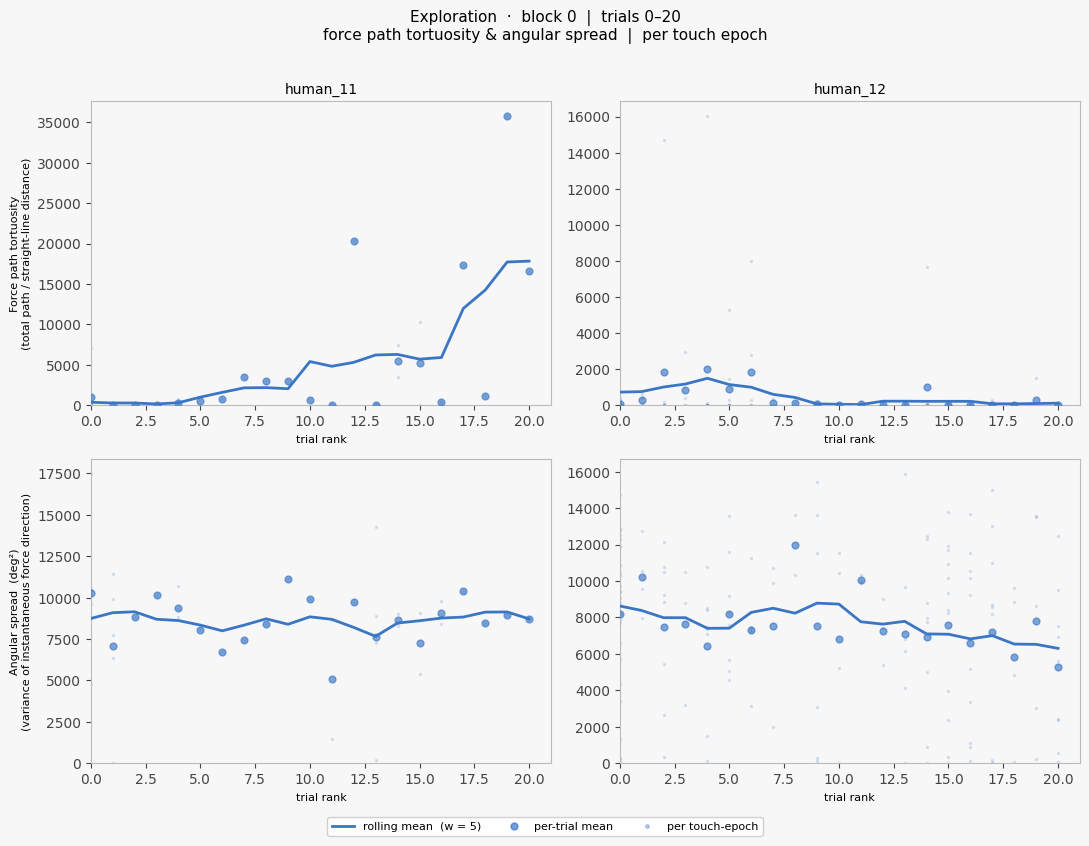

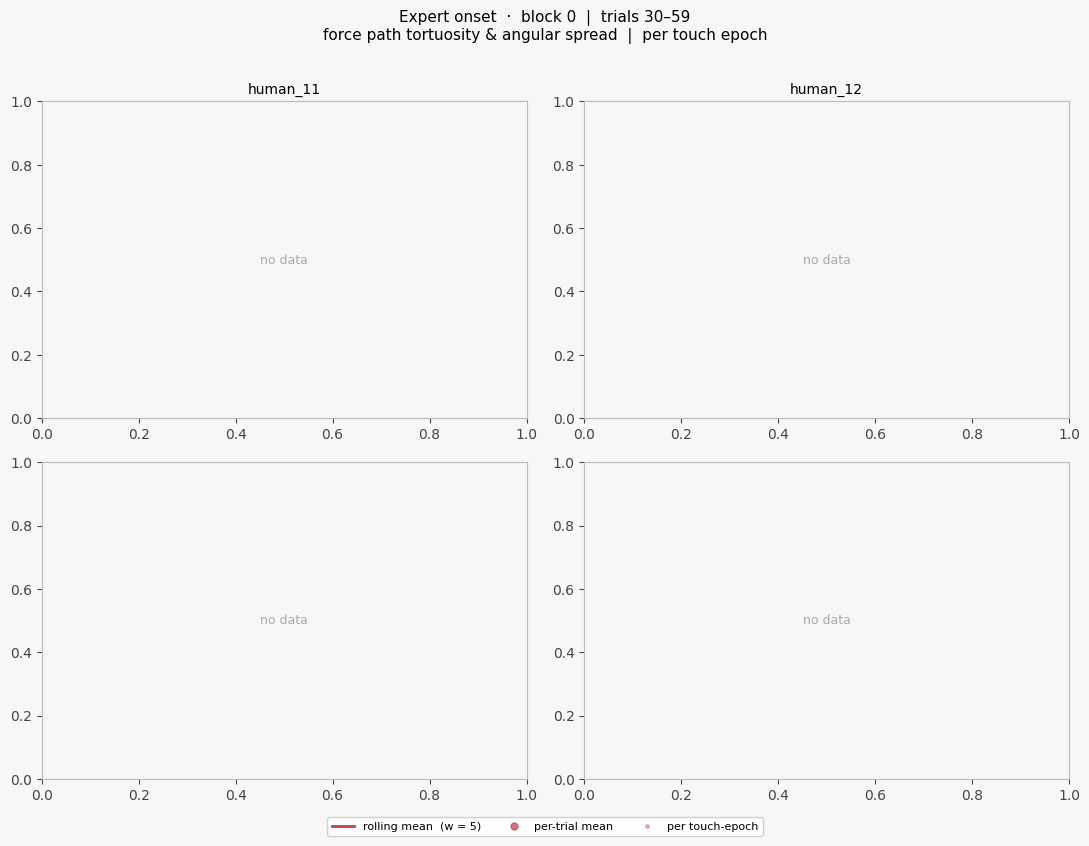

In [49]:
# ── Force path tortuosity & angular spread per touch epoch ──────────────────
# Two sections compared: an exploration window and an expert-onset window.
# Tortuosity = total path length / straight-line distance per epoch  (≥1; 1=straight)
# Angular spread = variance of instantaneous force direction (deg²) per epoch
#
# Self-contained — fetches data directly, independent of cell 30's variables.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# ── parameters ───────────────────────────────────────────────────────────────
subjects        = ['human_11', 'human_12']
session         = 0
smooth_window   = 30        # samples — keep consistent with cell 30
touch_param_id  = 0
sat_param_id    = 0
rolling_window  = 5         # window for per-trial rolling mean

# Exploration section
expl_block        = 0
expl_trial_range  = (0, 21)    # [start, end)  — end is exclusive

# Expert-onset section  (adjust to the first window of stable expert performance)
expert_block       = 0
expert_trial_range = (30, 60)  # [start, end)

# ── colours ──────────────────────────────────────────────────────────────────
C_EXPL   = '#3A76C4'    # blue  — exploration
C_EXPERT = '#C44040'    # red   — expert onset
BG       = '#f7f7f7'

# ── helpers ──────────────────────────────────────────────────────────────────
def rolling_mean_1d(arr, w):
    out = np.full_like(arr, np.nan, dtype=float)
    for i in range(len(arr)):
        lo, hi = max(0, i - w // 2), min(len(arr), i + w // 2 + 1)
        v = arr[lo:hi][~np.isnan(arr[lo:hi])]
        if len(v):
            out[i] = v.mean()
    return out

def path_tortuosity(f0_seg, f1_seg):
    """Total path length / straight-line distance. NaN if degenerate."""
    if len(f0_seg) < 2:
        return np.nan
    path = np.sum(np.sqrt(np.diff(f0_seg)**2 + np.diff(f1_seg)**2))
    line = np.sqrt((f0_seg[-1] - f0_seg[0])**2 + (f1_seg[-1] - f1_seg[0])**2)
    return path / line if line > 1e-9 else np.nan

def fetch_epoch_metrics(subject_id, session, block, trial_range):
    """
    Returns a list of dicts — one per touch epoch:
        trial, trial_rank, tortuosity, ang_spread (deg²)
    """
    sw = smooth_window
    t0, t1 = int(trial_range[0]), int(trial_range[1])

    all_tq = (experiment.BehaviorTrial &
              {'subject_id': subject_id, 'session': session, 'block': block})
    if not len(all_tq):
        return []
    rank_map = {int(t): r
                for r, t in enumerate(sorted(int(x) for x in all_tq.fetch('trial')))}

    force_base = (experiment.TrialForceTrace.TrialForceAxis() *
                  experiment.BehaviorTrial() * experiment.Block())
    recs = []

    for tr in range(t0, t1):
        fkey = {'subject_id': subject_id, 'session': session,
                'block': block, 'trial': tr}
        try:
            f0r = (force_base & {**fkey, 'force_axis_idx': 0}).fetch1('force_trace_value')
            f1r = (force_base & {**fkey, 'force_axis_idx': 1}).fetch1('force_trace_value')
            tcs = (experiment.TrialForceTrace() * experiment.BehaviorTrial() *
                   experiment.Block() & fkey).fetch('force_trace_time')
            dt  = float(np.median(np.diff(np.concatenate(tcs))))
        except Exception:
            continue

        f0s = np.convolve(f0r, np.ones(sw) / sw, mode='valid')
        f1s = np.convolve(f1r, np.ones(sw) / sw, mode='valid')
        ts  = np.convolve(np.arange(len(f0r)) * dt, np.ones(sw) / sw, mode='valid')

        # Touch epochs — block excluded from key, matching TrialTouchTimes schema
        ep_q = (behavior_analysis.TrialTouchTimes.TouchEpoch &
                {'subject_id': subject_id, 'session': session, 'trial': tr,
                 'sat_param_id': sat_param_id, 'touch_param_id': touch_param_id,
                 'is_touch': True})
        if not len(ep_q):
            continue

        ep_st, ep_en = ep_q.fetch('start_time', 'end_time', order_by='epoch_idx')
        rank = rank_map.get(tr, tr)

        for st, en in zip(ep_st, ep_en):
            mask = (ts >= float(st)) & (ts <= float(en))
            if mask.sum() < 3:
                continue
            f0e, f1e = f0s[mask], f1s[mask]

            tort    = path_tortuosity(f0e, f1e)
            ang     = np.degrees(np.arctan2(np.diff(f1e), np.diff(f0e)))
            ang_var = float(np.var(ang)) if len(ang) >= 2 else np.nan

            recs.append(dict(trial=tr, trial_rank=rank,
                             tortuosity=tort, ang_spread=ang_var))
    return recs

# ── fetch ─────────────────────────────────────────────────────────────────────
print('Fetching exploration metrics…')
expl_data = {s: fetch_epoch_metrics(s, session, expl_block, expl_trial_range)
             for s in subjects}
print('Fetching expert-onset metrics…')
expert_data = {s: fetch_epoch_metrics(s, session, expert_block, expert_trial_range)
               for s in subjects}
print('Done.')

# ── plot ──────────────────────────────────────────────────────────────────────
METRICS = [
    ('tortuosity', 'Force path tortuosity\n(total path / straight-line distance)'),
    ('ang_spread', 'Angular spread  (deg²)\n(variance of instantaneous force direction)'),
]
SECTIONS = [
    ('Exploration',
     f'block {expl_block}  |  trials {expl_trial_range[0]}–{expl_trial_range[1]-1}',
     expl_data,   C_EXPL),
    ('Expert onset',
     f'block {expert_block}  |  trials {expert_trial_range[0]}–{expert_trial_range[1]-1}',
     expert_data, C_EXPERT),
]

for sec_name, sec_sub, sec_data, col in SECTIONS:
    n_subj = len(subjects)
    fig, axes = plt.subplots(len(METRICS), n_subj,
                             figsize=(5.5 * n_subj, 4 * len(METRICS)),
                             squeeze=False)
    fig.patch.set_facecolor(BG)

    for row, (mkey, mlabel) in enumerate(METRICS):
        for c, subj in enumerate(subjects):
            ax = axes[row, c]
            ax.set_facecolor(BG)
            for sp in ax.spines.values():
                sp.set_edgecolor('#bbb')
            ax.tick_params(colors='#444')

            if row == 0:
                ax.set_title(subj, fontsize=10)

            recs = sec_data.get(subj, [])
            if not recs:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, color='#aaa', fontsize=9)
                continue

            ranks = np.array([r['trial_rank'] for r in recs], dtype=float)
            vals  = np.array([r[mkey]         for r in recs], dtype=float)
            good  = ~np.isnan(vals)
            if not good.any():
                ax.text(0.5, 0.5, 'all NaN', ha='center', va='center',
                        transform=ax.transAxes, color='#aaa', fontsize=9)
                continue

            # per-epoch dots (faint background)
            ax.scatter(ranks[good], vals[good], color=col,
                       s=6, alpha=0.2, linewidths=0, zorder=2)

            # per-trial mean + rolling mean
            ur = sorted(set(int(r) for r in ranks[good]))
            tm = np.array([np.nanmean(vals[ranks == r]) for r in ur])
            rm = rolling_mean_1d(tm, rolling_window)
            ax.scatter(ur, tm, color=col, s=24, alpha=0.65, zorder=3)
            ax.plot(ur, rm, color=col, lw=2.0, zorder=4)

            ax.set_xlabel('trial rank', fontsize=8)
            ax.set_xlim(left=0)
            ax.set_ylim(bottom=0)
            if c == 0:
                ax.set_ylabel(mlabel, fontsize=8)

    hl = [
        mlines.Line2D([], [], color=col, lw=2,
                      label=f'rolling mean  (w = {rolling_window})'),
        mlines.Line2D([], [], color=col, lw=0, marker='o', markersize=5,
                      alpha=0.7, label='per-trial mean'),
        mlines.Line2D([], [], color=col, lw=0, marker='.', markersize=5,
                      alpha=0.35, label='per touch-epoch'),
    ]
    fig.legend(handles=hl, loc='lower center', ncol=3, fontsize=8,
               bbox_to_anchor=(0.5, -0.03), framealpha=0.9)
    fig.suptitle(
        f'{sec_name}  ·  {sec_sub}\n'
        'force path tortuosity & angular spread  |  per touch epoch',
        fontsize=11, y=1.01
    )
    fig.tight_layout()
    plt.show()


Running expert-onset detection and collecting epoch metrics…
  human_12  1D_speed  blk 0  exploration=2–10 (n=9)  expert_onset=11–16
  human_12  2D_speed  blk 1: too few exploration trials — skipping
  human_12  1D_speed  blk 3: too few exploration trials — skipping
  human_12  1D_position  blk 4  exploration=88–94 (n=7)  expert_onset=95–100
  human_12  1D_position  blk 5  exploration=114–121 (n=8)  expert_onset=122–127

Done. 3 block(s) with detected expert onset.


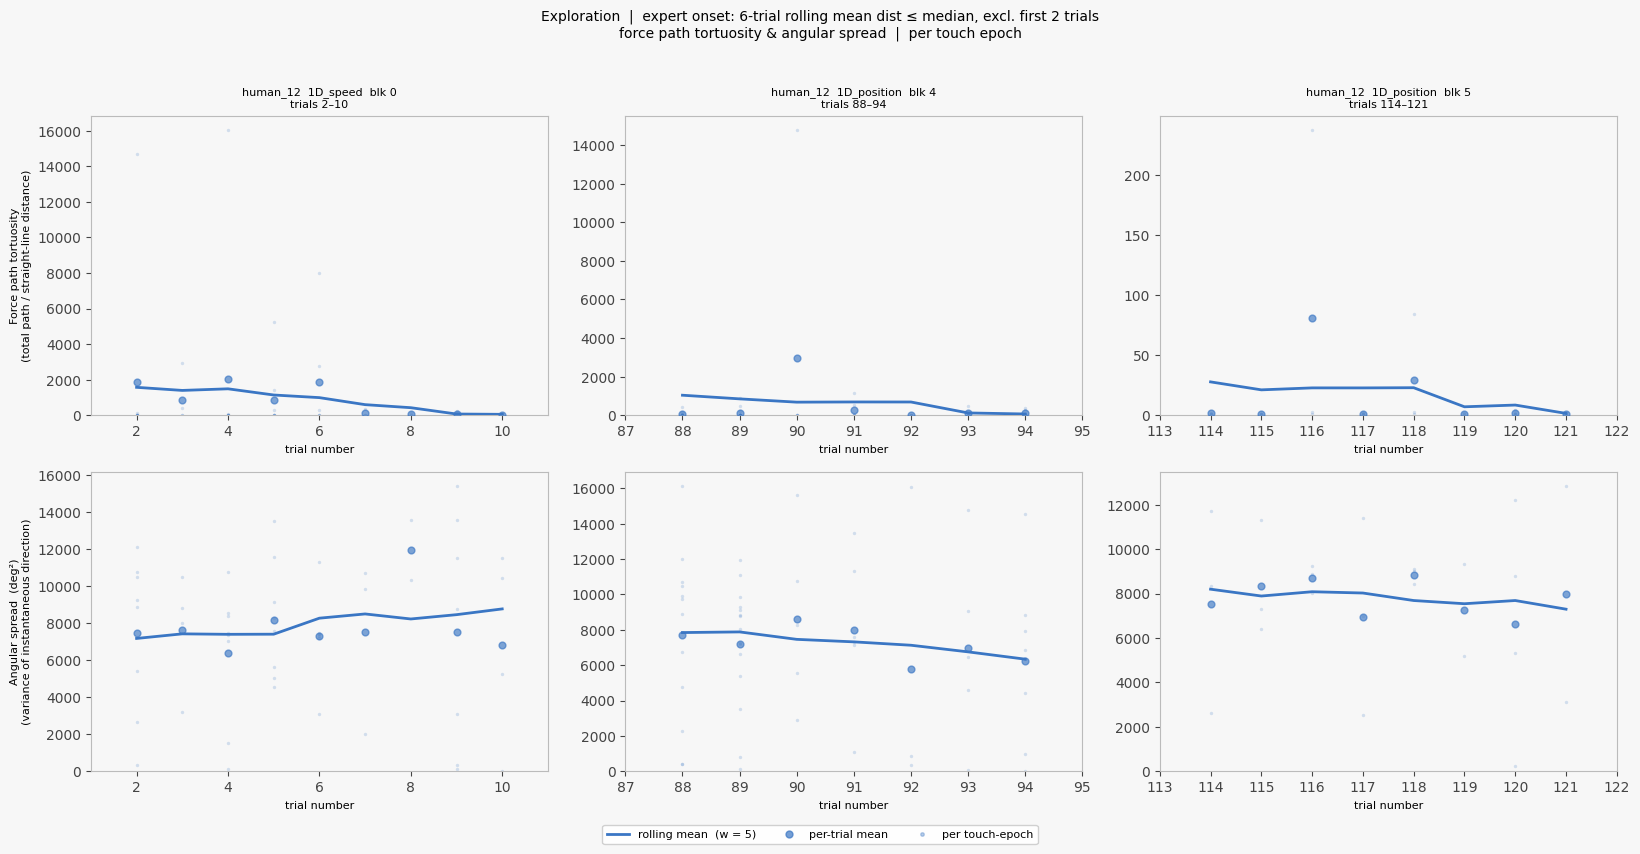

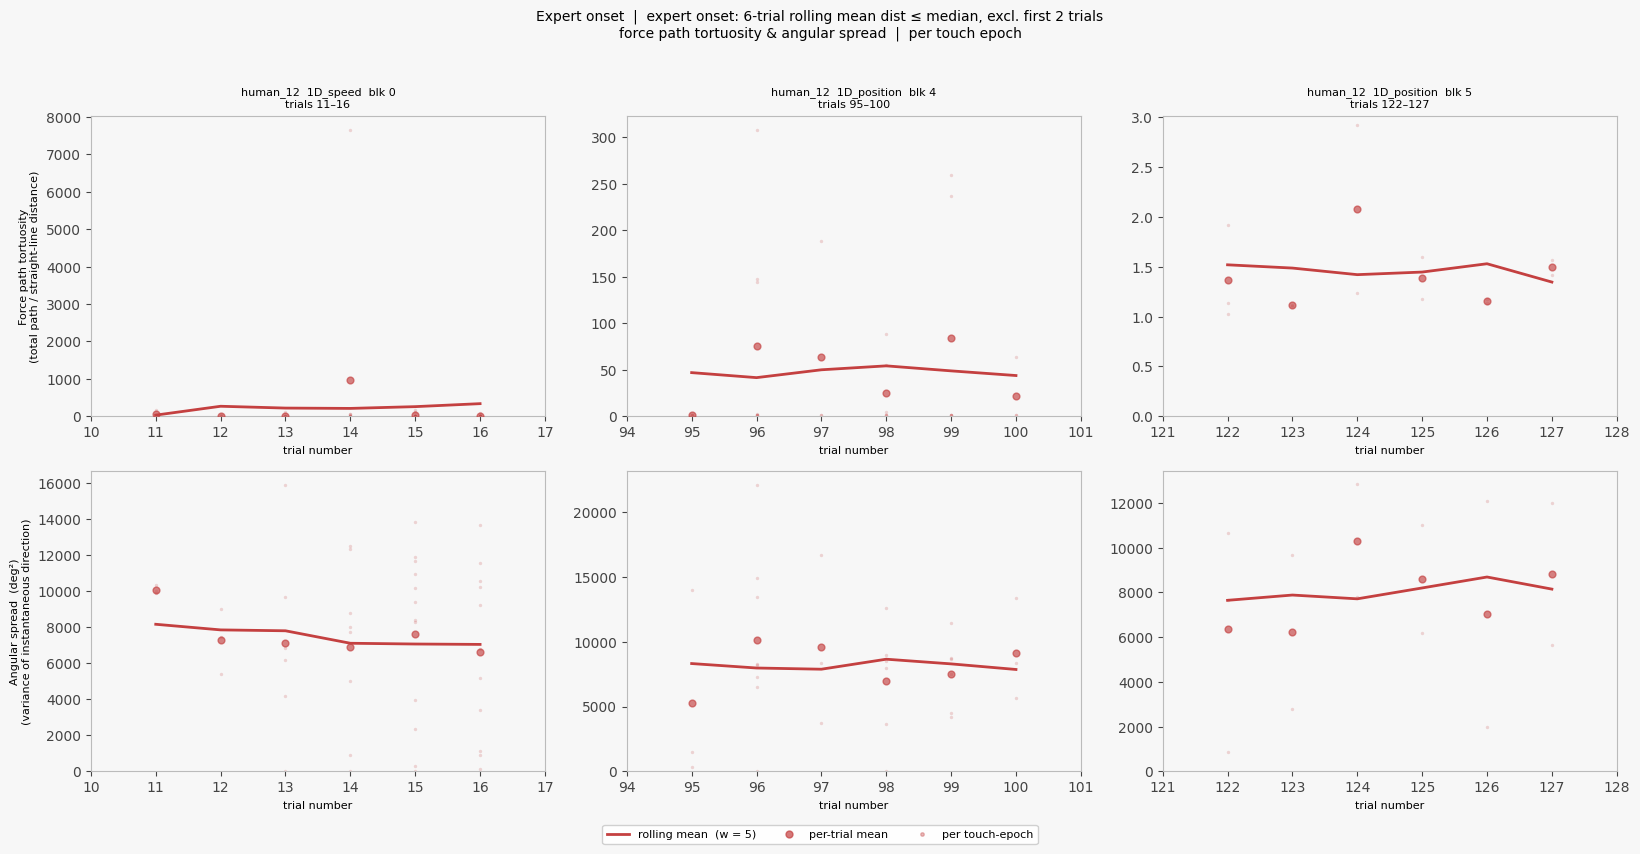

In [48]:
# =============================================================================
# Tortuosity & angular spread — exploration vs expert-onset windows
#
# Expert-onset detection replicates cell 45:
#   6-trial strict rolling mean of dist-from-target <= global median → expert
#   First 2 trials always excluded from expert windows.
#   First expert section = expert-onset window.
#   Exploration window   = trials 3 .. (first_expert_trial - 1)
#
# Two figures produced (identical structure):
#   Figure 1 — exploration window (blue)
#   Figure 2 — expert-onset window (red)
#   Each figure: N_metrics rows × N_detected_blocks columns
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# ── parameters (keep consistent with cells 45 and 50) ────────────────────────
subject_ids    = ['human_12']
session        = 0
feedback_types = None     # None = all blocks; or e.g. ['1D_speed', '2D_speed']
touch_param_id = 0
sat_param_id   = 0
expert_window  = 6        # rolling window for expert detection (trials)
smooth_window  = 30       # force-trace smoothing (samples)
rolling_window = 5        # rolling mean for figures (trials)

C_EXPL   = '#3A76C4'      # blue  — exploration
C_EXPERT = '#C44040'      # red   — expert onset
BG       = '#f7f7f7'

# ── helpers ──────────────────────────────────────────────────────────────────
def get_session(sid):
    return session if isinstance(session, int) else session[sid]

def lut_target(subject_id, sess, task_setting_id, fb_type):
    """Return (tgt_f0, tgt_f1, max_fmag, modality) from the Gaussian LUT peak."""
    modality = 'position' if 'position' in fb_type else 'speed'
    task_key = {'subject_id': subject_id, 'session': sess,
                'task_setting_id': task_setting_id}
    lut = (experiment.TaskSettings & task_key).fetch1('target_force_lut')
    ax_idxs, ax_arrays = (
        experiment.TaskSettings.ForceAxis & task_key
    ).fetch('force_axis_idx', 'target_force_axes', order_by='force_axis_idx')
    fa = {int(i): v for i, v in zip(ax_idxs, ax_arrays)}
    peak_i, peak_j = np.unravel_index(np.nanargmax(lut), lut.shape)
    tgt_f0 = float(fa[0][peak_i])
    tgt_f1 = float(fa[1][peak_j])
    return tgt_f0, tgt_f1, float(np.sqrt(tgt_f0**2 + tgt_f1**2)), modality

def rolling_mean_strict(arr, w):
    """Full-window rolling mean; NaN for first w-1 positions."""
    out = np.full(len(arr), np.nan)
    for i in range(w - 1, len(arr)):
        out[i] = arr[i - w + 1: i + 1].mean()
    return out

def find_runs(bool_arr):
    """Contiguous True runs → list of (start_idx, end_idx)."""
    runs, in_run, start = [], False, 0
    for i, v in enumerate(bool_arr):
        if v and not in_run:
            start, in_run = i, True
        elif not v and in_run:
            runs.append((start, i - 1))
            in_run = False
    if in_run:
        runs.append((start, len(bool_arr) - 1))
    return runs

def rolling_mean_centred(arr, w):
    out = np.full_like(arr, np.nan, dtype=float)
    for i in range(len(arr)):
        lo, hi = max(0, i - w // 2), min(len(arr), i + w // 2 + 1)
        v = arr[lo:hi][~np.isnan(arr[lo:hi])]
        if len(v):
            out[i] = v.mean()
    return out

def path_tortuosity(f0_seg, f1_seg):
    if len(f0_seg) < 2:
        return np.nan
    path = np.sum(np.sqrt(np.diff(f0_seg)**2 + np.diff(f1_seg)**2))
    line = np.sqrt((f0_seg[-1] - f0_seg[0])**2 + (f1_seg[-1] - f1_seg[0])**2)
    return path / line if line > 1e-9 else np.nan

def fetch_epoch_metrics_list(subject_id, sess, block, trial_list):
    """
    Per-touch-epoch tortuosity and angular spread for an explicit trial list.
    Returns list of dicts: {trial, tortuosity, ang_spread (deg²)}.
    """
    sw = smooth_window
    force_base = (experiment.TrialForceTrace.TrialForceAxis() *
                  experiment.BehaviorTrial() * experiment.Block())
    recs = []
    for tr in trial_list:
        fkey = {'subject_id': subject_id, 'session': sess,
                'block': block, 'trial': int(tr)}
        try:
            f0r = (force_base & {**fkey, 'force_axis_idx': 0}).fetch1('force_trace_value')
            f1r = (force_base & {**fkey, 'force_axis_idx': 1}).fetch1('force_trace_value')
            tcs = (experiment.TrialForceTrace() * experiment.BehaviorTrial() *
                   experiment.Block() & fkey).fetch('force_trace_time')
            dt  = float(np.median(np.diff(np.concatenate(tcs))))
        except Exception:
            continue
        f0s = np.convolve(f0r, np.ones(sw) / sw, mode='valid')
        f1s = np.convolve(f1r, np.ones(sw) / sw, mode='valid')
        ts  = np.convolve(np.arange(len(f0r)) * dt, np.ones(sw) / sw, mode='valid')

        ep_q = (behavior_analysis.TrialTouchTimes.TouchEpoch &
                {'subject_id': subject_id, 'session': sess, 'trial': int(tr),
                 'sat_param_id': sat_param_id, 'touch_param_id': touch_param_id,
                 'is_touch': True})
        if not len(ep_q):
            continue
        ep_st, ep_en = ep_q.fetch('start_time', 'end_time', order_by='epoch_idx')

        for st, en in zip(ep_st, ep_en):
            mask = (ts >= float(st)) & (ts <= float(en))
            if mask.sum() < 3:
                continue
            f0e, f1e = f0s[mask], f1s[mask]
            tort    = path_tortuosity(f0e, f1e)
            ang     = np.degrees(np.arctan2(np.diff(f1e), np.diff(f0e)))
            ang_var = float(np.var(ang)) if len(ang) >= 2 else np.nan
            recs.append(dict(trial=int(tr), tortuosity=tort, ang_spread=ang_var))
    return recs

# ── expert detection + metric collection ─────────────────────────────────────
print('Running expert-onset detection and collecting epoch metrics…')
block_results = []

for subject_id in subject_ids:
    sess     = get_session(subject_id)
    base_key = {'subject_id': subject_id, 'session': sess}

    blk_query = experiment.Block & base_key
    if feedback_types is not None:
        blk_query = blk_query & [{'feedback_type': ft} for ft in feedback_types]
    block_nums, fb_types_arr, task_ids = blk_query.fetch(
        'block', 'feedback_type', 'task_setting_id', order_by='block'
    )

    for block, fb_type, task_id in zip(block_nums.tolist(),
                                       fb_types_arr.tolist(),
                                       task_ids.tolist()):
        blk_key = {**base_key, 'block': int(block)}
        trials  = (experiment.BehaviorTrial & blk_key).fetch('trial', order_by='trial')
        if len(trials) < expert_window + 3:
            continue

        # dist-from-target per trial (cell 45 logic) --------------------------
        try:
            tgt_f0, tgt_f1, _, _ = lut_target(subject_id, sess, task_id, fb_type)
        except Exception as e:
            print(f'  {subject_id}  blk {block}: lut_target failed — {e}')
            continue

        dist_by_trial = {}
        for trial in trials:
            tint      = int(trial)
            exp_key   = {**blk_key, 'trial': tint}
            touch_key = {**exp_key, 'touch_param_id': touch_param_id,
                         'sat_param_id': sat_param_id}
            ft_rows = experiment.TrialForceTrace & exp_key
            if len(ft_rows) == 0:
                continue
            ftt = ft_rows.fetch1('force_trace_time')
            if len(ftt) == 0:
                continue
            ax_idx, ax_val = (
                experiment.TrialForceTrace.TrialForceAxis & exp_key & 'force_axis_idx < 2'
            ).fetch('force_axis_idx', 'force_trace_value', order_by='force_axis_idx')
            if len(ax_val) < 2:
                continue
            f_raw = {int(i): v for i, v in zip(ax_idx, ax_val)}
            ep_st_d, ep_en_d = (
                behavior_analysis.TrialTouchTimes.TouchEpoch &
                touch_key & {'is_touch': True}
            ).fetch('start_time', 'end_time')
            touch_mask = np.zeros(len(ftt), dtype=bool)
            for st, en in zip(ep_st_d, ep_en_d):
                touch_mask |= (ftt >= float(st)) & (ftt <= float(en))
            if not touch_mask.any():
                continue
            dist_all = np.sqrt((f_raw[0] - tgt_f0)**2 + (f_raw[1] - tgt_f1)**2)
            dist_by_trial[tint] = float(np.nanmean(dist_all[touch_mask]))

        # expert section detection (exact cell 45 algorithm) ------------------
        dist_arr   = np.array([dist_by_trial.get(int(t), np.nan) for t in trials],
                               dtype=float)
        has_dist   = ~np.isnan(dist_arr)
        rew_trials = [int(t) for t, m in zip(trials, has_dist) if m]
        dist_rew   = dist_arr[has_dist]

        expert_sections = []
        if len(rew_trials) >= expert_window:
            roll_d = rolling_mean_strict(dist_rew, expert_window)
            med_d  = np.nanmedian(roll_d)
            is_low = (roll_d <= med_d) & ~np.isnan(roll_d)
            is_low[:2 + expert_window - 1] = False      # exclude first 2 trials
            for run_s, _ in find_runs(is_low):
                first_t = rew_trials[run_s - expert_window + 1]
                last_t  = rew_trials[run_s]
                expert_sections.append((first_t, last_t))

        if not expert_sections:
            print(f'  {subject_id}  {fb_type}  blk {block}: no expert section found — skipping')
            continue

        first_t_exp, last_t_exp = expert_sections[0]
        all_t = [int(t) for t in trials]
        try:
            idx_onset = all_t.index(first_t_exp)
        except ValueError:
            continue

        expl_trials   = all_t[2:idx_onset]                      # after first 2, before onset
        expert_trials = list(range(first_t_exp, last_t_exp + 1))

        if len(expl_trials) < 2:
            print(f'  {subject_id}  {fb_type}  blk {block}: too few exploration trials — skipping')
            continue

        print(f'  {subject_id}  {fb_type}  blk {int(block)}  '
              f'exploration={expl_trials[0]}–{expl_trials[-1]} (n={len(expl_trials)})  '
              f'expert_onset={first_t_exp}–{last_t_exp}')

        expl_recs   = fetch_epoch_metrics_list(subject_id, sess, int(block), expl_trials)
        expert_recs = fetch_epoch_metrics_list(subject_id, sess, int(block), expert_trials)

        block_results.append(dict(
            subject_id=subject_id, block=int(block), fb_type=fb_type,
            expl_trials=expl_trials,   expert_trials=expert_trials,
            expl_recs=expl_recs,       expert_recs=expert_recs,
        ))

print(f'\nDone. {len(block_results)} block(s) with detected expert onset.')

# ── figures ───────────────────────────────────────────────────────────────────
METRICS = [
    ('tortuosity', 'Force path tortuosity\n(total path / straight-line distance)'),
    ('ang_spread', 'Angular spread  (deg²)\n(variance of instantaneous direction)'),
]
SECTIONS = [
    ('Exploration',  'expl_recs',
     lambda br: f"trials {br['expl_trials'][0]}–{br['expl_trials'][-1]}",
     C_EXPL),
    ('Expert onset', 'expert_recs',
     lambda br: f"trials {br['expert_trials'][0]}–{br['expert_trials'][-1]}",
     C_EXPERT),
]

if not block_results:
    print('Nothing to plot.')
else:
    n_blks = len(block_results)

    for sec_name, recs_key, trial_label_fn, sec_col in SECTIONS:
        fig, axes = plt.subplots(len(METRICS), n_blks,
                                 figsize=(5.5 * n_blks, 4 * len(METRICS)),
                                 squeeze=False)
        fig.patch.set_facecolor(BG)

        for ci, br in enumerate(block_results):
            recs = br[recs_key]

            for row, (mkey, mlabel) in enumerate(METRICS):
                ax = axes[row, ci]
                ax.set_facecolor(BG)
                for sp in ax.spines.values():
                    sp.set_edgecolor('#bbb')
                ax.tick_params(colors='#444')

                if row == 0:
                    ax.set_title(
                        f"{br['subject_id']}  {br['fb_type']}  blk {br['block']}\n"
                        f"{trial_label_fn(br)}",
                        fontsize=8
                    )

                if not recs:
                    ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                            transform=ax.transAxes, color='#aaa', fontsize=9)
                    continue

                t_arr = np.array([r['trial'] for r in recs], dtype=float)
                v_arr = np.array([r[mkey]    for r in recs], dtype=float)
                good  = ~np.isnan(v_arr)
                if not good.any():
                    ax.text(0.5, 0.5, 'all NaN', ha='center', va='center',
                            transform=ax.transAxes, color='#aaa', fontsize=9)
                    continue

                ax.scatter(t_arr[good], v_arr[good], color=sec_col,
                           s=6, alpha=0.2, linewidths=0, zorder=2)

                ur = sorted(set(int(t) for t in t_arr[good]))
                tm = np.array([np.nanmean(v_arr[t_arr == t]) for t in ur])
                rm = rolling_mean_centred(tm, rolling_window)
                ax.scatter(ur, tm, color=sec_col, s=24, alpha=0.65, zorder=3)
                ax.plot(ur, rm, color=sec_col, lw=2.0, zorder=4)

                ax.set_xlabel('trial number', fontsize=8)
                ax.set_xlim(min(ur) - 1, max(ur) + 1)
                ax.set_ylim(bottom=0)
                if ci == 0:
                    ax.set_ylabel(mlabel, fontsize=8)

        hl = [
            mlines.Line2D([], [], color=sec_col, lw=2,
                          label=f'rolling mean  (w = {rolling_window})'),
            mlines.Line2D([], [], color=sec_col, lw=0, marker='o', markersize=5,
                          alpha=0.7, label='per-trial mean'),
            mlines.Line2D([], [], color=sec_col, lw=0, marker='.', markersize=5,
                          alpha=0.35, label='per touch-epoch'),
        ]
        fig.legend(handles=hl, loc='lower center', ncol=3, fontsize=8,
                   bbox_to_anchor=(0.5, -0.03), framealpha=0.9)
        fig.suptitle(
            f'{sec_name}  |  expert onset: {expert_window}-trial rolling mean '
            f'dist ≤ median, excl. first 2 trials\n'
            'force path tortuosity & angular spread  |  per touch epoch',
            fontsize=10, y=1.02
        )
        fig.tight_layout()
        plt.show()


  human_2  blk 0: 5 exploration trials
  human_2  blk 1: 5 exploration trials
  human_2  blk 2: 3 exploration trials
  human_2  blk 5: 3 exploration trials
  human_3  blk 0: 3 exploration trials
  human_3  blk 1: 3 exploration trials
  human_3  blk 4: 3 exploration trials
  human_4  blk 1: 3 exploration trials
  human_4  blk 2: 7 exploration trials
  human_4  blk 5: 4 exploration trials
  human_5  blk 0: 8 exploration trials
  human_5  blk 1: 2 exploration trials
  human_5  blk 3: 4 exploration trials
  human_5  blk 4: 3 exploration trials
  human_5  blk 5: 1 exploration trials
  human_6  blk 0: 8 exploration trials
  human_6  blk 1: 6 exploration trials
  human_6  blk 2: 5 exploration trials
  human_7  blk 0: 6 exploration trials
  human_7  blk 3: 4 exploration trials
  human_8  blk 1: 8 exploration trials
  human_8  blk 3: 1 exploration trials
  human_9  blk 0: 4 exploration trials
  human_10  blk 1: 6 exploration trials
  human_10  blk 2: 4 exploration trials
  human_10  blk 3: 3 ex

C:\Users\labadmin\AppData\Local\Temp\ipykernel_6396\3086849713.py:235: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap       = plt.cm.get_cmap('tab20', max(len(uniq_subjs), 1))


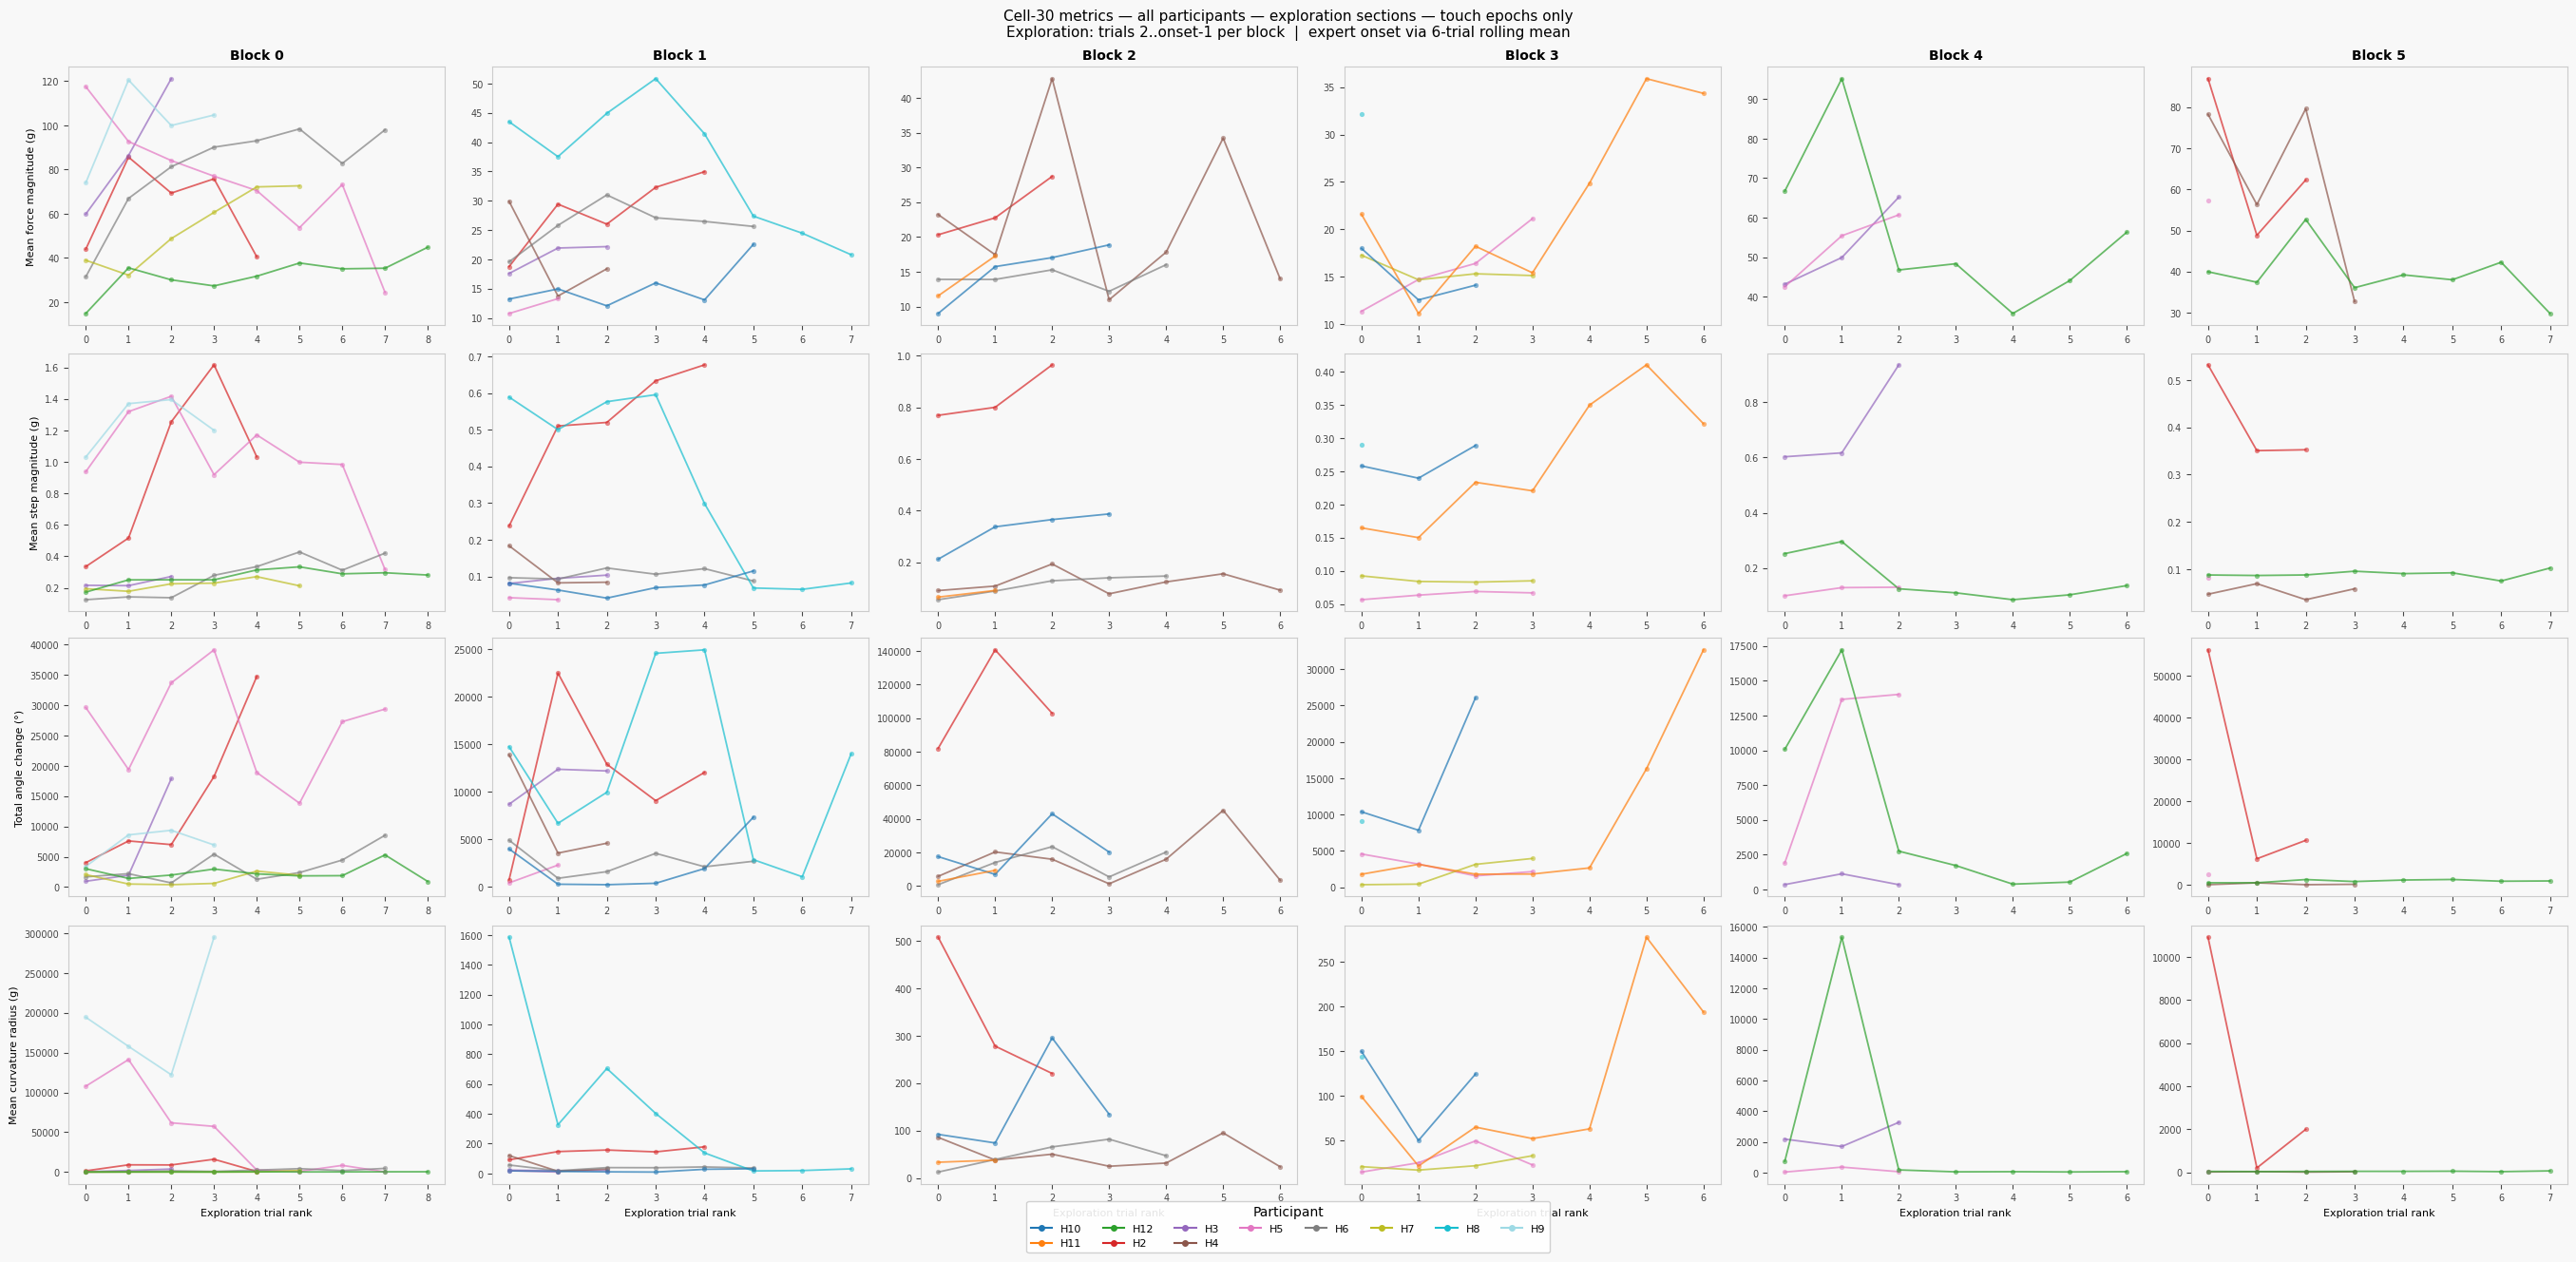

In [19]:
# ── Cell-30 metrics across all participants — exploration sections, by block ──
# For each participant × block, detect the exploration section (trials after the
# first two, up to but not including the first expert-onset window), then fetch
# smoothed force traces, restrict to touch epochs, and compute:
#   mean_fmag  — mean force magnitude  sqrt(f0² + f1²)
#   mean_step  — mean step magnitude   (velocity proxy)
#   ang_total  — total angular change  of force direction (°)
#   mean_curv  — mean Menger curvature radius
# Expert onset: same rolling-mean algorithm as cell 45.
# Figure: 4 metrics × N_blocks columns — all participants overlaid per subplot.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# ── parameters ───────────────────────────────────────────────────────────────
subject_ids    = [f'human_{i}' for i in range(1, 13)]   # human_1 … human_12
session        = 0
feedback_types = None          # None = all blocks; e.g. ['2D_speed'] to filter
touch_param_id = 0
sat_param_id   = 0
smooth_window  = 30            # boxcar half-width (samples)
expert_window  = 6             # rolling-mean window for onset detection
menger_hw      = 5             # half-window for Menger curvature
exclude_blocks = [6]           # blocks to skip entirely

# ── helpers ──────────────────────────────────────────────────────────────────
def _get_sess(sid):
    return session if isinstance(session, int) else session[sid]

def _lut_target(subject_id, sess, task_id, fb_type):
    task_key = {'subject_id': subject_id, 'session': sess,
                'task_setting_id': task_id}
    lut = (experiment.TaskSettings & task_key).fetch1('target_force_lut')
    ax_idx, ax_val = (
        experiment.TaskSettings.ForceAxis & task_key
    ).fetch('force_axis_idx', 'target_force_axes', order_by='force_axis_idx')
    fa = {int(i): v for i, v in zip(ax_idx, ax_val)}
    pi, pj = np.unravel_index(np.nanargmax(lut), lut.shape)
    return float(fa[0][pi]), float(fa[1][pj])

def _rolling_mean(arr, w):
    out = np.full(len(arr), np.nan)
    for i in range(w - 1, len(arr)):
        out[i] = arr[i - w + 1 : i + 1].mean()
    return out

def _find_runs(bool_arr):
    runs, in_run, start = [], False, 0
    for i, v in enumerate(bool_arr):
        if v and not in_run:
            start, in_run = i, True
        elif not v and in_run:
            runs.append((start, i - 1))
            in_run = False
    if in_run:
        runs.append((start, len(bool_arr) - 1))
    return runs

def _menger_curv(x, y, hw):
    n = len(x)
    radius = np.full(n, np.inf)
    for i in range(hw, n - hw):
        x1, y1 = x[i - hw], y[i - hw]
        x2, y2 = x[i],      y[i]
        x3, y3 = x[i + hw], y[i + hw]
        a    = np.hypot(x2 - x1, y2 - y1)
        b    = np.hypot(x3 - x2, y3 - y2)
        c    = np.hypot(x3 - x1, y3 - y1)
        area = abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1)) / 2
        if area > 1e-12:
            radius[i] = (a * b * c) / (4 * area)
    return radius

# ── data collection ──────────────────────────────────────────────────────────
# all_block_results[block][subject_id] = [
#     {rank, mean_fmag, mean_step, ang_total, mean_curv}, ...  one per expl. trial
# ]
all_block_results = {}
sw = smooth_window

for subject_id in subject_ids:
    sess     = _get_sess(subject_id)
    base_key = {'subject_id': subject_id, 'session': sess}

    blk_q = experiment.Block & base_key
    if feedback_types is not None:
        blk_q = blk_q & [{'feedback_type': ft} for ft in feedback_types]
    blk_nums, fb_types_arr, task_ids = blk_q.fetch(
        'block', 'feedback_type', 'task_setting_id', order_by='block')

    for block, fb_type, task_id in zip(blk_nums.tolist(),
                                        fb_types_arr.tolist(),
                                        task_ids.tolist()):
        blk_key = {**base_key, 'block': block}
        if int(block) in exclude_blocks:
            continue
        trials  = (experiment.BehaviorTrial & blk_key).fetch('trial', order_by='trial')
        if not len(trials):
            continue

        try:
            tgt_f0, tgt_f1 = _lut_target(subject_id, sess, task_id, fb_type)
        except Exception as e:
            print(f'  {subject_id} blk {block}: {e}')
            continue

        dist_by_trial  = {}   # tint -> mean dist-from-LUT in touch epochs (raw)
        stats_by_trial = {}   # tint -> {mean_fmag, mean_step, ang_total, mean_curv}

        for trial in trials:
            tint    = int(trial)
            exp_key = {**blk_key, 'trial': tint}
            t_key   = {**exp_key,
                       'touch_param_id': touch_param_id,
                       'sat_param_id':   sat_param_id}

            ft_rows = experiment.TrialForceTrace & exp_key
            if not len(ft_rows):
                continue
            ftt = ft_rows.fetch1('force_trace_time')
            if len(ftt) < sw:
                continue

            ax_idx, ax_val = (
                experiment.TrialForceTrace.TrialForceAxis & exp_key
                & 'force_axis_idx < 2'
            ).fetch('force_axis_idx', 'force_trace_value', order_by='force_axis_idx')
            if len(ax_val) < 2:
                continue
            f_raw    = {int(i): v for i, v in zip(ax_idx, ax_val)}
            f0r, f1r = f_raw[0], f_raw[1]

            ep_q = (behavior_analysis.TrialTouchTimes.TouchEpoch
                    & t_key & {'is_touch': True})
            if not len(ep_q):
                continue
            ep_st, ep_en = ep_q.fetch('start_time', 'end_time')

            # raw-time touch mask (for dist-from-target)
            tmask_raw = np.zeros(len(ftt), dtype=bool)
            for st, en in zip(ep_st, ep_en):
                tmask_raw |= (ftt >= float(st)) & (ftt <= float(en))
            if not tmask_raw.any():
                continue

            dist_all = np.sqrt((f0r - tgt_f0)**2 + (f1r - tgt_f1)**2)
            dist_by_trial[tint] = float(np.mean(dist_all[tmask_raw]))

            # smoothed traces for cell-30 metrics
            f0s = np.convolve(f0r, np.ones(sw) / sw, mode='valid')
            f1s = np.convolve(f1r, np.ones(sw) / sw, mode='valid')
            ts  = np.convolve(ftt, np.ones(sw) / sw, mode='valid')

            tmask_s = np.zeros(len(ts), dtype=bool)
            for st, en in zip(ep_st, ep_en):
                tmask_s |= (ts >= float(st)) & (ts <= float(en))
            if not tmask_s.any():
                continue

            fmag = np.sqrt(f0s**2 + f1s**2)
            step = np.sqrt(np.diff(f0s)**2 + np.diff(f1s)**2)
            ang  = np.degrees(np.arctan2(f1s, f0s))          # force direction
            curv = _menger_curv(f0s, f1s, menger_hw)

            mf = float(np.mean(fmag[tmask_s]))

            td = tmask_s[:-1]
            ms = float(np.mean(step[td])) if td.any() else np.nan

            ang_te = ang[tmask_s]
            at = float(np.sum(np.abs(np.diff(ang_te)))) if len(ang_te) > 1 else np.nan

            cr = curv[tmask_s]
            cr_fin = cr[np.isfinite(cr)]
            mc = float(np.mean(cr_fin)) if len(cr_fin) else np.nan

            stats_by_trial[tint] = dict(mean_fmag=mf, mean_step=ms,
                                        ang_total=at, mean_curv=mc)

        # ── expert-onset detection ──────────────────────────────────────────
        dist_arr   = np.array([dist_by_trial.get(int(t), np.nan) for t in trials],
                               dtype=float)
        has_dist   = ~np.isnan(dist_arr)
        rew_trials = [int(t) for t, m in zip(trials, has_dist) if m]
        dist_rew   = dist_arr[has_dist]

        expl_trials = []
        if len(rew_trials) >= expert_window:
            roll  = _rolling_mean(dist_rew, expert_window)
            med   = np.nanmedian(roll)
            is_low = (roll <= med) & ~np.isnan(roll)
            is_low[:2 + expert_window - 1] = False
            runs  = _find_runs(is_low)
            if runs:
                first_expert = rew_trials[runs[0][0] - expert_window + 1]
                try:
                    idx_onset  = rew_trials.index(first_expert)
                    expl_trials = rew_trials[2:idx_onset]   # skip first 2 trials
                except ValueError:
                    pass

        if not expl_trials:
            continue

        records = [dict(rank=rank, **stats_by_trial[tint])
                   for rank, tint in enumerate(expl_trials)
                   if tint in stats_by_trial]
        if not records:
            continue

        blk = int(block)
        all_block_results.setdefault(blk, {})[subject_id] = records
        print(f'  {subject_id}  blk {blk}: {len(records)} exploration trials')

print('Data collection done.')

# ── plotting ──────────────────────────────────────────────────────────────────
if not all_block_results:
    print('No exploration data found.')
else:
    METRICS = [
        ('mean_fmag', 'Mean force magnitude (g)'),
        ('mean_step', 'Mean step magnitude (g)'),
        ('ang_total', 'Total angle change (°)'),
        ('mean_curv', 'Mean curvature radius (g)'),
    ]

    all_blocks = sorted(all_block_results.keys())
    n_blks     = len(all_blocks)
    n_met      = len(METRICS)

    uniq_subjs = sorted({sid for bd in all_block_results.values() for sid in bd})
    cmap       = plt.cm.get_cmap('tab20', max(len(uniq_subjs), 1))
    subj_color = {s: cmap(i) for i, s in enumerate(uniq_subjs)}

    fig, axes = plt.subplots(n_met, n_blks,
                              figsize=(4.5 * n_blks, 3.2 * n_met),
                              squeeze=False, constrained_layout=True)
    fig.patch.set_facecolor('#f8f8f8')

    for col, blk in enumerate(all_blocks):
        bd = all_block_results[blk]
        for row, (mkey, mlabel) in enumerate(METRICS):
            ax = axes[row, col]
            ax.set_facecolor('#f8f8f8')
            for sp in ax.spines.values():
                sp.set_edgecolor('#ccc')
            ax.tick_params(colors='#444', labelsize=7)

            if row == 0:
                ax.set_title(f'Block {blk}', fontsize=10, fontweight='bold')
            if col == 0:
                ax.set_ylabel(mlabel, fontsize=8)
            if row == n_met - 1:
                ax.set_xlabel('Exploration trial rank', fontsize=8)

            for subj, recs in bd.items():
                c     = subj_color[subj]
                ranks = np.array([r['rank']  for r in recs], dtype=float)
                vals  = np.array([r[mkey]    for r in recs], dtype=float)
                good  = ~np.isnan(vals)
                if not good.any():
                    continue
                ax.plot(ranks[good], vals[good], color=c, lw=1.3, alpha=0.7, zorder=3)
                ax.scatter(ranks[good], vals[good], color=c, s=14, alpha=0.55,
                           linewidths=0, zorder=4)

    legend_handles = [
        mlines.Line2D([], [], color=subj_color[s], lw=1.5, marker='o',
                      markersize=4, label=s.replace('human_', 'H'))
        for s in uniq_subjs
    ]
    fig.legend(handles=legend_handles, loc='lower center',
               ncol=min(len(uniq_subjs), 8), fontsize=8,
               bbox_to_anchor=(0.5, -0.03), framealpha=0.9, title='Participant')
    fig.suptitle(
        'Cell-30 metrics — all participants — exploration sections — touch epochs only\n'
        'Exploration: trials 2..onset-1 per block  |  expert onset via 6-trial rolling mean',
        fontsize=11,
    )
    plt.show()


Collected TTR data:
  block 0 (1D_speed       ): 11 participants,   1333 trials
  block 1 (2D_speed       ): 11 participants,   1333 trials
  block 4 (1D_position    ): 10 participants,   1271 trials
  block 5 (2D_position    ):  9 participants,   1203 trials


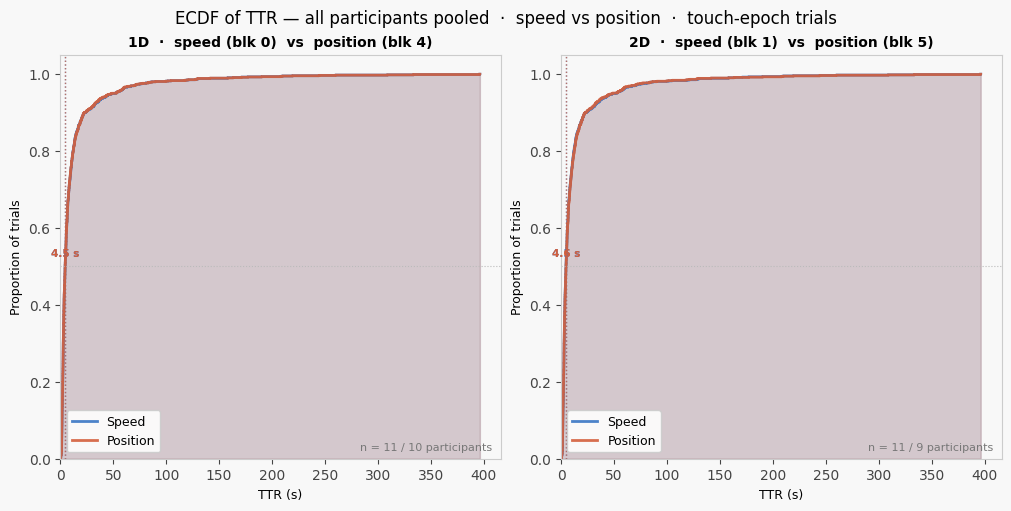

In [40]:
# ── TTR distribution per participant: speed vs position, 1D and 2D ──────────
# 1D_speed = block 0   |  2D_speed = block 1
# 1D_position = block 4  |  2D_position = block 5
# Box plots (IQR + median) with individual trial dots overlaid.
# Only touch-epoch trials (first_touch_time not None) and rewarded trials.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt

# ── parameters ───────────────────────────────────────────────────────────────
subject_ids    = [f'human_{i}' for i in range(1, 13)]
session        = 0
touch_param_id = 0
sat_param_id   = 0
y_max          = None     # set e.g. 60 to cap y-axis; None = auto

BLOCK_MAP = {0: '1D_speed', 1: '2D_speed', 4: '1D_position', 5: '2D_position'}
PAIRS     = [('1D', 0, 4), ('2D', 1, 5)]   # (label, speed_block, position_block)
C_SPD     = '#3A76C4'
C_POS     = '#D45F3C'

# ── data collection ──────────────────────────────────────────────────────────
# ttr_data[(subject_id, block)] = np.array of TTR values (touch-epoch, rewarded)
ttr_data = {}

for subject_id in subject_ids:
    base_key = {'subject_id': subject_id, 'session': session}
    blk_q    = experiment.Block & base_key
    if not len(blk_q):
        continue

    for block in blk_q.fetch('block', order_by='block').tolist():
        blk_num = int(block)
        if blk_num not in BLOCK_MAP:
            continue

        det_key = {'subject_id': subject_id, 'session': session,
                   'block': block,
                   'touch_param_id': touch_param_id,
                   'sat_param_id':   sat_param_id}

        timing_rows = behavior_analysis.TrialTiming & det_key
        if not len(timing_rows):
            continue

        ttrs, ft_times = timing_rows.fetch(
            'time_to_reward', 'first_touch_time', order_by='trial')

        vals = [float(ttr) for ttr, ftt in zip(ttrs, ft_times)
                if ttr is not None and ftt is not None]
        if vals:
            ttr_data[(subject_id, blk_num)] = np.array(vals, dtype=float)

# ── diagnostic summary ───────────────────────────────────────────────────────
print('Collected TTR data:')
for blk, label in sorted(BLOCK_MAP.items()):
    n_s = sum(1 for (s, b) in ttr_data if b == blk)
    n_t = sum(len(v) for (s, b), v in ttr_data.items() if b == blk)
    print(f'  block {blk} ({label:15s}): {n_s:2d} participants,  {n_t:5d} trials')

# ── plotting ──────────────────────────────────────────────────────────────────
uniq_subjs = sorted(
    {s for (s, _) in ttr_data},
    key=lambda s: int(s.split('_')[1])
)

def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

if not uniq_subjs:
    print('No TTR data found.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
    fig.patch.set_facecolor('#f8f8f8')

    for col_idx, (dim, blk_spd, blk_pos) in enumerate(PAIRS):
        ax = axes[col_idx]
        ax.set_facecolor('#f8f8f8')
        for sp in ax.spines.values():
            sp.set_edgecolor('#ccc')
        ax.tick_params(colors='#444')

        for blk, col, label in [
            (blk_spd, C_SPD, 'Speed'),
            (blk_pos, C_POS, 'Position'),
        ]:
            arrs = [ttr_data[(s, blk)] for s in uniq_subjs if (s, blk) in ttr_data]
            d    = np.concatenate(arrs) if arrs else np.array([])
            if len(d) < 2:
                print(f'  WARNING: no data for {dim} {label} (block {blk})')
                continue

            x, y = ecdf(d)
            ax.fill_between(x, 0, y, step='post', color=col, alpha=0.18)
            ax.step(x, y, color=col, lw=2, where='post', label=label, alpha=0.9)

            med = float(np.median(d))
            ax.axvline(med, color=col, lw=1, linestyle=':', alpha=0.7)
            ax.text(med, 0.52, f'{med:.1f} s',
                    ha='center', va='bottom', fontsize=7.5,
                    color=col, fontweight='bold')

        ax.set_xlabel('TTR (s)', fontsize=9)
        ax.set_ylabel('Proportion of trials', fontsize=9)
        ax.set_xlim(left=0)
        if y_max is not None:
            ax.set_xlim(0, y_max)
        ax.set_ylim(0, 1.05)
        ax.axhline(0.5, color='#bbb', lw=0.8, linestyle=':')
        ax.set_title(
            f'{dim}  ·  speed (blk {blk_spd})  vs  position (blk {blk_pos})',
            fontsize=10, fontweight='bold',
        )
        n_spd = sum(1 for s in uniq_subjs if (s, blk_spd) in ttr_data)
        n_pos = sum(1 for s in uniq_subjs if (s, blk_pos) in ttr_data)
        ax.text(0.98, 0.02, f'n = {n_spd} / {n_pos} participants',
                transform=ax.transAxes, ha='right', fontsize=8, color='#777')
        ax.legend(fontsize=9, framealpha=0.9)

    fig.suptitle(
        'ECDF of TTR — all participants pooled  ·  speed vs position  ·  touch-epoch trials',
        fontsize=12,
    )
    plt.show()


Collection done.
  blk 0  1D_speed         expl  :  9 subjects,     39 trials
  blk 0  1D_speed         expert: 11 subjects,     66 trials
  blk 1  2D_speed         expl  :  9 subjects,     41 trials
  blk 1  2D_speed         expert: 11 subjects,     66 trials
  blk 4  1D_position      expl  :  6 subjects,     18 trials
  blk 4  1D_position      expert:  9 subjects,     54 trials
  blk 5  2D_position      expl  :  8 subjects,     43 trials
  blk 5  2D_position      expert:  9 subjects,     54 trials


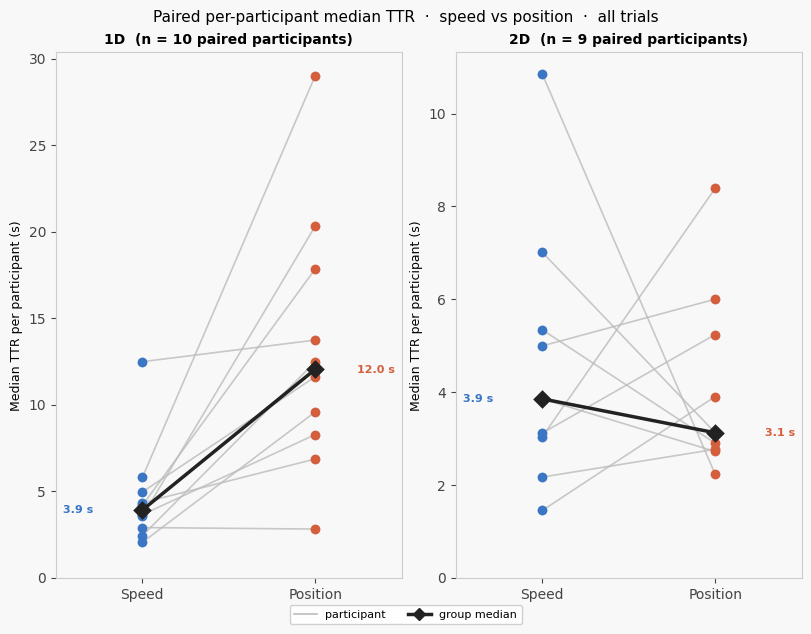

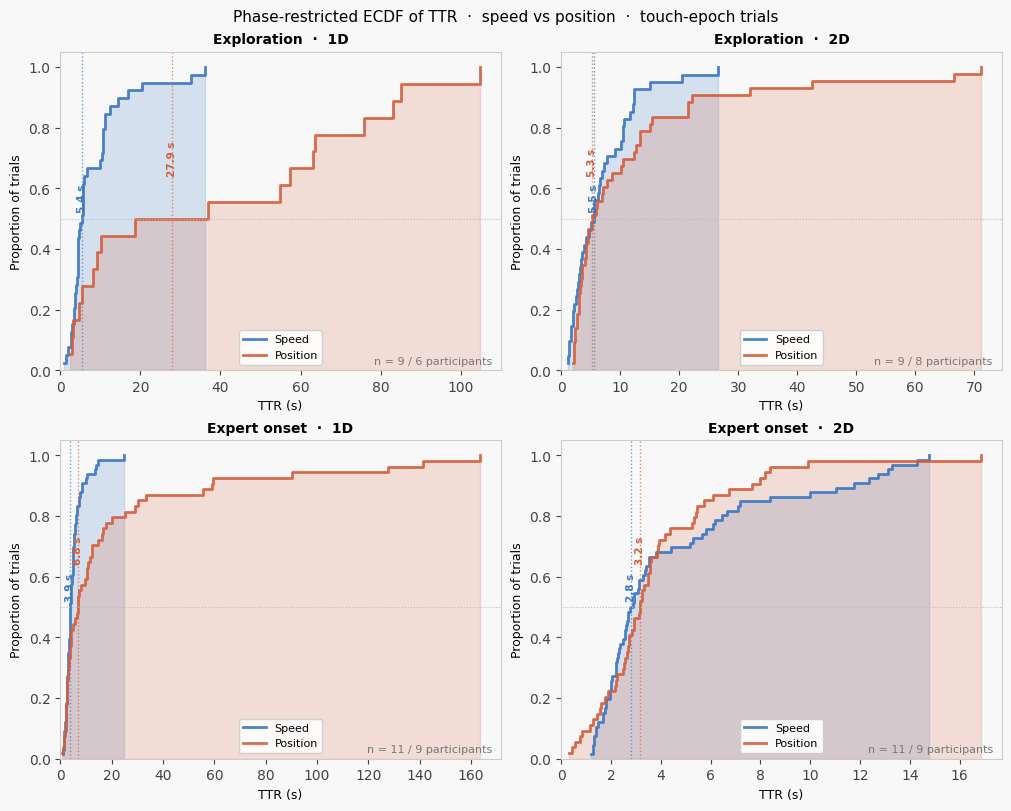

In [41]:
# ── Paired TTR comparison + phase-restricted ECDF ────────────────────────────
# Figure 1: Paired slope graph — per-participant median TTR, speed vs position.
#           Each line = one participant. Thick black line = group median.
# Figure 2: ECDF of TTR restricted to exploration and expert-onset phases.
#
# Phase detection: 6-trial rolling mean of TTR ≤ global median of that series.
#   Same algorithm as cell 45 but uses TTR as the proxy instead of force-distance
#   (avoids re-fetching force traces).
#   Exploration  = rewarded trials 2 .. first-expert-onset - 1
#   Expert onset = first 6-trial window where rolling-mean TTR ≤ global median
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# ── parameters ───────────────────────────────────────────────────────────────
subject_ids    = [f'human_{i}' for i in range(1, 13)]
session        = 0
touch_param_id = 0
sat_param_id   = 0
expert_window  = 6

BLOCK_MAP = {0: '1D_speed', 1: '2D_speed', 4: '1D_position', 5: '2D_position'}
PAIRS     = [('1D', 0, 4), ('2D', 1, 5)]
C_SPD     = '#3A76C4'
C_POS     = '#D45F3C'

# ── helpers ──────────────────────────────────────────────────────────────────
def _roll(arr, w):
    out = np.full(len(arr), np.nan)
    for i in range(w - 1, len(arr)):
        out[i] = arr[i - w + 1 : i + 1].mean()
    return out

def _runs(bool_arr):
    runs, in_run, start = [], False, 0
    for i, v in enumerate(bool_arr):
        if v and not in_run:
            start, in_run = i, True
        elif not v and in_run:
            runs.append((start, i - 1))
            in_run = False
    if in_run:
        runs.append((start, len(bool_arr) - 1))
    return runs

def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

# ── data collection ──────────────────────────────────────────────────────────
# median_ttr[(subj, blk)]           → per-participant median TTR (all trials)
# ttr_phase [(subj, blk, 'expl')]   → TTR array, exploration trials
# ttr_phase [(subj, blk, 'expert')] → TTR array, expert-onset trials
median_ttr = {}
ttr_phase  = {}

for subject_id in subject_ids:
    base_key = {'subject_id': subject_id, 'session': session}
    blk_q    = experiment.Block & base_key
    if not len(blk_q):
        continue

    for block in blk_q.fetch('block', order_by='block').tolist():
        blk_num = int(block)
        if blk_num not in BLOCK_MAP:
            continue

        blk_key = {**base_key, 'block': block}
        det_key = {**blk_key,
                   'touch_param_id': touch_param_id,
                   'sat_param_id':   sat_param_id}

        trials = (experiment.BehaviorTrial & blk_key).fetch('trial', order_by='trial')
        if not len(trials):
            continue

        timing_rows = behavior_analysis.TrialTiming & det_key
        if not len(timing_rows):
            continue

        t_nums, ttrs, ft_times = timing_rows.fetch(
            'trial', 'time_to_reward', 'first_touch_time', order_by='trial')

        rank_of = {int(t): r for r, t in enumerate(trials)}
        ttr_arr = np.full(len(trials), np.nan)
        for t, ttr, ftt in zip(t_nums, ttrs, ft_times):
            if ttr is not None and ftt is not None:
                r = rank_of.get(int(t))
                if r is not None:
                    ttr_arr[r] = float(ttr)

        valid = ttr_arr[~np.isnan(ttr_arr)]
        if not len(valid):
            continue
        median_ttr[(subject_id, blk_num)] = float(np.median(valid))

        # phase detection: rolling mean of TTR ≤ global median → expert
        rew_ranks = np.where(~np.isnan(ttr_arr))[0].tolist()
        ttr_rew   = ttr_arr[rew_ranks]

        ttr_phase[(subject_id, blk_num, 'expl')]   = np.array([])
        ttr_phase[(subject_id, blk_num, 'expert')]  = np.array([])

        if len(rew_ranks) >= expert_window:
            roll   = _roll(ttr_rew, expert_window)
            med    = np.nanmedian(roll)
            is_low = (roll <= med) & ~np.isnan(roll)
            is_low[:2 + expert_window - 1] = False
            rs     = _runs(is_low.tolist())
            if rs:
                run_s    = rs[0][0]
                first_ei = run_s - expert_window + 1
                last_ei  = run_s
                expl_ri   = rew_ranks[2:first_ei]
                expert_ri = rew_ranks[first_ei:last_ei + 1]
                if expl_ri:
                    ttr_phase[(subject_id, blk_num, 'expl')]  = ttr_arr[expl_ri]
                if expert_ri:
                    ttr_phase[(subject_id, blk_num, 'expert')] = ttr_arr[expert_ri]

print('Collection done.')
for blk, lbl in sorted(BLOCK_MAP.items()):
    for ph in ['expl', 'expert']:
        n_s = sum(1 for (s, b, p) in ttr_phase
                  if b == blk and p == ph and len(ttr_phase[(s, b, p)]) > 0)
        n_t = sum(len(ttr_phase[(s, b, p)]) for (s, b, p) in ttr_phase
                  if b == blk and p == ph)
        print(f'  blk {blk}  {lbl:15s}  {ph:6s}: {n_s:2d} subjects,  {n_t:5d} trials')

uniq_subjs = sorted(
    {s for (s, _) in median_ttr},
    key=lambda s: int(s.split('_')[1])
)

# ── Figure 1: paired slope graph ─────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, 2, figsize=(8, 6), constrained_layout=True)
fig1.patch.set_facecolor('#f8f8f8')

for col_idx, (dim, blk_spd, blk_pos) in enumerate(PAIRS):
    ax = axes1[col_idx]
    ax.set_facecolor('#f8f8f8')
    for sp in ax.spines.values():
        sp.set_edgecolor('#ccc')
    ax.tick_params(colors='#444')

    paired = [s for s in uniq_subjs
              if (s, blk_spd) in median_ttr and (s, blk_pos) in median_ttr]

    for subj in paired:
        y_s = median_ttr[(subj, blk_spd)]
        y_p = median_ttr[(subj, blk_pos)]
        ax.plot([0, 1], [y_s, y_p], color='#bbb', lw=1.2, alpha=0.8, zorder=2)
        ax.scatter([0], [y_s], color=C_SPD, s=50, zorder=3, linewidths=0)
        ax.scatter([1], [y_p], color=C_POS, s=50, zorder=3, linewidths=0)

    if paired:
        gm_s = float(np.median([median_ttr[(s, blk_spd)] for s in paired]))
        gm_p = float(np.median([median_ttr[(s, blk_pos)] for s in paired]))
        ax.plot([0, 1], [gm_s, gm_p], color='#222', lw=2.5, zorder=4)
        ax.scatter([0, 1], [gm_s, gm_p], color='#222', s=90,
                   marker='D', zorder=5, linewidths=0)
        ax.text(0.02, gm_s, f'{gm_s:.1f} s', va='center', fontsize=8,
                color=C_SPD, fontweight='bold', transform=ax.get_yaxis_transform())
        ax.text(0.98, gm_p, f'{gm_p:.1f} s', va='center', fontsize=8,
                color=C_POS, fontweight='bold', ha='right',
                transform=ax.get_yaxis_transform())

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Speed', 'Position'], fontsize=10)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylabel('Median TTR per participant (s)', fontsize=9)
    ax.set_ylim(bottom=0)
    ax.set_title(f'{dim}  (n = {len(paired)} paired participants)',
                 fontsize=10, fontweight='bold')

legend_handles = [
    mlines.Line2D([], [], color='#bbb', lw=1.2, label='participant'),
    mlines.Line2D([], [], color='#222', lw=2.5, marker='D', markersize=6,
                  label='group median'),
]
fig1.legend(handles=legend_handles, loc='lower center', ncol=2,
            fontsize=8, bbox_to_anchor=(0.5, -0.04), framealpha=0.9)
fig1.suptitle(
    'Paired per-participant median TTR  ·  speed vs position  ·  all trials',
    fontsize=11,
)
plt.show()

# ── Figure 2: phase-restricted ECDF ──────────────────────────────────────────
PHASES = [('expl', 'Exploration'), ('expert', 'Expert onset')]

fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8),
                            squeeze=False, constrained_layout=True)
fig2.patch.set_facecolor('#f8f8f8')

for row, (ph_key, ph_label) in enumerate(PHASES):
    for col_idx, (dim, blk_spd, blk_pos) in enumerate(PAIRS):
        ax = axes2[row, col_idx]
        ax.set_facecolor('#f8f8f8')
        for sp in ax.spines.values():
            sp.set_edgecolor('#ccc')
        ax.tick_params(colors='#444')

        for blk, col, label, yoff in [
            (blk_spd, C_SPD, 'Speed',    0.52),
            (blk_pos, C_POS, 'Position', 0.64),
        ]:
            arrs = [ttr_phase.get((s, blk, ph_key), np.array([]))
                    for s in uniq_subjs]
            d = np.concatenate([a for a in arrs if len(a) > 0]) \
                if any(len(a) > 0 for a in arrs) else np.array([])
            if len(d) < 2:
                continue

            x, y = ecdf(d)
            ax.fill_between(x, 0, y, step='post', color=col, alpha=0.18)
            ax.step(x, y, color=col, lw=2, where='post', label=label, alpha=0.9)

            med = float(np.median(d))
            ax.axvline(med, color=col, lw=1, linestyle=':', alpha=0.7)
            ax.text(med, yoff, f'{med:.1f} s',
                    ha='center', va='bottom', fontsize=7.5,
                    color=col, fontweight='bold', rotation=90)

        ax.set_xlabel('TTR (s)', fontsize=9)
        ax.set_ylabel('Proportion of trials', fontsize=9)
        ax.set_xlim(left=0)
        ax.set_ylim(0, 1.05)
        ax.axhline(0.5, color='#bbb', lw=0.8, linestyle=':')
        ax.set_title(f'{ph_label}  ·  {dim}', fontsize=10, fontweight='bold')
        n_s = sum(1 for s in uniq_subjs
                  if len(ttr_phase.get((s, blk_spd, ph_key), [])) > 0)
        n_p = sum(1 for s in uniq_subjs
                  if len(ttr_phase.get((s, blk_pos, ph_key), [])) > 0)
        ax.text(0.98, 0.02, f'n = {n_s} / {n_p} participants',
                transform=ax.transAxes, ha='right', fontsize=8, color='#777')
        ax.legend(fontsize=8, framealpha=0.9)

fig2.suptitle(
    'Phase-restricted ECDF of TTR  ·  speed vs position  ·  touch-epoch trials',
    fontsize=11,
)
plt.show()
